<div style="text-align: center; font-size: 32px;">
<b>PREDIKSI KEBANGKRUTAN PERUSAHAAN ASURANSI DI INDONESIA MENGGUNAKAN MULTINOMINAL LOGISTIC REGRESSION MENGGUNAKAN 16 ATRIBUT DENGAN LIBRARY MNLOGIT</b>
</div>

# Setup Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
from scipy.stats import skew
import warnings
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Nonaktifkan warning
warnings.filterwarnings("ignore")


# Importing Dataset

In [4]:
data1 = pd.read_csv('/content/Data Bersih.csv')

In [5]:
data1.head()

,Sub_Sektor,No,Nama_Perusahaan,Tahun,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,...,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score,Label
0,Asuransi Jiwa,2,PT AIA Financial,2015,0.52,0.18,0.79,3.85,0.09,0.03,...,0,0,31860954000000,-0.2480,-0.1817,0.5921,0.3478,0.2727,1.0310,Potensi Bangkrut
1,Asuransi Jiwa,2,PT AIA Financial,2016,0.53,0.18,0.78,3.61,0.09,0.03,...,0,0,35767906000000,0.4761,-0.1806,0.6244,0.1943,0.2912,0.9293,Potensi Bangkrut
2,Asuransi Jiwa,2,PT AIA Financial,2017,0.41,0.15,0.76,3.25,0.10,0.03,...,0,0,44937292000000,0.1703,-0.2670,0.5252,0.0811,0.3226,0.6619,Potensi Bangkrut
3,Asuransi Jiwa,2,PT AIA Financial,2018,0.45,0.22,0.76,3.22,0.08,0.02,...,0,0,46562563000000,-0.1763,-0.2564,0.5998,0.3103,0.3258,0.9795,Potensi Bangkrut
4,Asuransi Jiwa,2,PT AIA Financial,2019,0.59,0.30,0.76,3.22,0.14,0.04,...,0,0,50043024000000,0.2158,-0.1808,0.5149,0.0604,0.3265,0.7210,Potensi Bangkrut


## Feature Seelction

Jadi untuk tahapan ini akan dilakukan penghapusan fitur yang dinilai kurang relevan dengan pemodelan Multinominal Logistic Regression, fitur fitur yang digunakan adalah sebagai berikut:


In [6]:
data = data1.copy()

In [7]:
# Menghapus kolom yang tidak relevan
data = data.drop(columns=['Sub_Sektor', 'No', 'Nama_Perusahaan', 'Tahun','Z_Score_X1', 'Z_Score_X2', 'Z_Score_X3','Z_Score_X4', 'Z_Score'])

In [8]:
data.head()

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Kepemilikan_Mayoritas,Komisaris_Independen,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size_DK,TMT_Size_DD,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Label
0,0.52,0.18,0.79,3.85,0.09,0.03,0.13,0.80,2,0.0,4,0,4,5,0,0,31860954000000,-0.2480,Potensi Bangkrut
1,0.53,0.18,0.78,3.61,0.09,0.03,0.15,0.80,2,0.0,4,0,4,5,0,0,35767906000000,0.4761,Potensi Bangkrut
2,0.41,0.15,0.76,3.25,0.10,0.03,0.15,0.95,2,0.0,4,0,4,5,0,0,44937292000000,0.1703,Potensi Bangkrut
3,0.45,0.22,0.76,3.22,0.08,0.02,0.10,0.95,2,0.0,4,0,4,5,0,0,46562563000000,-0.1763,Potensi Bangkrut
4,0.59,0.30,0.76,3.22,0.14,0.04,0.18,0.95,2,0.0,4,0,4,4,0,0,50043024000000,0.2158,Potensi Bangkrut


## Statistika Deskriptif

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Current_Ratio          1171 non-null   float64
 1   Cash_Ratio             1171 non-null   float64
 2   DAR                    1171 non-null   float64
 3   DER                    1171 non-null   float64
 4   NPM                    1171 non-null   float64
 5   ROA                    1171 non-null   float64
 6   ROE                    1171 non-null   float64
 7   Kepemilikan_Mayoritas  1171 non-null   float64
 8   Komisaris_Independen   1171 non-null   int64  
 9   Insider_Ownership      1171 non-null   float64
 10  BoC_Size               1171 non-null   int64  
 11  BoC_Education          1171 non-null   int64  
 12  TMT_Size_DK            1171 non-null   int64  
 13  TMT_Size_DD            1171 non-null   int64  
 14  TMT_Education_DK       1171 non-null   int64  
 15  TMT_

In [10]:
data.describe()

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Kepemilikan_Mayoritas,Komisaris_Independen,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size_DK,TMT_Size_DD,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue
count,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000,1.171000e+03,1171.000000
mean,3.723117,1.122553,0.610017,0.995115,0.035773,0.024159,-0.365679,0.741887,1.822374,0.026482,3.450043,3.354398,3.450043,3.543126,3.354398,2.857387,5.883031e+12,2.054406
std,11.680666,9.615405,0.219726,125.916301,0.396312,0.310248,11.395100,0.276776,0.838728,0.112062,1.367457,5.349649,1.367457,1.695790,5.349649,4.533558,1.125741e+13,27.765929
min,0.040000,0.000000,0.000000,-3976.610000,-8.150000,-0.340000,-374.190000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.376020e+10,-2.869100
25%,1.005000,0.090000,0.495000,1.060000,0.000000,0.000000,0.000000,0.590000,2.000000,0.000000,3.000000,0.000000,3.000000,3.000000,0.000000,0.000000,5.110805e+11,-0.024450
50%,2.190000,0.230000,0.660000,1.950000,0.060000,0.020000,0.060000,0.800000,2.000000,0.000000,4.000000,0.000000,4.000000,3.000000,0.000000,0.000000,1.616151e+12,0.057000
75%,3.700000,0.525000,0.760000,3.210000,0.150000,0.040000,0.130000,0.990000,2.000000,0.000000,4.000000,7.000000,4.000000,5.000000,7.000000,6.000000,4.940984e+12,0.232400
max,335.190000,289.770000,1.500000,1641.970000,1.760000,10.390000,4.320000,1.000000,5.000000,1.000000,8.000000,28.000000,8.000000,8.000000,28.000000,21.000000,7.175770e+13,545.364800


In [11]:
data.describe(include='object') # type: ignore

,Label
count,1171
unique,3
top,Perusahaan Sehat
freq,567


In [12]:
print(f'Jumlah Missing Value:\n{data.isnull().sum()}')

Jumlah Missing Value:
Current_Ratio            0
Cash_Ratio               0
DAR                      0
DER                      0
NPM                      0
ROA                      0
ROE                      0
Kepemilikan_Mayoritas    0
Komisaris_Independen     0
Insider_Ownership        0
BoC_Size                 0
BoC_Education            0
TMT_Size_DK              0
TMT_Size_DD              0
TMT_Education_DK         0
TMT_Education_DD         0
Total_Asset              0
Pertumbuhan_Revenue      0
Label                    0
dtype: int64


In [13]:
print(f'Jumlah Data yang Duplikat adalah: {data.duplicated().sum()}')

Jumlah Data yang Duplikat adalah: 0


Interpretasi:


## Exploratory Data Analysis

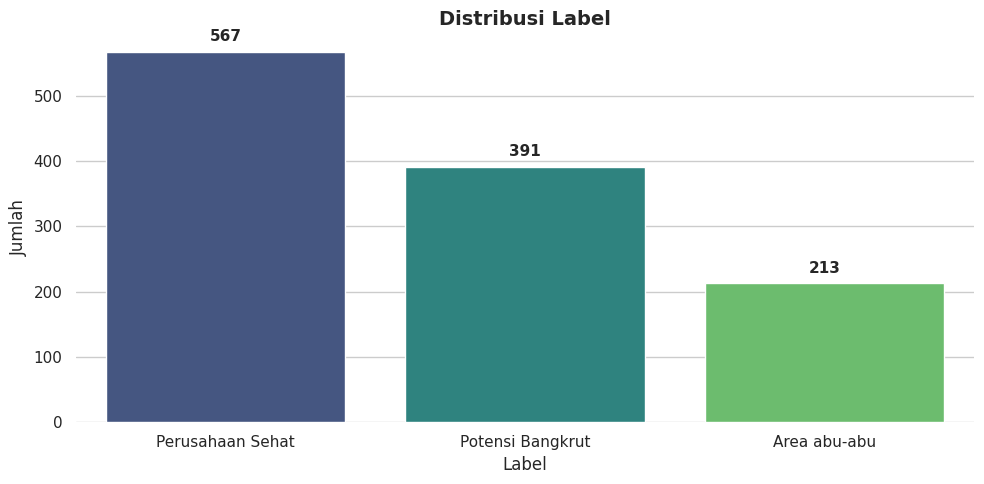

In [14]:
# Set style
sns.set(style="whitegrid", palette="pastel")

# Hitung jumlah masing-masing label
label_counts = data['Label'].value_counts()

# Buat figure dan axes
plt.figure(figsize=(10, 5))
barplot = sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")

# Tambahkan judul dan label sumbu
plt.title("Distribusi Label", fontsize=14, fontweight='bold')
plt.xlabel("Label", fontsize=12)
plt.ylabel("Jumlah", fontsize=12)

# Tambahkan angka di atas tiap bar
for i, value in enumerate(label_counts.values):
    plt.text(i, value + (max(label_counts.values) * 0.02),  # sedikit di atas bar
             str(value),
             ha='center', va='bottom', fontsize=11, fontweight='semibold')

# Tambahkan style tambahan
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


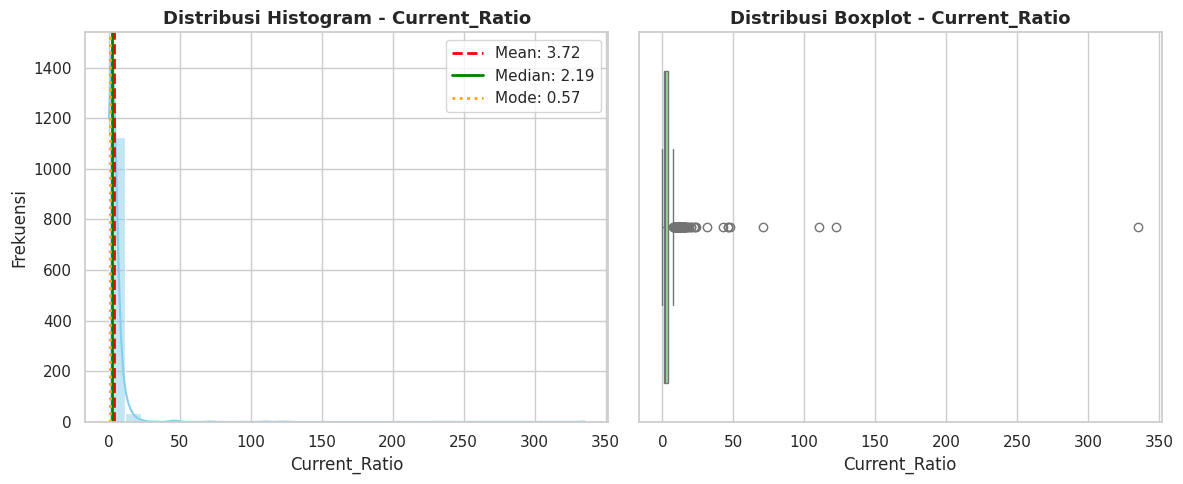

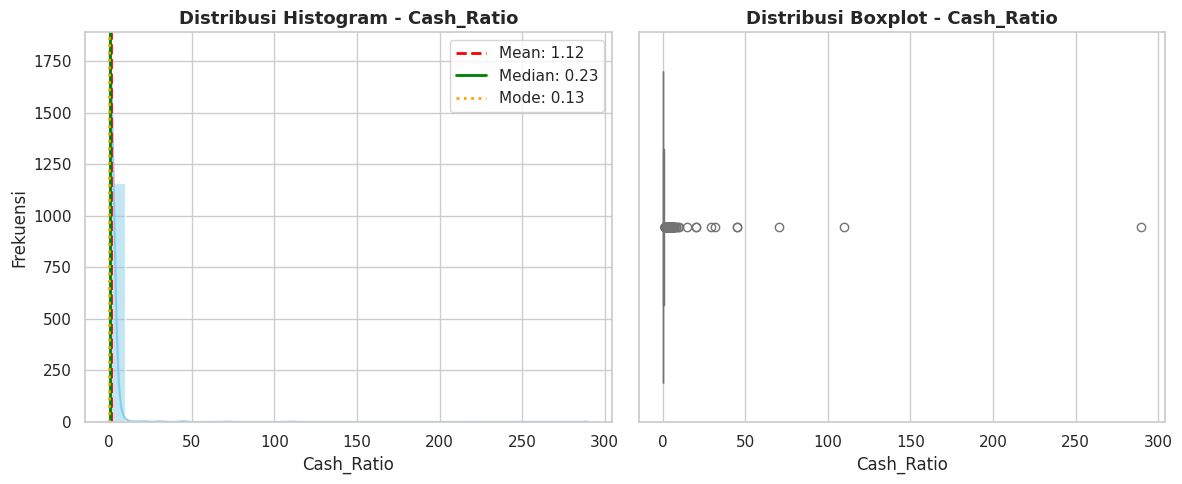

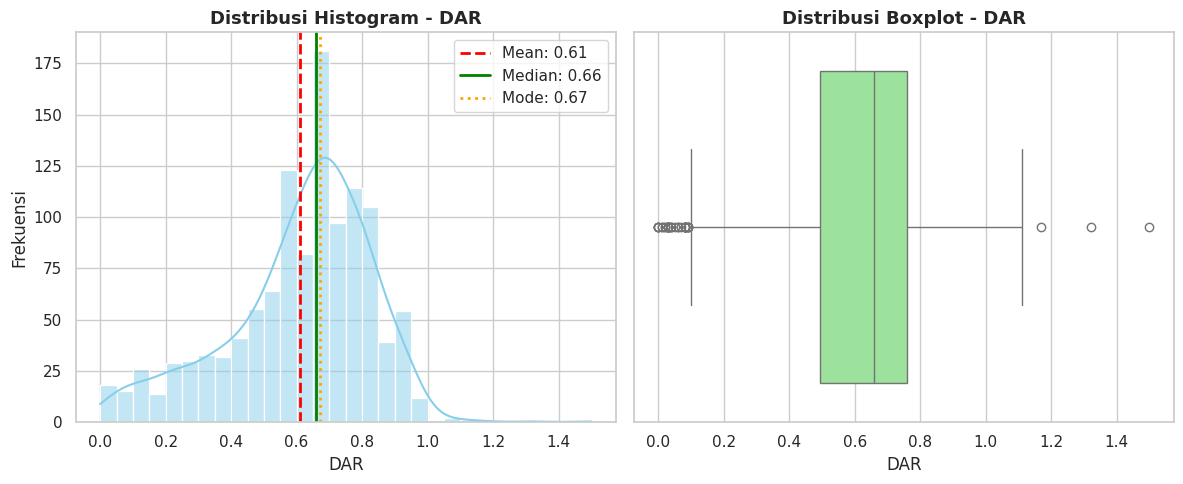

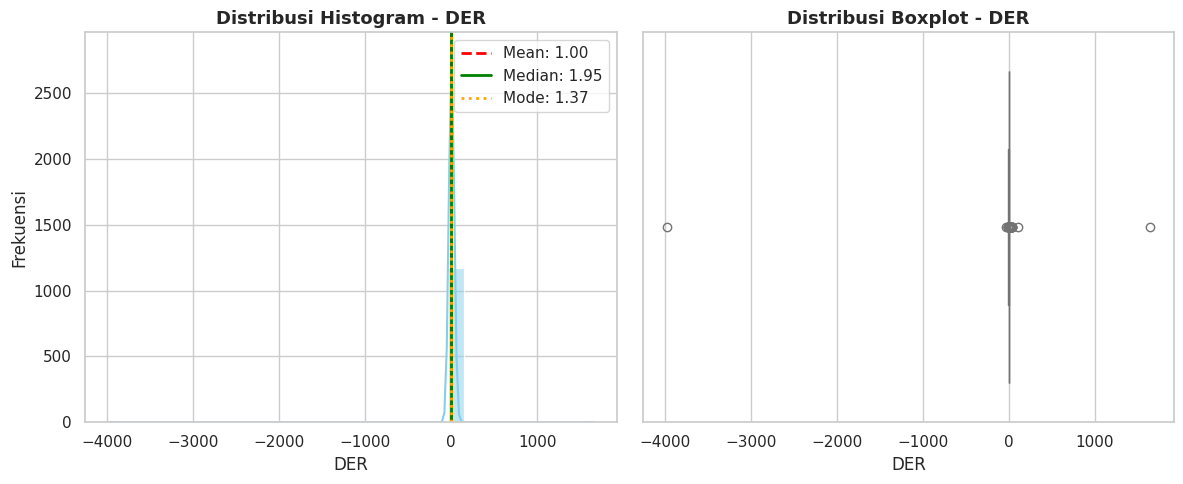

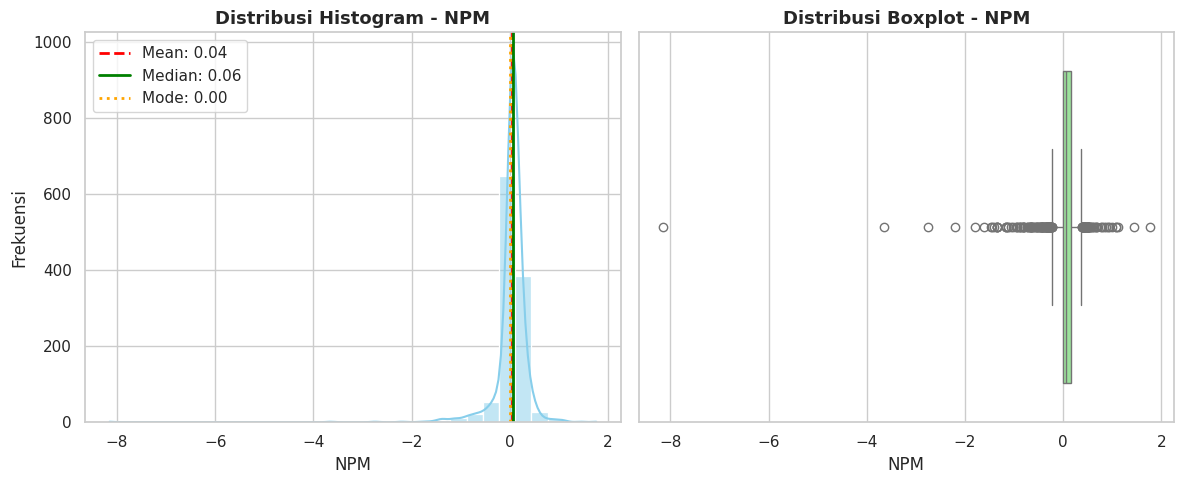

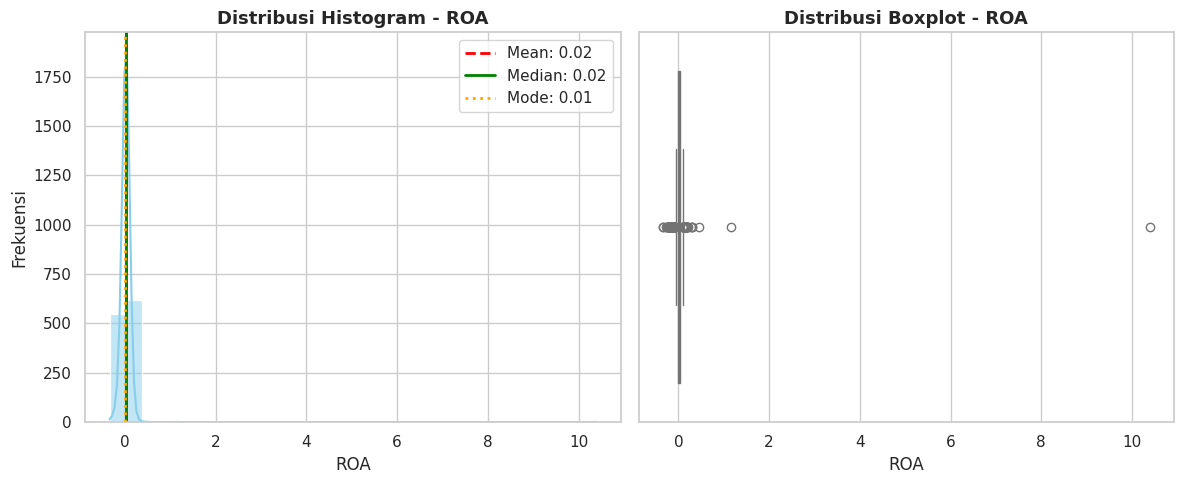

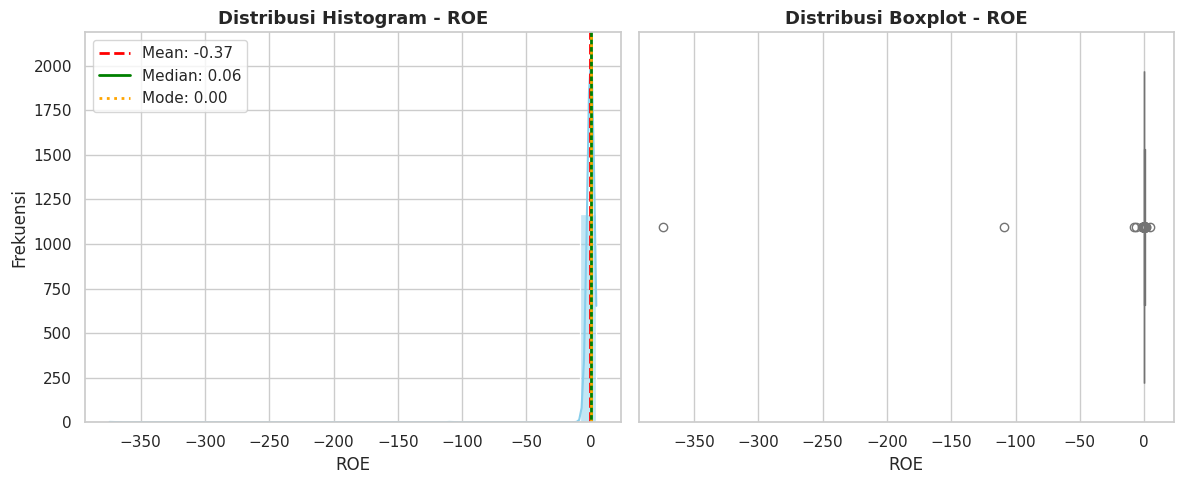

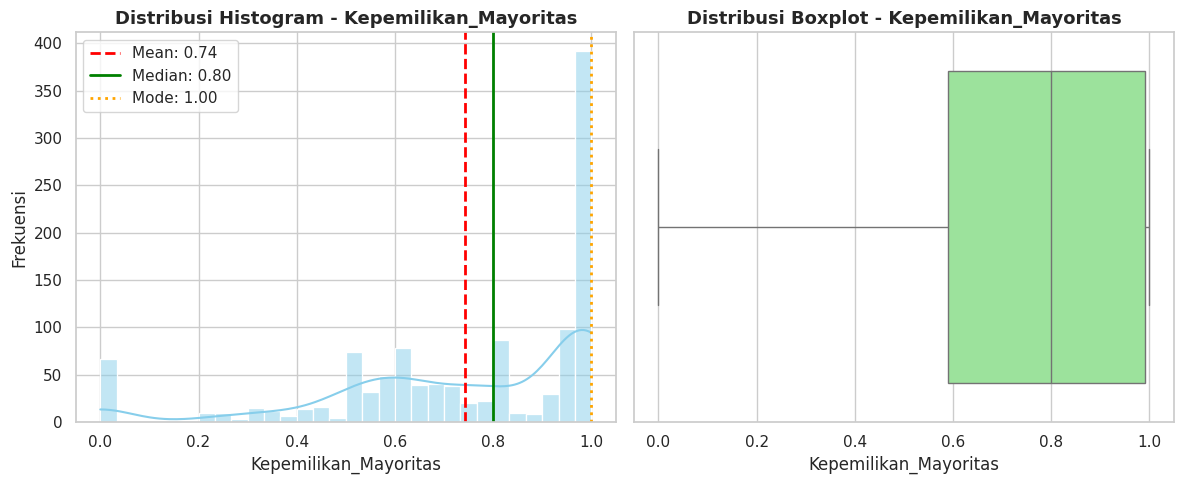

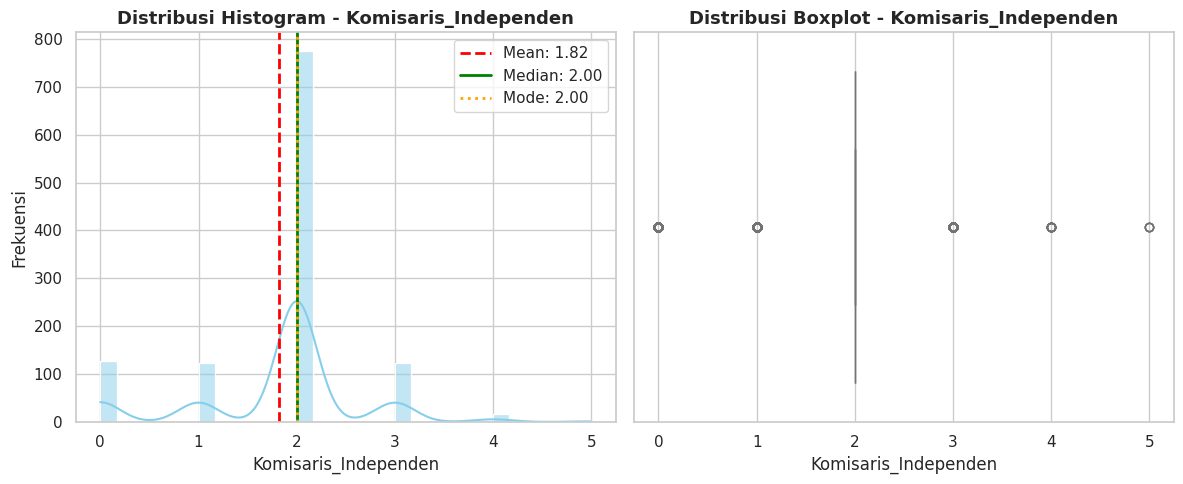

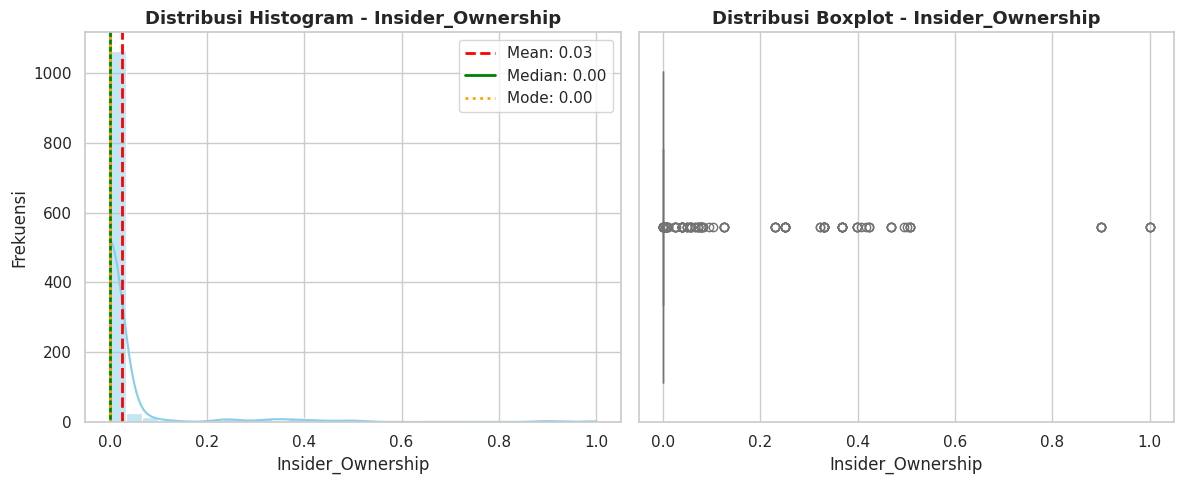

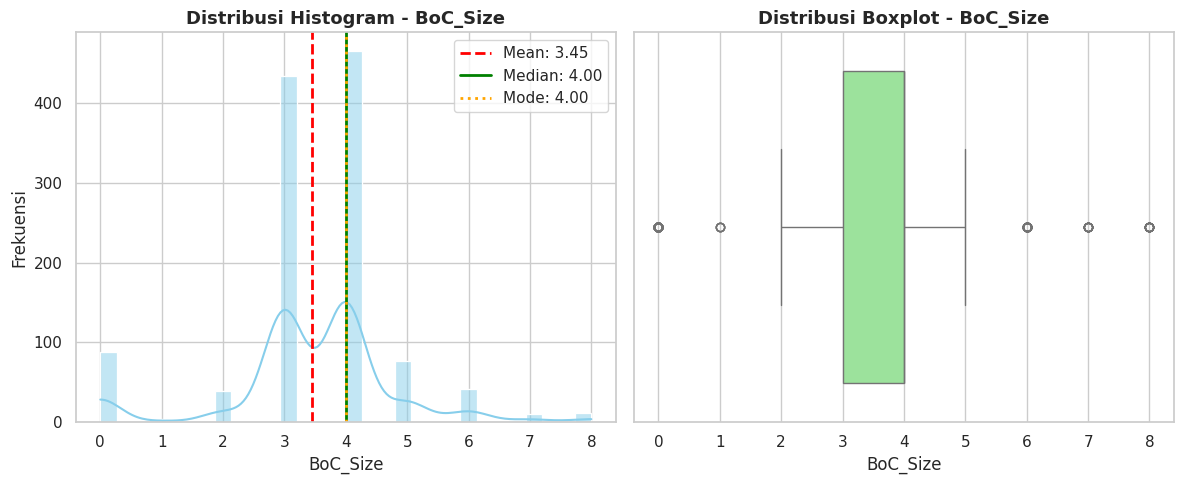

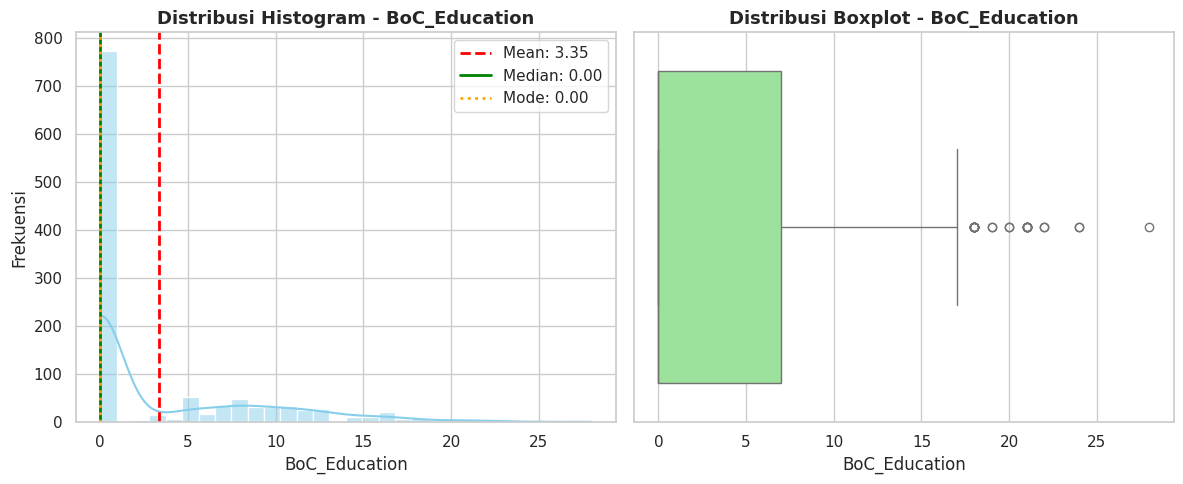

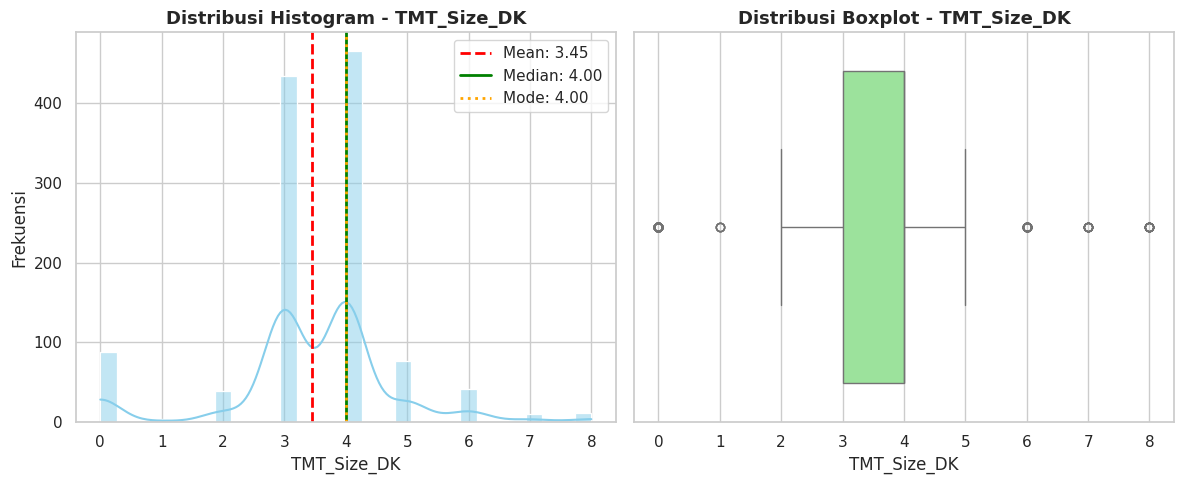

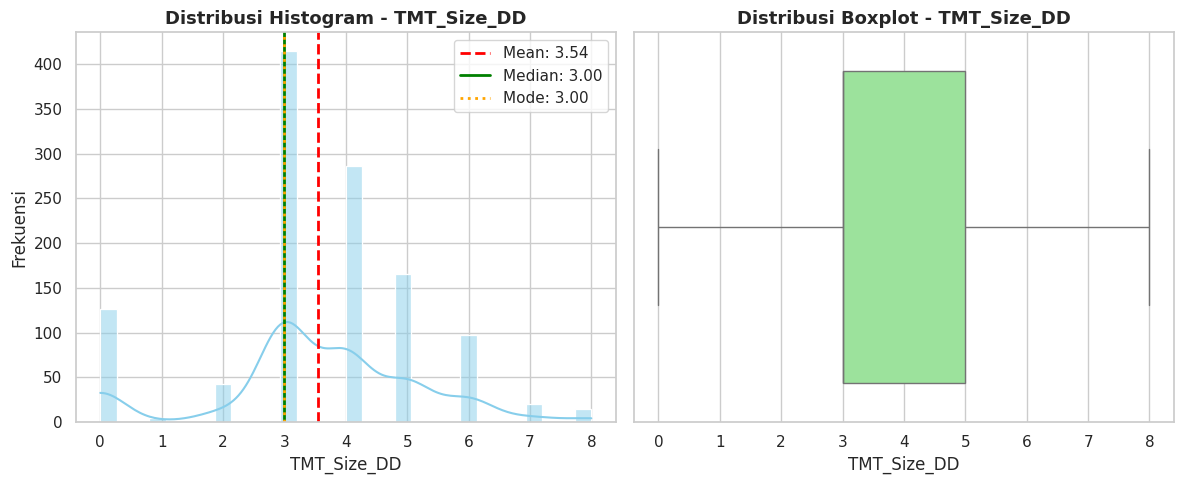

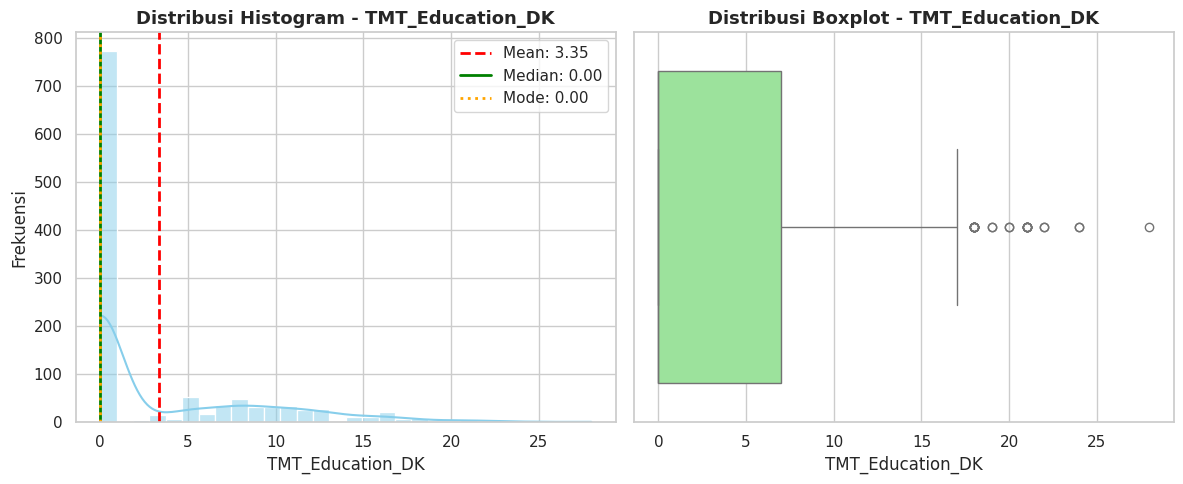

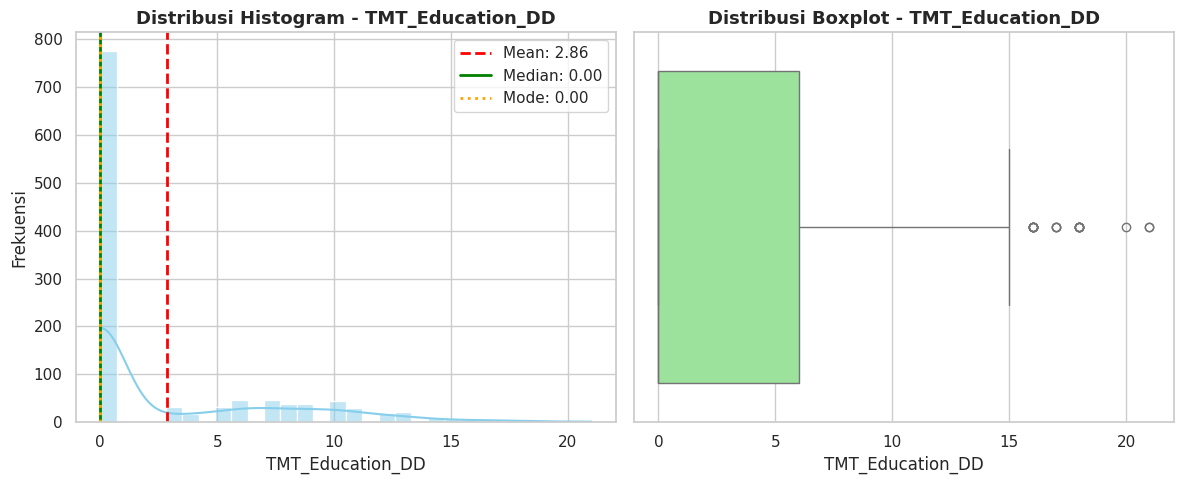

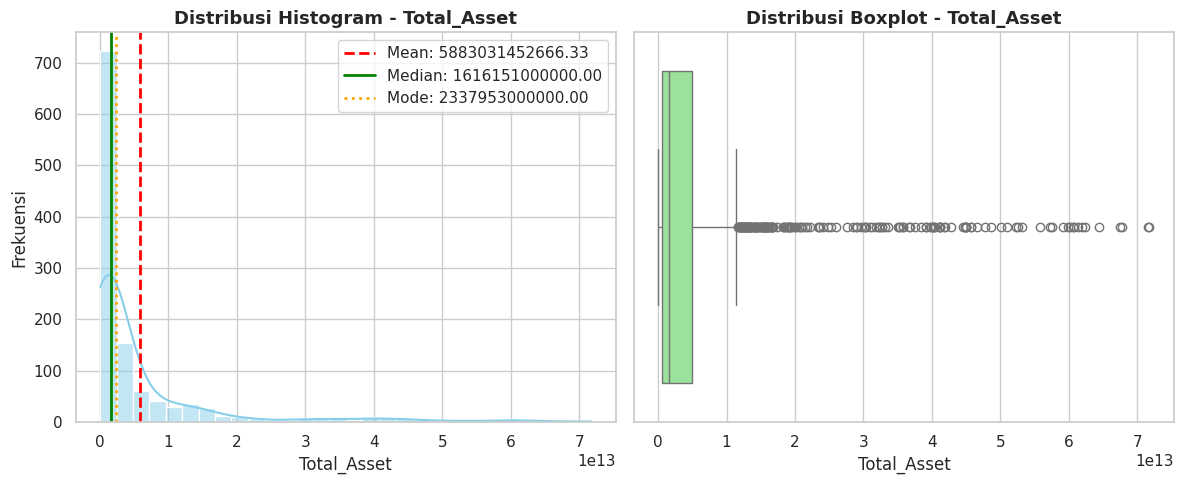

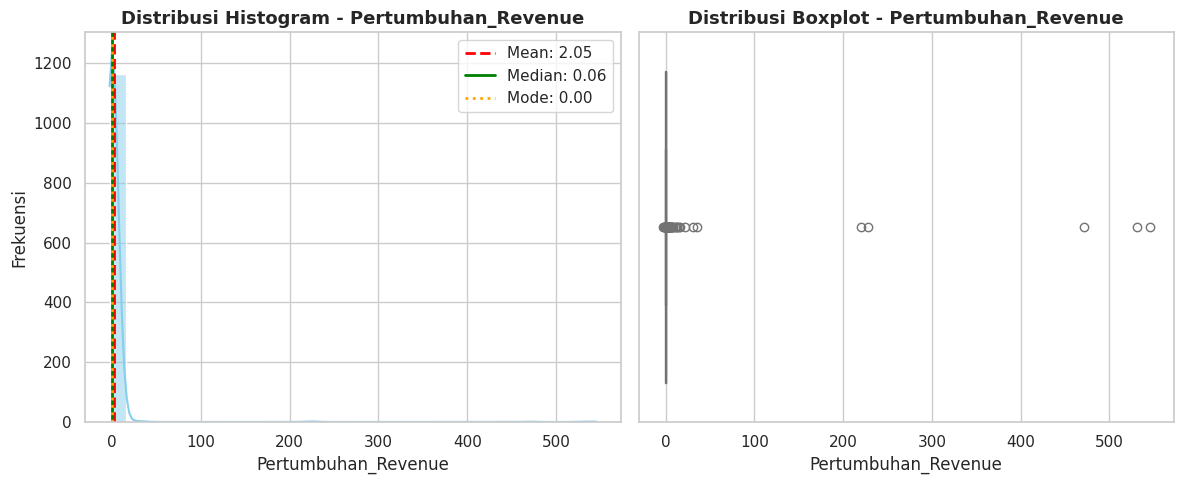

In [15]:
# Set style visual
sns.set(style="whitegrid", palette="muted")

# Pilih semua kolom numerik, kecuali Label
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col != 'Label']

# Loop untuk tiap kolom
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # === Histogram (kiri) ===
    plt.subplot(1, 2, 1)
    sns.histplot(data[col], kde=True, bins=30, color='skyblue', edgecolor='white') # type: ignore

    # Hitung statistik
    mean_val = data[col].mean()
    median_val = data[col].median()
    mode_val = data[col].mode().iloc[0] if not data[col].mode().empty else np.nan

    # Tambahkan garis vertikal
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    plt.axvline(mode_val, color='orange', linestyle=':', linewidth=2, label=f'Mode: {mode_val:.2f}')

    # Tambahkan judul & legend
    plt.title(f'Distribusi Histogram - {col}', fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.legend()

    # === Boxplot (kanan) ===
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col], color='lightgreen')
    plt.title(f'Distribusi Boxplot - {col}', fontsize=13, fontweight='bold')
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


In [16]:
# Menghitung matriks korelasi
corr_matrix = data.corr(numeric_only=True)

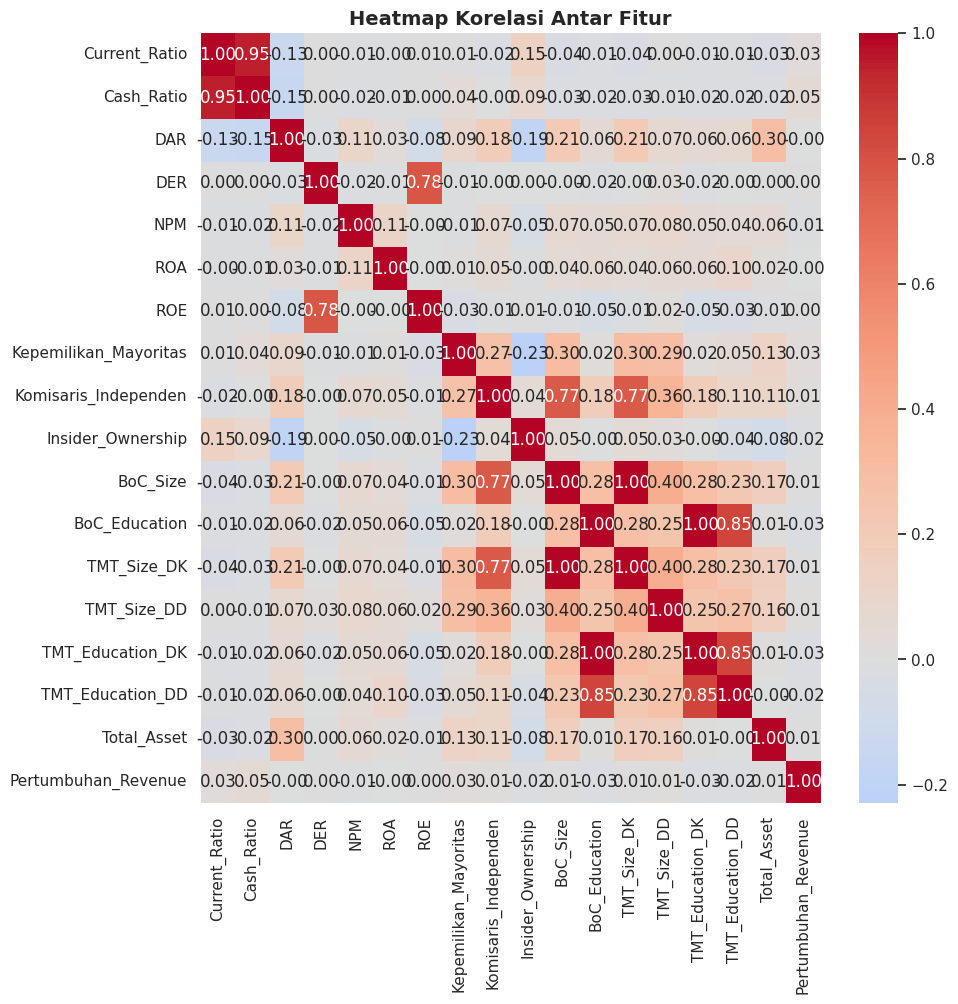

In [17]:
# Visualisasi heatmap korelasi
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Antar Fitur", fontsize=14, fontweight='semibold')
plt.show()

In [18]:
# Matriks korelasi
corr_matrix

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Kepemilikan_Mayoritas,Komisaris_Independen,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size_DK,TMT_Size_DD,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue
Current_Ratio,1.000000,0.948595,-0.131756,0.003322,-0.012706,-0.004877,0.006862,0.008257,-0.024904,0.147402,-0.036114,-0.014320,-0.036114,0.004373,-0.014320,-0.011834,-0.029568,0.031365
Cash_Ratio,0.948595,1.000000,-0.149151,0.001313,-0.020945,-0.007399,0.003635,0.038910,-0.001493,0.086829,-0.027180,-0.021543,-0.027180,-0.011538,-0.021543,-0.020113,-0.015022,0.049858
DAR,-0.131756,-0.149151,1.000000,-0.027726,0.107192,0.033530,-0.084731,0.094612,0.175789,-0.190563,0.210389,0.062069,0.210389,0.071543,0.062069,0.064937,0.295807,-0.003383
DER,0.003322,0.001313,-0.027726,1.000000,-0.019145,-0.011701,0.779846,-0.009409,-0.000474,0.000367,-0.002173,-0.020788,-0.002173,0.027418,-0.020788,-0.000027,0.003983,0.003730
NPM,-0.012706,-0.020945,0.107192,-0.019145,1.000000,0.112120,-0.000904,-0.008819,0.065159,-0.049619,0.071440,0.050853,0.071440,0.080666,0.050853,0.044832,0.059420,-0.011327
ROA,-0.004877,-0.007399,0.033530,-0.011701,0.112120,1.000000,-0.002147,0.010917,0.051979,-0.004531,0.040148,0.060521,0.040148,0.056705,0.060521,0.096999,0.016837,-0.000819
ROE,0.006862,0.003635,-0.084731,0.779846,-0.000904,-0.002147,1.000000,-0.034350,-0.007098,0.008853,-0.014104,-0.051079,-0.014104,0.023658,-0.051079,-0.032034,-0.012299,0.003082
Kepemilikan_Mayoritas,0.008257,0.038910,0.094612,-0.009409,-0.008819,0.010917,-0.034350,1.000000,0.272834,-0.229668,0.301760,0.017518,0.301760,0.290634,0.017518,0.052030,0.134046,0.029151
Komisaris_Independen,-0.024904,-0.001493,0.175789,-0.000474,0.065159,0.051979,-0.007098,0.272834,1.000000,0.040136,0.769512,0.178433,0.769512,0.360538,0.178433,0.107070,0.105306,0.011309
Insider_Ownership,0.147402,0.086829,-0.190563,0.000367,-0.049619,-0.004531,0.008853,-0.229668,0.040136,1.000000,0.045579,-0.002138,0.045579,0.026041,-0.002138,-0.039373,-0.082185,-0.015543


In [19]:
# Cek multikolinearitas berdasarkan korelasi
# Ambil pasangan fitur yang punya korelasi tinggi
threshold = 0.8  # ambang batas korelasi
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold: # type: ignore
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Tampilkan hasilnya
if high_corr:
    print("🔎 Fitur-fitur yang terindikasi multikolinearitas (|r| > 0.8):\n")
    for col1, col2, corr_val in high_corr:
        print(f"{col1:25} ↔ {col2:25} = {corr_val:.2f}")
else:
    print("✅ Tidak ada pasangan fitur dengan korelasi tinggi (|r| > 0.8).")


🔎 Fitur-fitur yang terindikasi multikolinearitas (|r| > 0.8):

Cash_Ratio                ↔ Current_Ratio             = 0.95
TMT_Size_DK               ↔ BoC_Size                  = 1.00
TMT_Education_DK          ↔ BoC_Education             = 1.00
TMT_Education_DD          ↔ BoC_Education             = 0.85
TMT_Education_DD          ↔ TMT_Education_DK          = 0.85


In [20]:
# Menghitung Variance Inflation Factor (VIF)
# Ambil hanya fitur numerik (tanpa Label)
X = data.select_dtypes(include=['int64', 'float64']).drop(columns=['Label'], errors='ignore')

# Hitung VIF untuk setiap fitur
vif_data = pd.DataFrame()
vif_data["Fitur"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Urutkan dari yang tertinggi
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("📊 Nilai VIF tiap fitur:")
print(vif_data)


📊 Nilai VIF tiap fitur:
                    Fitur           VIF
14       TMT_Education_DK  5.522328e+09
10               BoC_Size  4.316817e+09
11          BoC_Education  1.207647e+09
12            TMT_Size_DK  4.481392e+08
1              Cash_Ratio  1.064174e+01
0           Current_Ratio  1.059944e+01
15       TMT_Education_DD  3.792657e+00
6                     ROE  2.584888e+00
8    Komisaris_Independen  2.571661e+00
3                     DER  2.566915e+00
16            Total_Asset  1.419560e+00
13            TMT_Size_DD  1.303122e+00
9       Insider_Ownership  1.140094e+00
4                     NPM  1.033603e+00
5                     ROA  1.026407e+00
7   Kepemilikan_Mayoritas  1.022716e+00
17    Pertumbuhan_Revenue  1.006607e+00
2                     DAR  8.259465e-01


In [21]:
# === Pilih kolom numerik ===
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# === Filter hanya kolom numerik kontinu ===
continuous_cols = data.drop(columns=['Label','Komisaris_Independen','BoC_Size', 'BoC_Education', 'TMT_Size_DK', 'TMT_Size_DD',
       'TMT_Education_DK', 'TMT_Education_DD']).columns

# === Hitung skewness tiap variabel ===
skewness = data[continuous_cols].apply(lambda x: skew(x.dropna()))

# === Hitung Q1, Q3, min, max ===
Q1 = data[continuous_cols].quantile(0.25)
Q3 = data[continuous_cols].quantile(0.75)
min_vals = data[continuous_cols].min()
max_vals = data[continuous_cols].max()
range_vals = max_vals - min_vals

# === Hitung outlier dengan metode IQR ===
IQR = Q3 - Q1
outlier_counts = ((data[continuous_cols] < (Q1 - 1.5 * IQR)) |
                  (data[continuous_cols] > (Q3 + 1.5 * IQR))).sum()
outlier_percent = (outlier_counts / len(data)) * 100

# === Gabungkan hasil ke dalam satu DataFrame ===
summary = pd.DataFrame({
    'Min': min_vals,
    'Q1': Q1,
    'Q3': Q3,
    'Max': max_vals,
    'Range': range_vals,
    'Skewness': skewness,
    'Outlier_Count': outlier_counts,
    'Outlier_Percent': outlier_percent.round(2)
})

# === Interpretasi skewness ===
def interpret_skew(val):
    if -0.5 < val < 0.5:
        return "≈ Normal"
    elif 0.5 <= val < 1:
        return "Moderate Right Skew"
    elif val >= 1:
        return "High Right Skew"
    elif -1 < val <= -0.5:
        return "Moderate Left Skew"
    else:  # val <= -1
        return "High Left Skew"

summary['Skewness_Category'] = summary['Skewness'].apply(interpret_skew)

print("\n=== Ringkasan Distribusi Data (Hanya Kolom Kontinu) ===")
summary



=== Ringkasan Distribusi Data (Hanya Kolom Kontinu) ===


,Min,Q1,Q3,Max,Range,Skewness,Outlier_Count,Outlier_Percent,Skewness_Category
Current_Ratio,4.000000e-02,1.005000e+00,3.700000e+00,3.351900e+02,3.351500e+02,21.464171,97,8.28,High Right Skew
Cash_Ratio,0.000000e+00,9.000000e-02,5.250000e-01,2.897700e+02,2.897700e+02,24.924931,133,11.36,High Right Skew
DAR,0.000000e+00,4.950000e-01,7.600000e-01,1.500000e+00,1.500000e+00,-0.668718,36,3.07,Moderate Left Skew
DER,-3.976610e+03,1.060000e+00,3.210000e+00,1.641970e+03,5.618580e+03,-25.060422,117,9.99,High Left Skew
NPM,-8.150000e+00,0.000000e+00,1.500000e-01,1.760000e+00,9.910000e+00,-9.185810,157,13.41,High Left Skew
ROA,-3.400000e-01,0.000000e+00,4.000000e-02,1.039000e+01,1.073000e+01,31.925306,105,8.97,High Right Skew
ROE,-3.741900e+02,0.000000e+00,1.300000e-01,4.320000e+00,3.785100e+02,-30.931091,118,10.08,High Left Skew
Kepemilikan_Mayoritas,0.000000e+00,5.900000e-01,9.900000e-01,1.000000e+00,1.000000e+00,-1.100414,0,0.00,High Left Skew
Insider_Ownership,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,5.668491,138,11.78,High Right Skew
Total_Asset,5.376020e+10,5.110805e+11,4.940984e+12,7.175770e+13,7.170394e+13,3.205062,170,14.52,High Right Skew


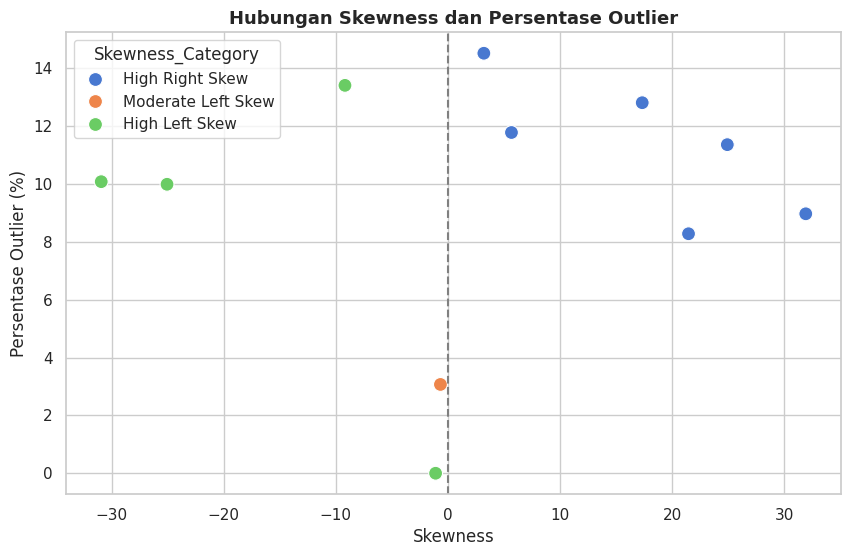

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=summary, x='Skewness', y='Outlier_Percent', hue='Skewness_Category', s=100)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Hubungan Skewness dan Persentase Outlier', fontsize=13, fontweight='bold')
plt.xlabel('Skewness')
plt.ylabel('Persentase Outlier (%)')
plt.show()


Setelah beberapa pertimbangan, kedepannya akan dilakukan preprocessing data berdasarkan beberapa hal berikut ini:
1. Tipe data dari tiap atribut
2. Tingkat Skewness dari atribut tersebut
2. Persentase banyaknya outlier dari tiap atribut

dengan pertimbangan tersebut maka akan dilakukan proses beberapa proses sebagai berikut:
- Tahapan Penyeragaman skala dari data: dikarenakan data-data pada beberapa atribut untuk skala datanya masih tidak seragam dan timpang jauh jika dibandingkan dengan atribut yang lainnya.
ex: atribut Pertumbuhan_Revenue memiliki range dari -2.8691 hingga 545.3648 sedangkan untuk atribut DAR hanya memiliki range antara 0.0 hingga 1.5, hal tersebut jika dilakukan pemodelan dengan menggunakan base model regresi, bila datanya tidak dilakukan penskalaan yang seragam, ada kemungkinan model akan menginisialisikan data yang lebih besar (angka) maka bisa dianggap lebih berpengaruh dibandingkan dengan atribut yang lainnya.
- Tahapan handling outlier: karena jika dilihat dari boxplot yang ada diatas, didapatkan bahwasannya atribut yang bertipe data numerik (kontinu), dari total 16 atribut 11 diantaranya bertipe data kontinu dan didapati beberapa atribut mengandung outlier.
- Tahapan Handling Skewness: jadi berdasarkan dari pencarina skewness data di tiap atributnya. jIka di tiap atribut diperlukan untuk menghandle skewness maka kedepannya akan dilakukan hal tersebut, karena model yang base-nya regresi dia memerlukan skala datanya sama dan datanya berdistribusi normal untuk mempersingkat proses training data

Namun, dengan dilakukannya proses tersebut terdapat sedikit kendala pada penginterpretasian hasil model/rumus yang terbentuk dari hasil training model Multinominal Logistic Regression.

---
Skenario yang akan dilakukan pada proses pemodelan ini ada beberapa, seperti berikut ini:

---
1. Tanpa dilakukan Scaling sama sekali terhadap Pemodelan MNLogit, dicari paramater terbaik
2. Melakukan Pemodelan menggunakan hasil preprocessing tanpa menggunakan Resampling Method
3. Melakukan Pemodelan menggunakan hasil preprocessing dengan menggunakan Resampling Method (Karena jika dilihat, Imbalance Ratio dari kelas terbanyak dan kelas paling sedikit adalah 567/213 = 2.66, karena dibeberapa literatur jika Imbalance Ratio lebih dari 1.5 maka ada kemungkinan Resampling Method bisa dilakukan untuk peningkatan generalisasi Model)

## Tahap Preprocessing Data

## Spliting Dataset

In [23]:

# -------------------------------------------------
# Mapping label ke numerik
# -------------------------------------------------
label_mapping = {
    "Potensi Bangkrut": 0,
    "Area abu-abu": 1,
    "Perusahaan Sehat": 2
}

data['Label'] = data['Label'].replace(label_mapping)
data['Label'].value_counts()
# -------------------------------------------------
# Split data menjadi train, test dan validation
# -------------------------------------------------
X = data.drop(columns=['Label'])
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)


Tanpa Preparation

In [24]:
# inisialisasi ulang data tanpa perubahan
X_train_tanpa = X_train
y_train_tanpa = y_train

X_test_tanpa = X_test
y_test_tanpa = y_test

X_val_tanpa = X_val
y_val_tanpa = y_val

In [25]:
X_train_tanpa.shape, X_test_tanpa.shape, X_val_tanpa.shape, y_train_tanpa.shape, y_test_tanpa.shape, y_val_tanpa.shape

((936, 18), (117, 18), (118, 18), (936,), (117,), (118,))

Dengan Preparation

In [26]:
# inisialisasi ulang data untuk dipreparasi
X_train_prep = X_train
y_train_prep = y_train

X_test_prep = X_test
y_test_prep = y_test

X_val_prep = X_val
y_val_prep = y_val

## Preprocessing Data

Menggunakan data yang sudah disiapkan untuk dilakukan preparation sebagai berikut:

## Menggunakan Standart Scaler

In [27]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Misal data train, test, val
# X_train_prep, X_test_prep, X_val_prep

# Inisialisasi scaler
scaler = StandardScaler()

# Fit scaler hanya pada data TRAIN
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_prep),
                              columns=X_train_prep.columns,
                              index=X_train_prep.index)

# Transform data TEST dan VALIDASI menggunakan scaler dari TRAIN
X_test_scaled = pd.DataFrame(scaler.transform(X_test_prep),
                             columns=X_test_prep.columns,
                             index=X_test_prep.index)

X_val_scaled = pd.DataFrame(scaler.transform(X_val_prep),
                            columns=X_val_prep.columns,
                            index=X_val_prep.index)

print("✅ Semua kolom berhasil di-scale dengan StandardScaler")


✅ Semua kolom berhasil di-scale dengan StandardScaler


Karena dilihat ada beberapa variabel yang rangenya terlalu besar dan skala datanya jika dibandingkan dengan data lainnya skalanya sangat jauh, maka diperlukan untuk scaling data, akan discaling untuk beberapa variabel seperti;
1. Pertumbuhan Revenue
2. Total_Asset
3. Debt Equity Ratio (DER)

untuk metode scaling yang digunakan disini digunakan beberapa metode seperti:
1. metode klasik seperti penggunakan nilai log, ln, exp dsb dari data pada kolom tersebut lalu dicari nilai skewness yang paling terendah dari tiap percobaan tersebut.
2. Menggunakan Robust Scaler: karena setelah dilakukan EDA tadi didapatkan pada atribut tersebut tidak berdistribusi normal dan terdapat oulier yang mengganggu distribusi datanya, robust scaler dikenal bisa mengatasi itu.
3. Menggunakan MinMax Scaler: hal ini dimaksudkan untuk mengubah skala data dari tiap atributnya agar nilai terendahnya menjadi 0 dan nilai tertingginya menjadi 1
4. Standart Scaler:
5. Power'Yeo-Jeonson'

## Scaling menggunakan metode klasik

In [28]:
data[['Pertumbuhan_Revenue','Total_Asset','DER']].describe()

,Pertumbuhan_Revenue,Total_Asset,DER
count,1171.000000,1.171000e+03,1171.000000
mean,2.054406,5.883031e+12,0.995115
std,27.765929,1.125741e+13,125.916301
min,-2.869100,5.376020e+10,-3976.610000
25%,-0.024450,5.110805e+11,1.060000
50%,0.057000,1.616151e+12,1.950000
75%,0.232400,4.940984e+12,3.210000
max,545.364800,7.175770e+13,1641.970000


In [29]:
import numpy as np
import pandas as pd

def transform_skew(df, right_skew_cols, left_skew_cols):
    df_trans = df.copy()
    transformed_cols = []  # simpan nama kolom baru

    # === Right skew ===
    for col in right_skew_cols:
        if (df_trans[col] >= 0).all():
            df_trans[col+'_log'] = np.log1p(df_trans[col])
            transformed_cols.append(col+'_log')
            df_trans[col+'_sqrt'] = np.sqrt(df_trans[col])
            transformed_cols.append(col+'_sqrt')
        df_trans[col+'_cbrt'] = np.cbrt(df_trans[col])
        transformed_cols.append(col+'_cbrt')

    # === Left skew ===
    for col in left_skew_cols:
        max_val = df_trans[col].max()
        reflected = max_val + 1 - df_trans[col]
        reflected[reflected < 0] = 0
        df_trans[col+'_ref_log'] = np.log1p(reflected)
        transformed_cols.append(col+'_ref_log')
        df_trans[col+'_ref_sqrt'] = np.sqrt(reflected)
        transformed_cols.append(col+'_ref_sqrt')
        df_trans[col+'_ref_cbrt'] = np.cbrt(reflected)
        transformed_cols.append(col+'_ref_cbrt')

    return df_trans, transformed_cols

# Daftar kolom skew
right_skew_cols = ['Current_Ratio', 'Cash_Ratio', 'ROA', 'Pertumbuhan_Revenue', 'Total_Asset']
left_skew_cols = ['DAR', 'DER', 'NPM', 'ROE', 'Kepemilikan_Mayoritas']

# Transformasi
X_train_trans, new_cols = transform_skew(X_train_prep, right_skew_cols, left_skew_cols)
X_test_trans, _ = transform_skew(X_test_prep, right_skew_cols, left_skew_cols)
X_val_trans, _ = transform_skew(X_val_prep, right_skew_cols, left_skew_cols)

# Hitung skew untuk kolom hasil transformasi
skew_values_trans = X_train_trans[new_cols].skew()
print("📊 Skewness after transformation:")
skew_values_trans.sort_values(ascending=False)

📊 Skewness after transformation:


,0
ROE_ref_sqrt,24.262096
ROE_ref_cbrt,22.648155
ROE_ref_log,19.075606
Cash_Ratio_sqrt,9.900955
Current_Ratio_sqrt,6.120604
Cash_Ratio_cbrt,4.697402
Cash_Ratio_log,4.277375
Pertumbuhan_Revenue_cbrt,3.407346
Current_Ratio_cbrt,2.999573
Total_Asset_sqrt,1.815493


In [30]:
X_train_trans = X_train_trans[['DER_ref_sqrt','ROE_ref_log','Cash_Ratio_log','DAR_ref_cbrt',
       'Kepemilikan_Mayoritas_ref_cbrt','NPM_ref_log','Pertumbuhan_Revenue_cbrt',
       'ROA_cbrt','Total_Asset_cbrt','Current_Ratio_log']]
X_test_trans = X_test_trans[['DER_ref_sqrt','ROE_ref_log','Cash_Ratio_log','DAR_ref_cbrt',
       'Kepemilikan_Mayoritas_ref_cbrt','NPM_ref_log','Pertumbuhan_Revenue_cbrt',
       'ROA_cbrt','Total_Asset_cbrt','Current_Ratio_log']]
X_val_trans = X_val_trans[['DER_ref_sqrt','ROE_ref_log','Cash_Ratio_log','DAR_ref_cbrt',
       'Kepemilikan_Mayoritas_ref_cbrt','NPM_ref_log','Pertumbuhan_Revenue_cbrt',
       'ROA_cbrt','Total_Asset_cbrt','Current_Ratio_log']]

## Scaling menggunakan Robust dan Min Max Scaler

In [31]:
from sklearn.preprocessing import RobustScaler

# === 1. Tentukan kolom yang ingin di-scale ===
robust_cols = [
    'Current_Ratio', 'Cash_Ratio', 'ROA', 'Pertumbuhan_Revenue',
    'Total_Asset', 'DAR', 'DER', 'NPM', 'ROE', 'Kepemilikan_Mayoritas'
]

# === 2. Inisialisasi scaler ===
robust_scaler = RobustScaler()

# === 3. Fit dan transform pada data TRAIN ===
X_train_scaled_robust = robust_scaler.fit_transform(X_train_prep[robust_cols])

# === 4. Transform data TEST dan VALIDASI dengan scaler dari TRAIN ===
X_test_scaled_robust = robust_scaler.transform(X_test_prep[robust_cols])
X_val_scaled_robust = robust_scaler.transform(X_val_prep[robust_cols])

# === 5. Ubah hasil kembali menjadi DataFrame dengan kolom yang sama ===
import pandas as pd

X_train_scaled_robust = pd.DataFrame(X_train_scaled_robust, columns=robust_cols, index=X_train_prep.index)
X_test_scaled_robust = pd.DataFrame(X_test_scaled_robust, columns=robust_cols, index=X_test_prep.index)
X_val_scaled_robust = pd.DataFrame(X_val_scaled_robust, columns=robust_cols, index=X_val_prep.index)

# === 6. Info hasil ===
print("✅ Scaling RobustScaler selesai!")
print(f"- {len(robust_cols)} kolom di-scale")
print(f"- X_train_scaled_robust shape: {X_train_scaled_robust.shape}")

✅ Scaling RobustScaler selesai!
- 10 kolom di-scale
- X_train_scaled_robust shape: (936, 10)


Menggunakan Min-Max Scaler

In [32]:
from sklearn.preprocessing import MinMaxScaler

# === 1. Tentukan kolom yang ingin di-scale ===
minmax_cols = [
    'Current_Ratio', 'Cash_Ratio', 'ROA', 'Pertumbuhan_Revenue',
    'Total_Asset', 'DAR', 'DER', 'NPM', 'ROE', 'Kepemilikan_Mayoritas'
]

# === 2. Inisialisasi scaler ===
minmax = MinMaxScaler()

# === 3. Fit dan transform pada data TRAIN ===
X_train_scaled_minmax = minmax.fit_transform(X_train_prep[minmax_cols])

# === 4. Transform data TEST dan VALIDASI dengan scaler dari TRAIN ===
X_test_scaled_minmax = minmax.transform(X_test_prep[minmax_cols])
X_val_scaled_minmax = minmax.transform(X_val_prep[minmax_cols])

# === 5. Ubah hasil kembali menjadi DataFrame dengan kolom yang sama ===
import pandas as pd

X_train_scaled_minmax = pd.DataFrame(X_train_scaled_minmax, columns=minmax_cols, index=X_train_prep.index)
X_test_scaled_minmax = pd.DataFrame(X_test_scaled_minmax, columns=minmax_cols, index=X_test_prep.index)
X_val_scaled_minmax = pd.DataFrame(X_val_scaled_minmax, columns=minmax_cols, index=X_val_prep.index)

# === 6. Info hasil ===
print("✅ Scaling MinMax selesai!")
print(f"- {len(minmax_cols)} kolom di-scale")
print(f"- X_train_scaled_minmax shape: {X_train_scaled_minmax.shape}")

✅ Scaling MinMax selesai!
- 10 kolom di-scale
- X_train_scaled_minmax shape: (936, 10)


Menggunakan PowerTransformer dengam metode yeo-jhonson

In [33]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# === 1. Tentukan kolom yang ingin di-transform ===
yeo_cols = [
    'Current_Ratio', 'Cash_Ratio', 'ROA', 'Pertumbuhan_Revenue',
    'Total_Asset', 'DAR', 'DER', 'NPM', 'ROE', 'Kepemilikan_Mayoritas'
]

# === 2. Inisialisasi transformer (gunakan Yeo-Johnson) ===
yeo_transformer = PowerTransformer(method='yeo-johnson', standardize=True)

# === 3. Fit dan transform pada data TRAIN ===
X_train_scaled_yeo = yeo_transformer.fit_transform(X_train_prep[yeo_cols])

# === 4. Transform data TEST dan VALIDASI menggunakan parameter dari TRAIN ===
X_test_scaled_yeo = yeo_transformer.transform(X_test_prep[yeo_cols])
X_val_scaled_yeo = yeo_transformer.transform(X_val_prep[yeo_cols])

# === 5. Ubah hasil menjadi DataFrame kembali ===
X_train_scaled_yeo = pd.DataFrame(X_train_scaled_yeo, columns=yeo_cols, index=X_train_prep.index)
X_test_scaled_yeo = pd.DataFrame(X_test_scaled_yeo, columns=yeo_cols, index=X_test_prep.index)
X_val_scaled_yeo = pd.DataFrame(X_val_scaled_yeo, columns=yeo_cols, index=X_val_prep.index)

# === 6. Info hasil ===
print("✅ Transformasi Yeo-Johnson selesai!")
print(f"- {len(yeo_cols)} kolom di-transform")
print(f"- X_train_scaled_yeo shape: {X_train_scaled_yeo.shape}")

✅ Transformasi Yeo-Johnson selesai!
- 10 kolom di-transform
- X_train_scaled_yeo shape: (936, 10)


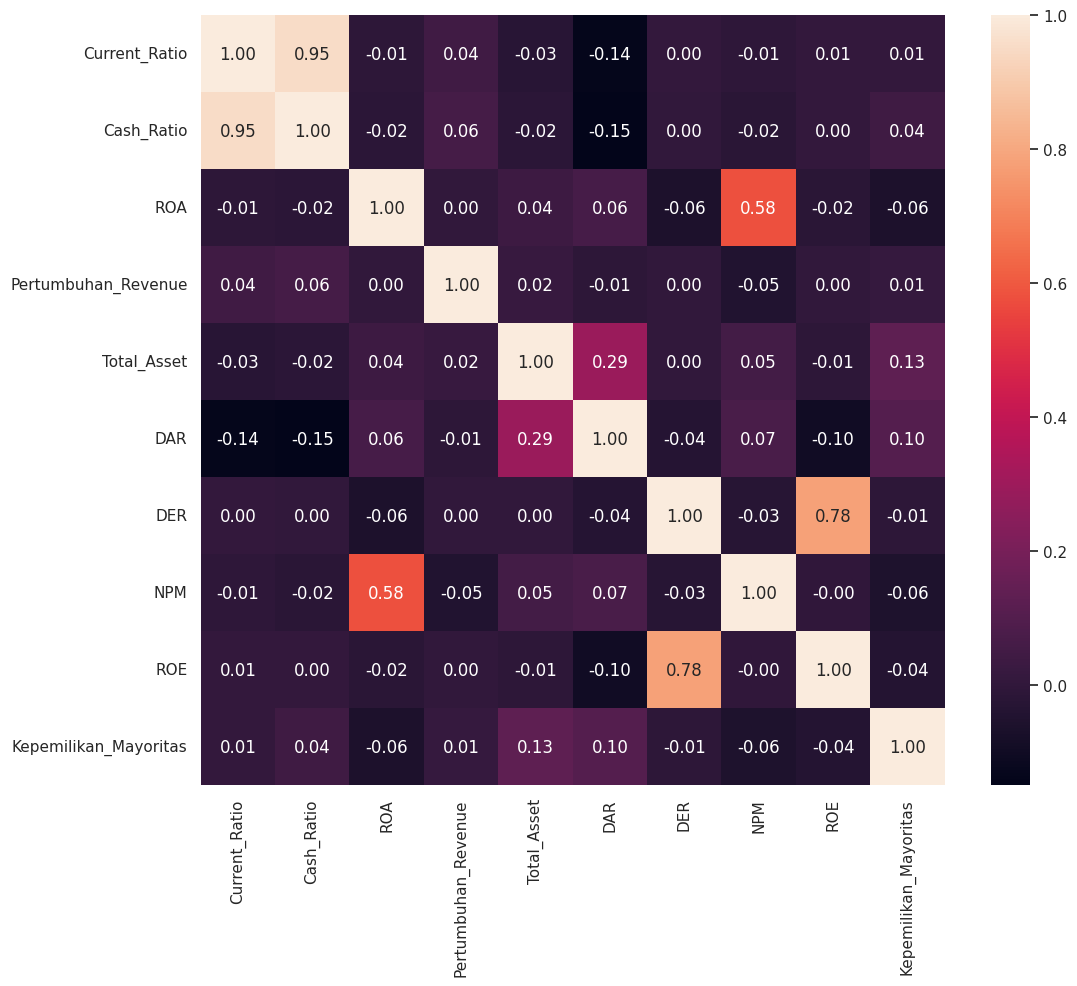

In [34]:
corr = X_train_scaled_robust.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()


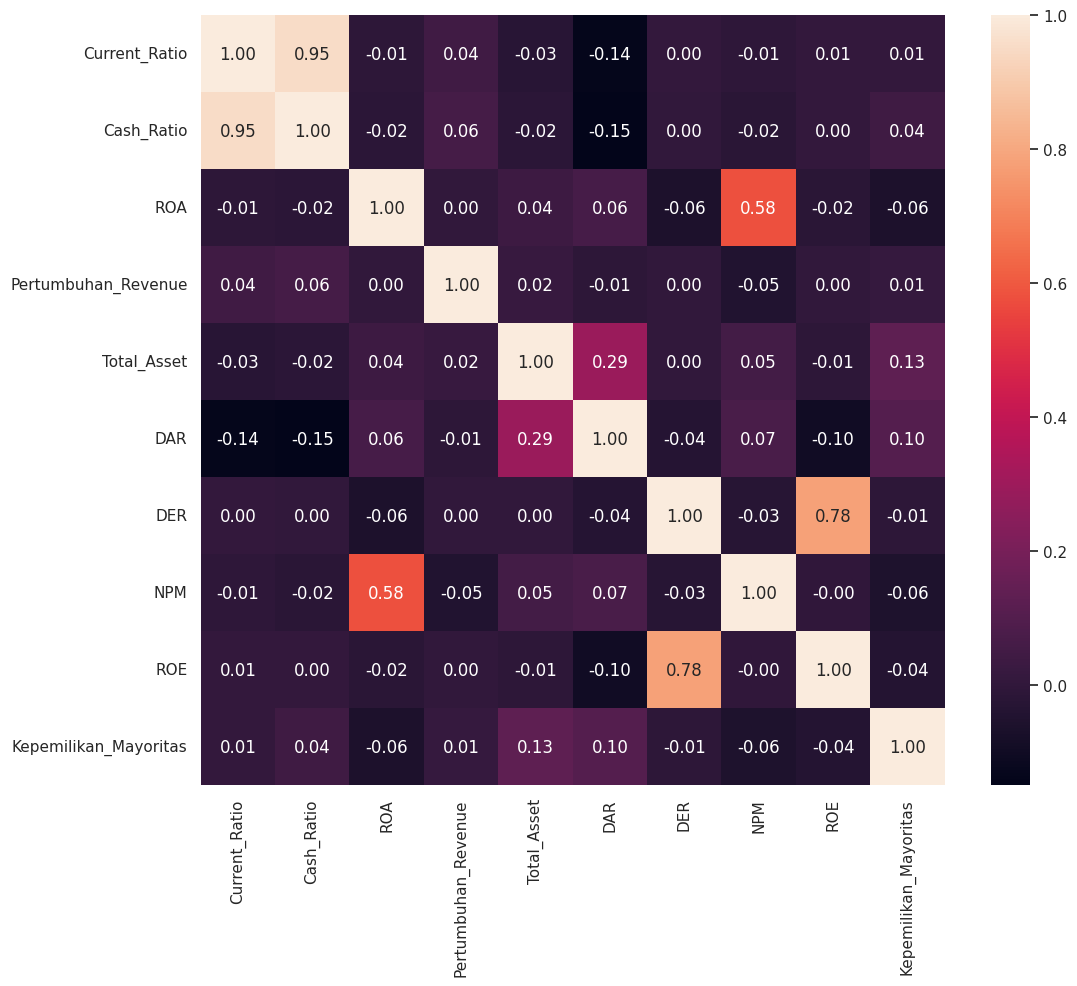

In [35]:
corr = X_train_scaled_minmax.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

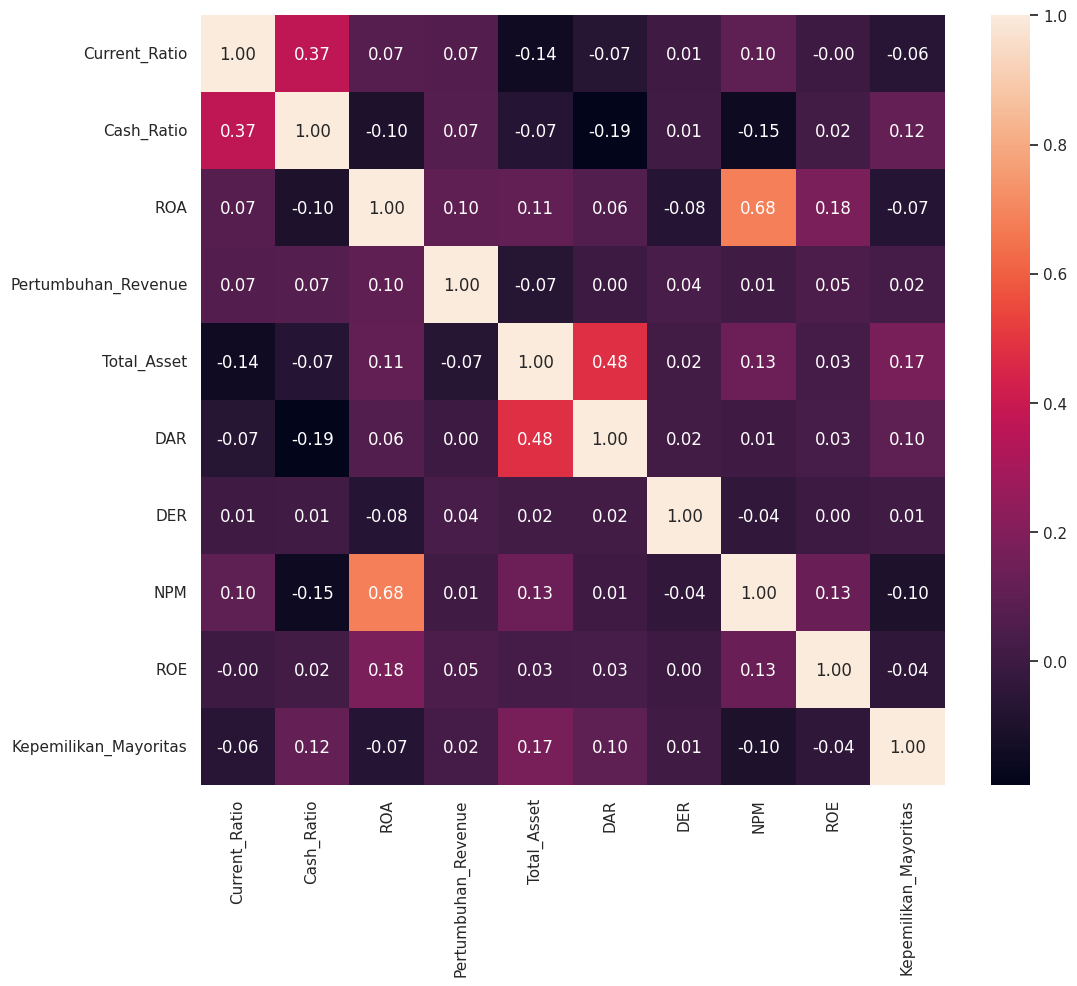

In [36]:
corr = X_train_scaled_yeo.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

## **CATATAN UNTUK PREPRPOCESSING**

<table>
<tr>
<th>No</th>
<th>Tanggal</th>
<th>Catatan Kejadian</th>
<th>Solusi Yang Diusulkan</th>

</tr>
<tr>

<td>1.</td>
<td>29/10/2025</td>
<td>Berdasarkan hasil evaluasi model MNLogit data yang sudah dilakukan perprocessing menggunakan min-max scaling dan robust scaler ternyata masih belum bisa dievaluasi ataupun diproses dengan baik sehingga bisa menunculkan hasil evaluasi model ataupaun hasil klasifikasi dengan sebagaimana mestinya.</td>
<td>Solusi yang bisa diusulkan adalah kembali ke metode tansformasi klasik menggunakan log, ln dsb untuk mengubah range dari data yang rangenya terlalu lebar. Lalu nanti bisa diujikan terlebih dahulu apakah dengan menggunakan metode tersebut apakah bisa mengubah range dan bisa memunculkan hasil dari model tersebut</td>



</tr>
</table>

# Tahapan Pemodelan

Untuk Pencarian Model Terbaiknya, untuk modelnya dibuatkan sebuah fungsi agar mudah jika ingin digunakan kembali

In [37]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_mnlogit(
    X_train, y_train,
    X_test, y_test,
    X_val=None, y_val=None,
    label_names=None,
    methods=None
):
    """
    Melatih dan mengevaluasi model Multinomial Logit (MNLogit)
    dengan berbagai metode optimisasi, lalu menampilkan summary tabel
    berisi metrik-metrik penting dari tiap metode.
    """

    # === Default label names ===
    if label_names is None:
        label_names = ['Potensi Bangkrut', 'Area Abu-Abu', 'Perusahaan Sehat']

    # === Default methods ===
    if methods is None:
        methods = ['newton', 'nm', 'bfgs', 'lbfgs', 'powell', 'cg', 'ncg', 'minimize']

    # === Tambahkan konstanta untuk model ===
    X_train_const = sm.add_constant(X_train, has_constant='add')
    X_test_const  = sm.add_constant(X_test, has_constant='add')
    if X_val is not None:
        X_val_const = sm.add_constant(X_val, has_constant='add')

    results = {}
    summary_rows = []  # 🔥 menampung semua hasil per metode

    # === Loop untuk semua metode ===
    for m in methods:
        print("=" * 100)
        print(f"🚀 Melatih model MNLogit dengan metode: {m}")
        print("=" * 100)
        try:
            model = sm.MNLogit(y_train, X_train_const)
            result = model.fit(method=m, maxiter=100000, disp=False)

            iterasi = result.mle_retvals.get('iterations', 'N/A')
            converged = result.mle_retvals.get('converged', False)

            # --- Evaluasi Test ---
            y_pred_test = result.predict(X_test_const).idxmax(axis=1)
            acc_test = accuracy_score(y_test, y_pred_test)
            prec_test = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
            rec_test = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
            f1_test = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

            # --- Evaluasi Validasi (jika ada) ---
            if X_val is not None and y_val is not None:
                y_pred_val = result.predict(X_val_const).idxmax(axis=1)
                acc_val = accuracy_score(y_val, y_pred_val)
                prec_val = precision_score(y_val, y_pred_val, average='macro', zero_division=0)
                rec_val = recall_score(y_val, y_pred_val, average='macro', zero_division=0)
                f1_val = f1_score(y_val, y_pred_val, average='macro', zero_division=0)
            else:
                acc_val = prec_val = rec_val = f1_val = np.nan

            # --- Simpan ke summary ---
            summary_rows.append({
                'Method': m,
                'Converged': converged,
                'Iterations': iterasi,
                'Pseudo_R2': result.prsquared,
                'AIC': result.aic,
                'BIC': result.bic,
                'LogLik': result.llf,
                'Acc_Test': acc_test,
                'Prec_Test': prec_test,
                'Recall_Test': rec_test,
                'F1_Test': f1_test,
                'Acc_Val': acc_val,
                'Prec_Val': prec_val,
                'Recall_Val': rec_val,
                'F1_Val': f1_val
            })

            # --- Tampilkan Confusion Matrix Test ---
            cm_test = confusion_matrix(y_test, y_pred_test)
            df_cm_test = pd.DataFrame(
                cm_test,
                columns=[f'Pred_{lbl}' for lbl in label_names],
                index=[f'Actual_{lbl}' for lbl in label_names]
            )
            plt.figure(figsize=(6, 5))
            sns.heatmap(df_cm_test, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Confusion Matrix (Test) - {m}')
            plt.show()

            # --- Confusion Matrix Val (jika ada) ---
            if X_val is not None and y_val is not None:
                cm_val = confusion_matrix(y_val, y_pred_val)
                df_cm_val = pd.DataFrame(
                    cm_val,
                    columns=[f'Pred_{lbl}' for lbl in label_names],
                    index=[f'Actual_{lbl}' for lbl in label_names]
                )
                plt.figure(figsize=(6, 5))
                sns.heatmap(df_cm_val, annot=True, fmt='d', cmap='Greens')
                plt.title(f'Confusion Matrix (Val) - {m}')
                plt.show()

            results[m] = result

        except Exception as e:
            print(f"❌ Gagal dengan metode: {m}")
            print(f"Error: {e}")

            # tetap catat error-nya supaya kelihatan di summary
            summary_rows.append({
                'Method': m,
                'Converged': False,
                'Iterations': np.nan,
                'Pseudo_R2': np.nan,
                'AIC': np.nan,
                'BIC': np.nan,
                'LogLik': np.nan,
                'Acc_Test': np.nan,
                'Prec_Test': np.nan,
                'Recall_Test': np.nan,
                'F1_Test': np.nan,
                'Acc_Val': np.nan,
                'Prec_Val': np.nan,
                'Recall_Val': np.nan,
                'F1_Val': np.nan
            })

        print("=" * 100 + "\n")

    # === 🔥 Buat Summary Table ===
    summary_df = pd.DataFrame(summary_rows)
    print("\n📋 Ringkasan Hasil Evaluasi Semua Metode:")
    display(summary_df)

    return None

## Pemodelan tanpa prep

🚀 Melatih model MNLogit dengan metode: newton
❌ Gagal dengan metode: newton
Error: Input y_pred contains NaN.

🚀 Melatih model MNLogit dengan metode: nm


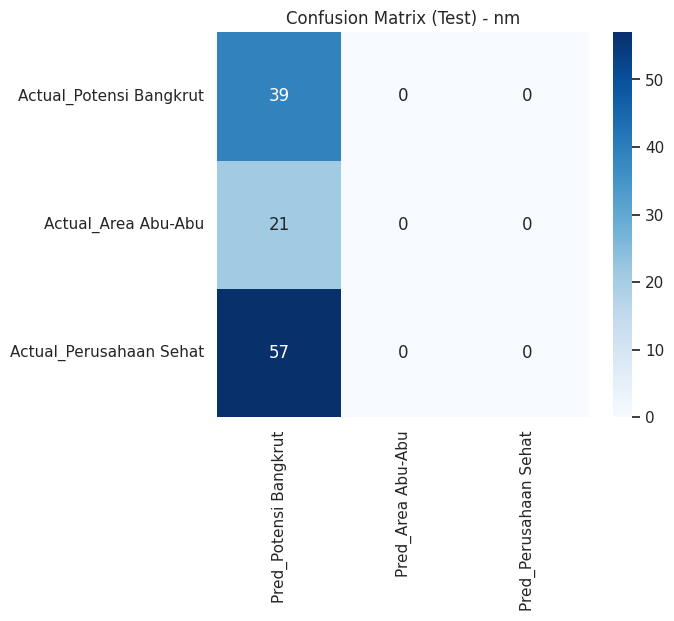

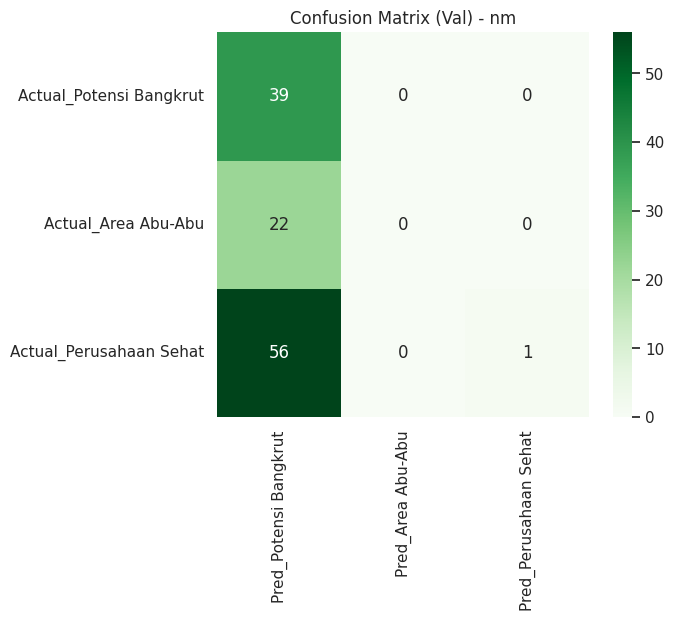


🚀 Melatih model MNLogit dengan metode: bfgs


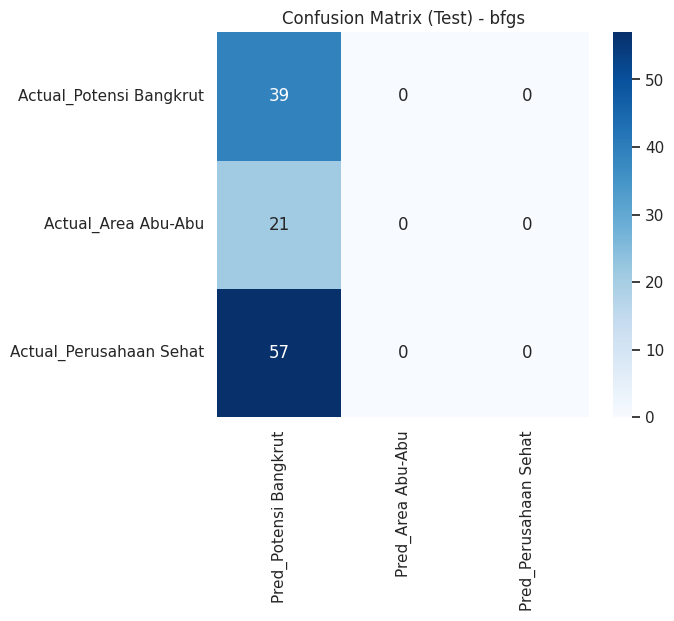

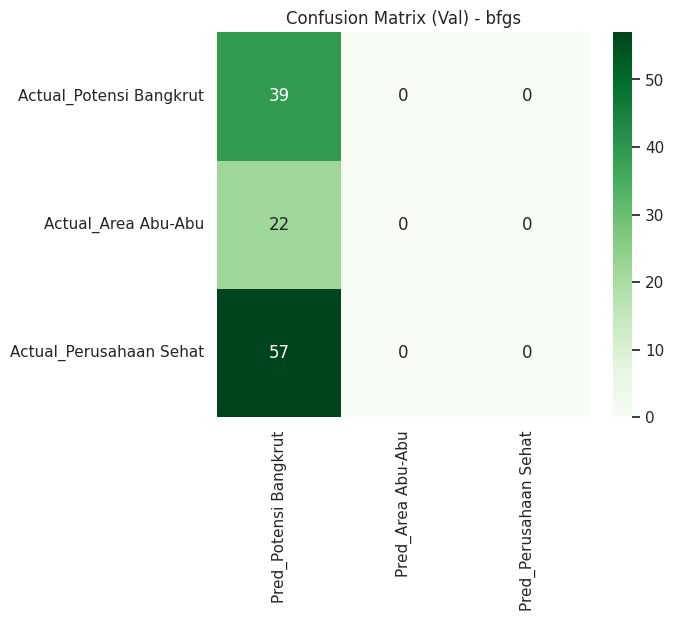


🚀 Melatih model MNLogit dengan metode: lbfgs


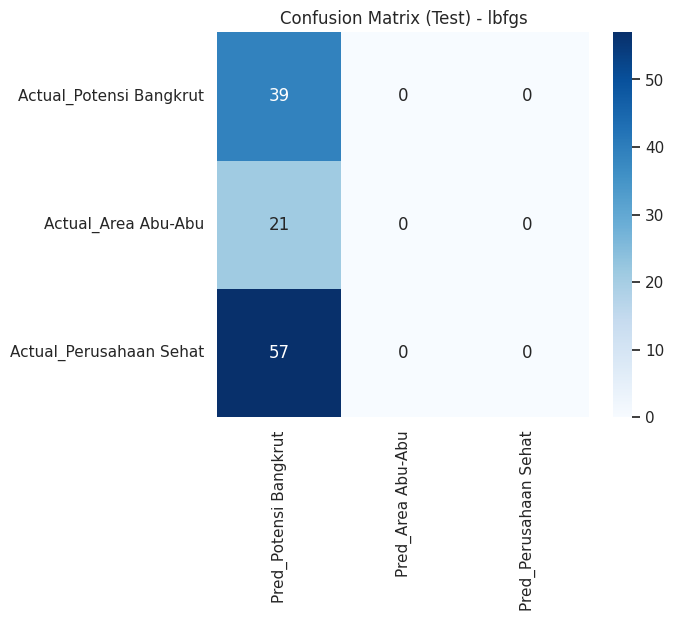

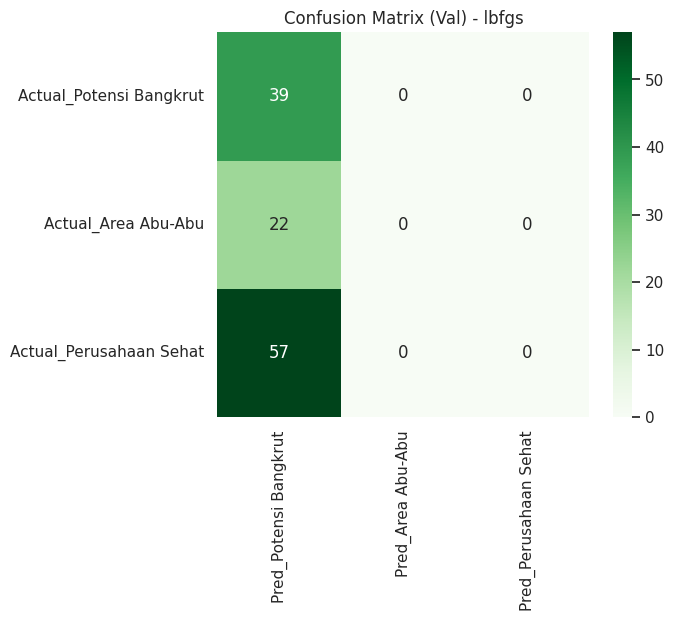


🚀 Melatih model MNLogit dengan metode: powell
❌ Gagal dengan metode: powell
Error: Input y_pred contains NaN.

🚀 Melatih model MNLogit dengan metode: cg


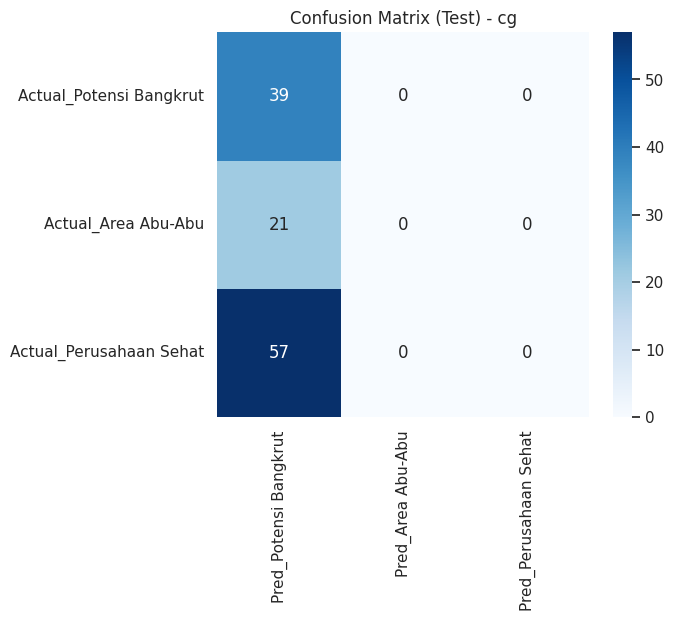

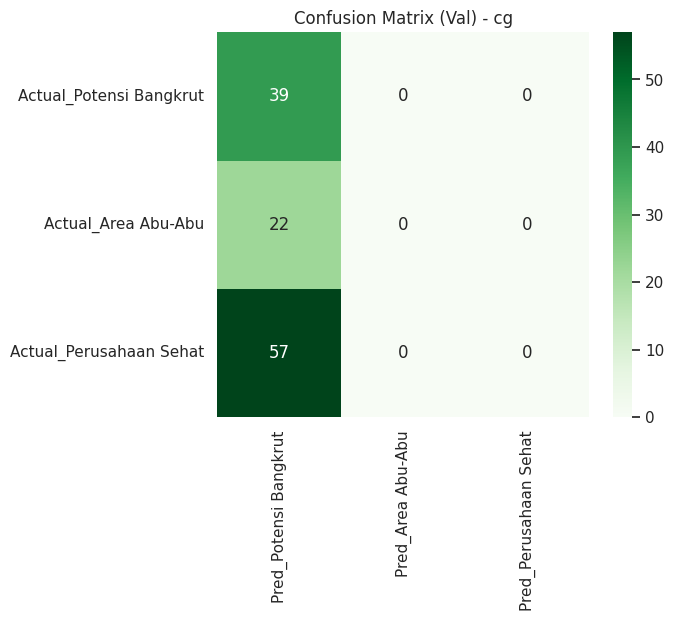


🚀 Melatih model MNLogit dengan metode: ncg


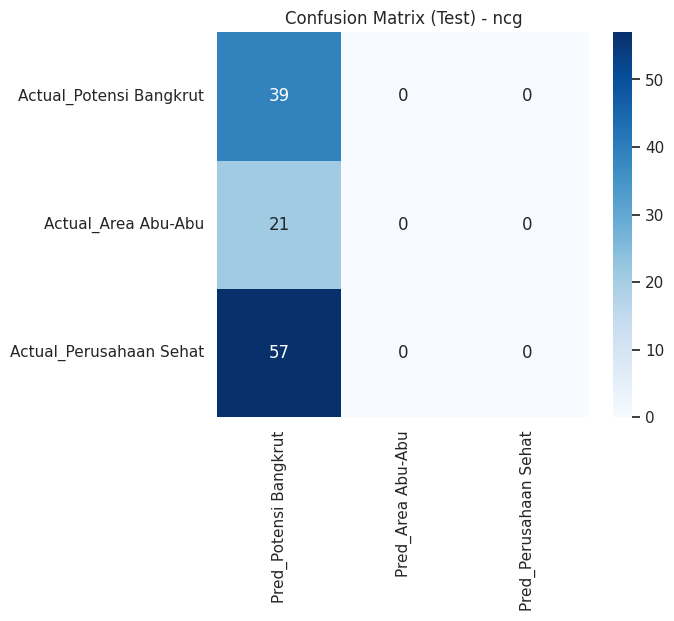

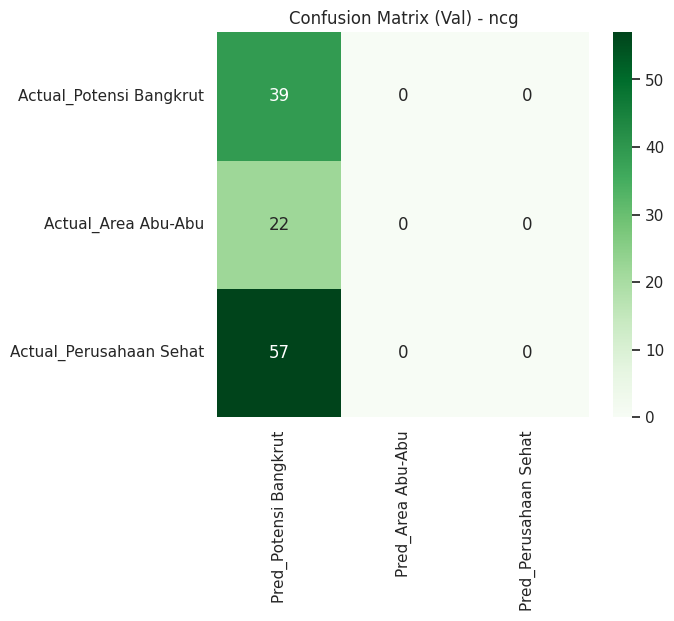


🚀 Melatih model MNLogit dengan metode: minimize


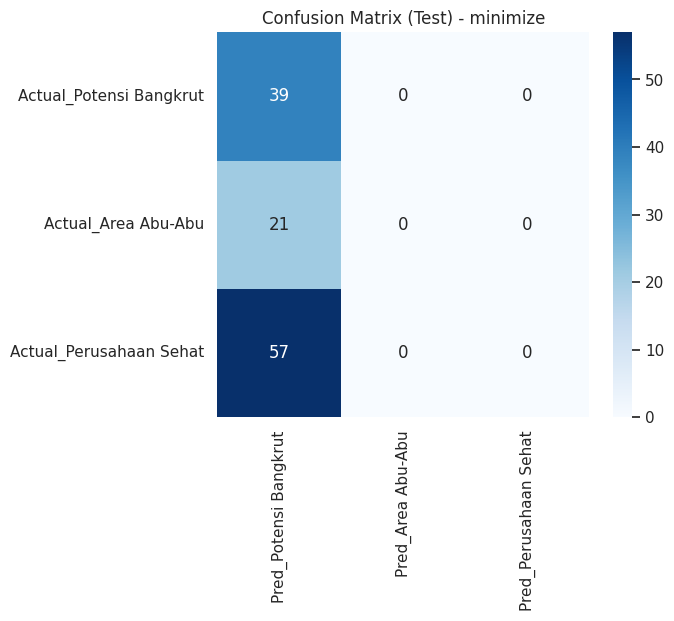

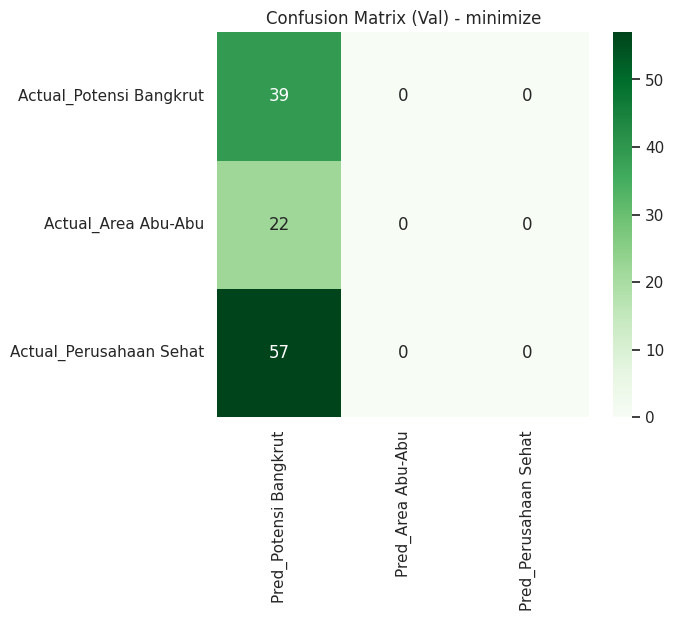



📋 Ringkasan Hasil Evaluasi Semua Metode:


,Method,Converged,Iterations,Pseudo_R2,AIC,BIC,LogLik,Acc_Test,Prec_Test,Recall_Test,F1_Test,Acc_Val,Prec_Val,Recall_Val,F1_Val
0,newton,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,nm,True,261,-0.023735,2036.858663,2201.473590,-984.429332,0.333333,0.111111,0.333333,0.166667,0.338983,0.444444,0.339181,0.178161
2,bfgs,False,N/A,-0.069358,2124.602204,2289.217131,-1028.301102,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605
3,lbfgs,False,1,NaN,NaN,NaN,NaN,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605
4,powell,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cg,False,N/A,-0.069358,2124.602204,2289.217131,-1028.301102,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605
6,ncg,True,N/A,-0.026232,2041.660205,2206.275131,-986.830102,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605
7,minimize,False,0,-0.069358,2124.602204,2289.217131,-1028.301102,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605


In [38]:
# menggunakan data tanpa prep dengan semua atribut
evaluate_mnlogit(
    X_train=X_train_tanpa, y_train=y_train_tanpa,
    X_test=X_test_tanpa, y_test=y_test_tanpa,
    X_val=X_val_tanpa, y_val=y_val_tanpa,
)

## Pemodelan dengan prep

### Masih menggunakan 10 atribut

🚀 Melatih model MNLogit dengan metode: newton


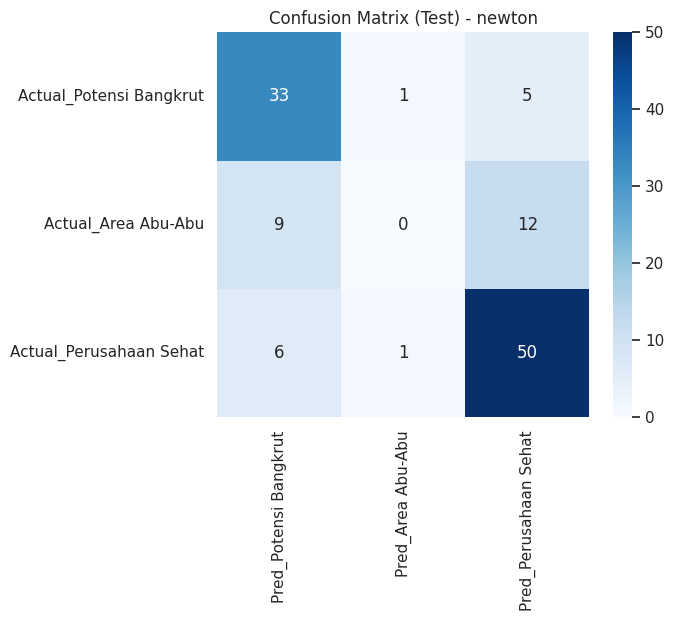

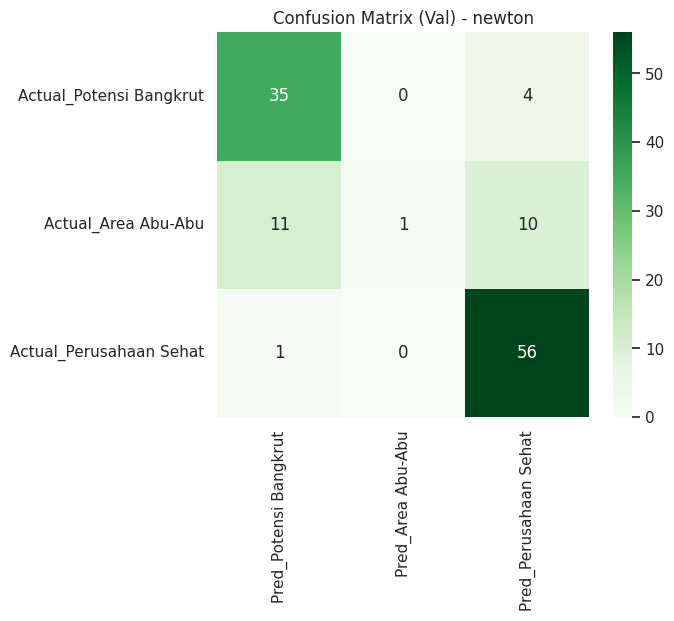


🚀 Melatih model MNLogit dengan metode: nm


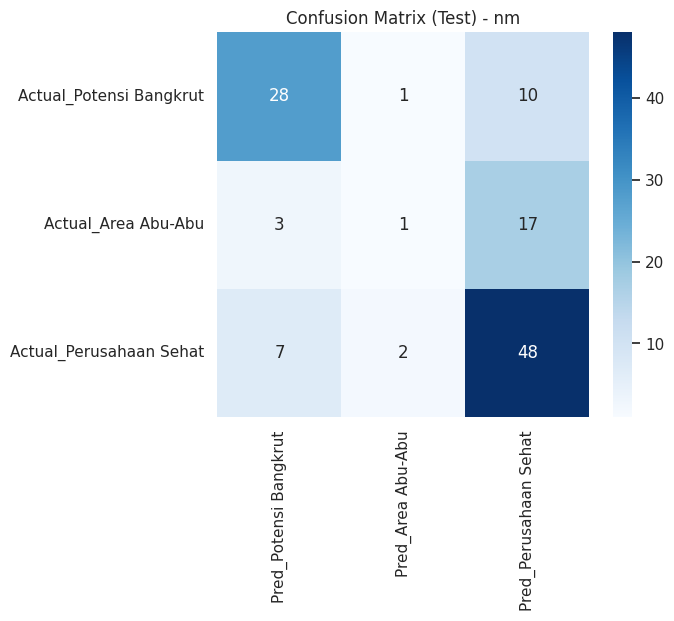

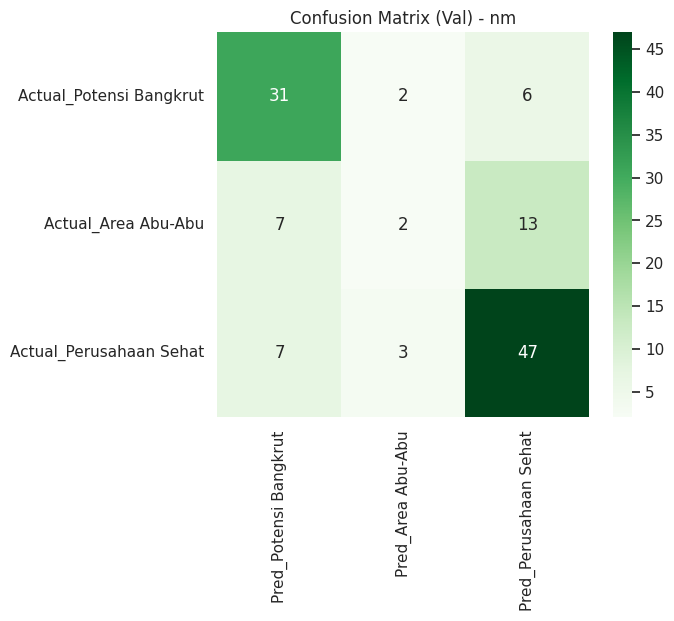


🚀 Melatih model MNLogit dengan metode: bfgs


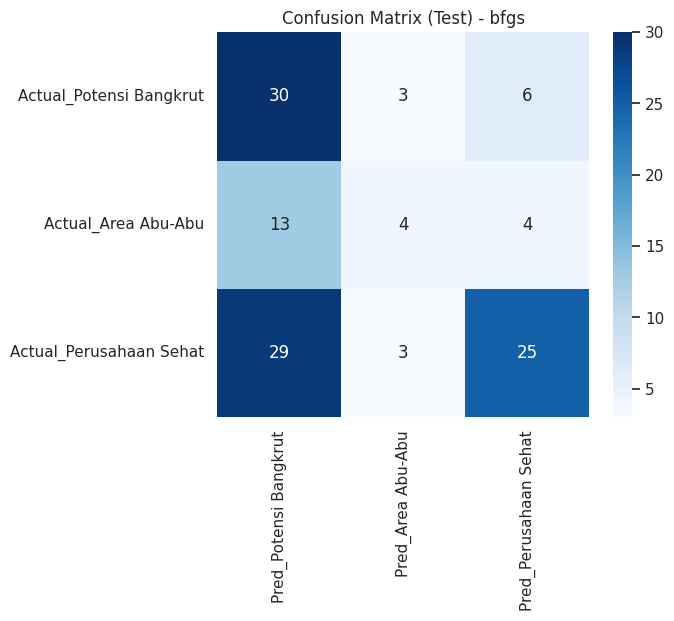

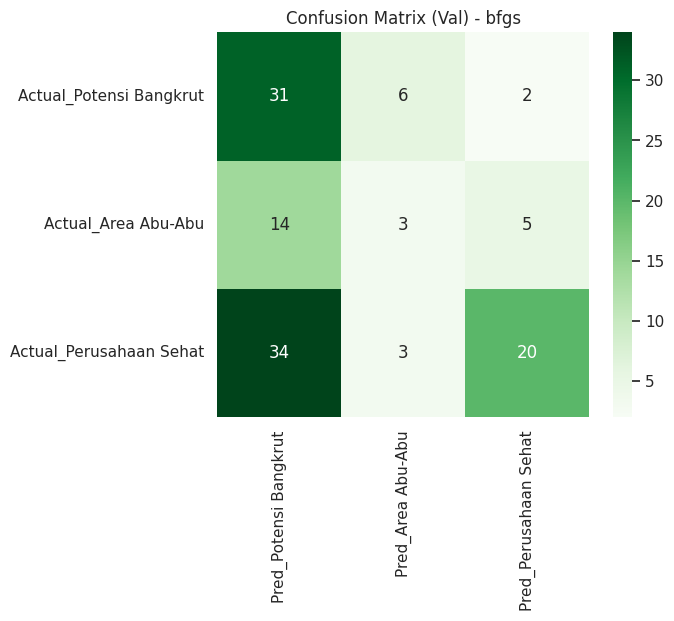


🚀 Melatih model MNLogit dengan metode: lbfgs


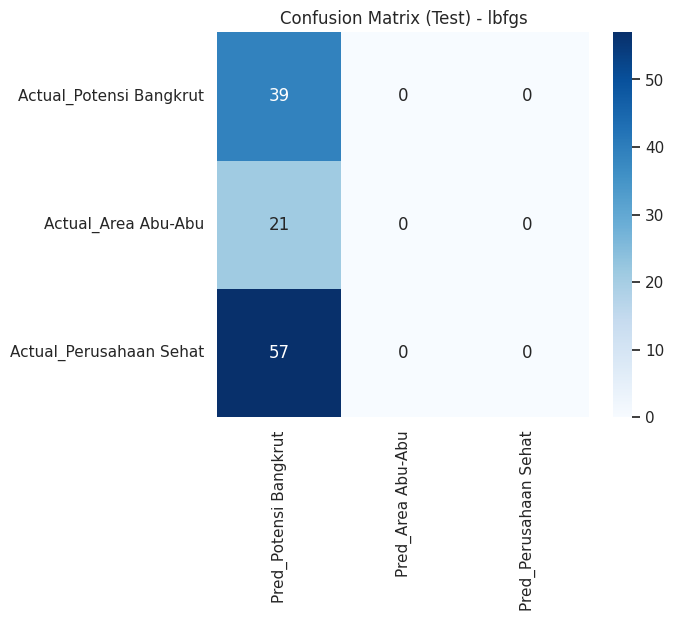

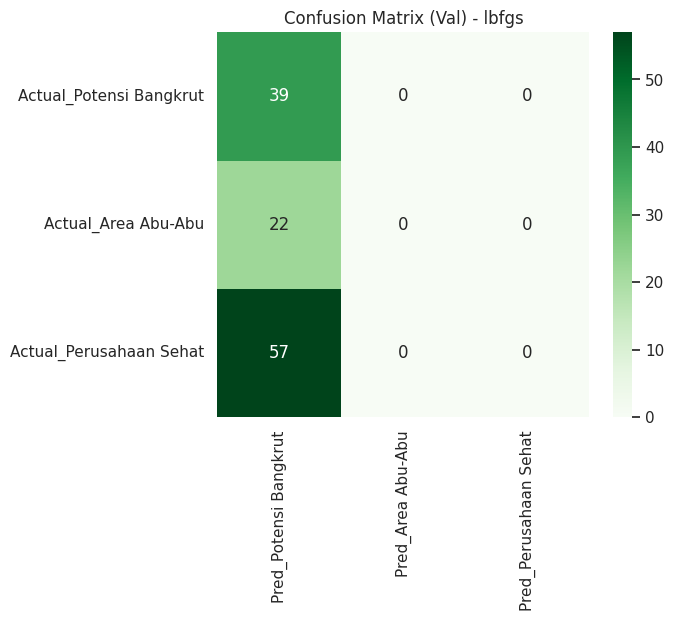


🚀 Melatih model MNLogit dengan metode: powell
❌ Gagal dengan metode: powell
Error: Input y_pred contains NaN.

🚀 Melatih model MNLogit dengan metode: cg


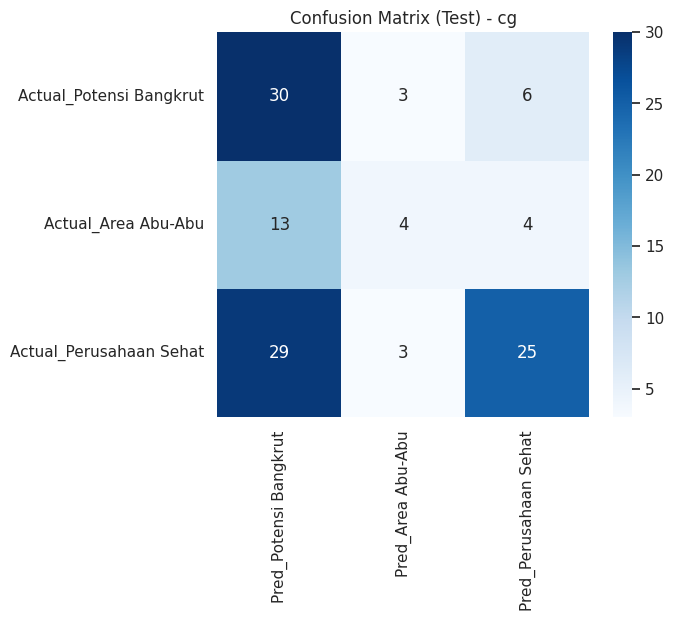

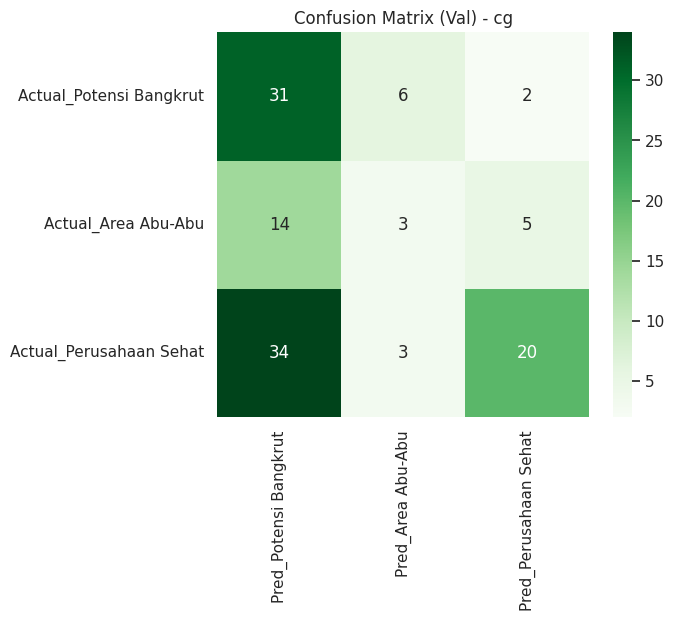


🚀 Melatih model MNLogit dengan metode: ncg


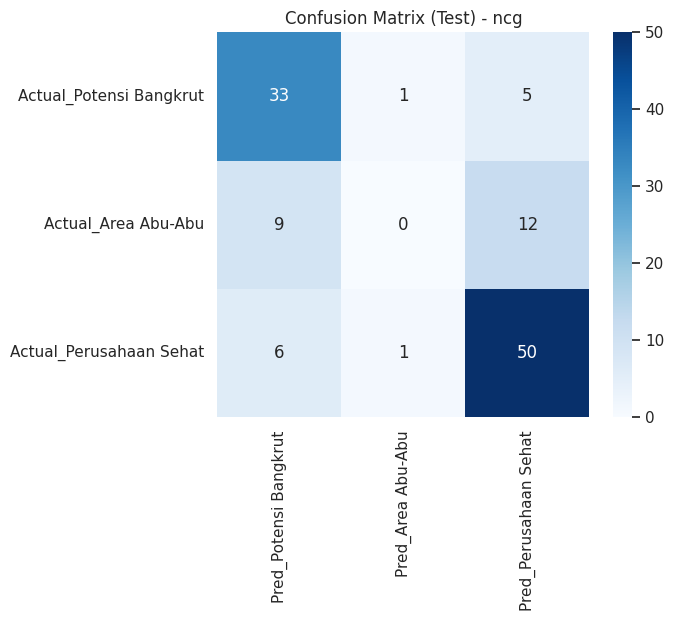

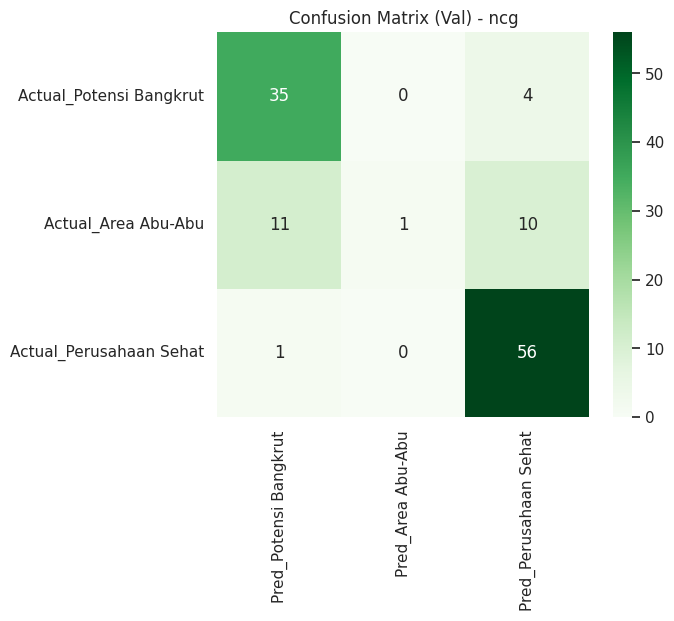


🚀 Melatih model MNLogit dengan metode: minimize


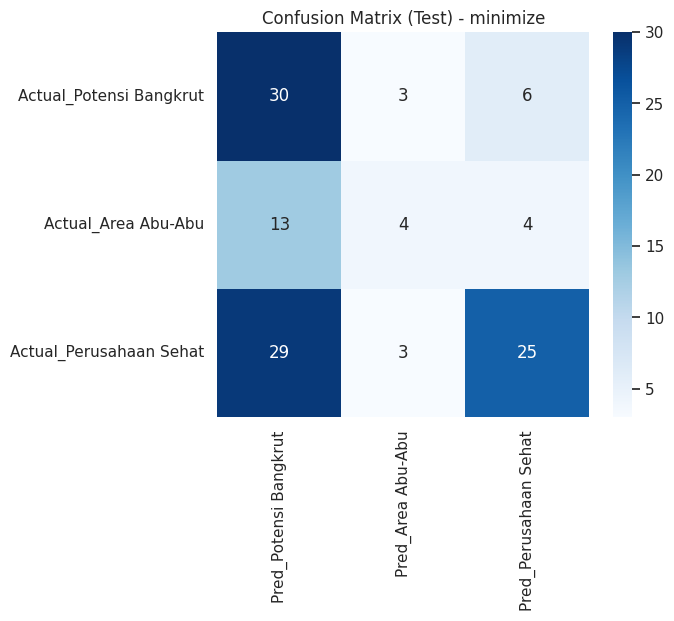

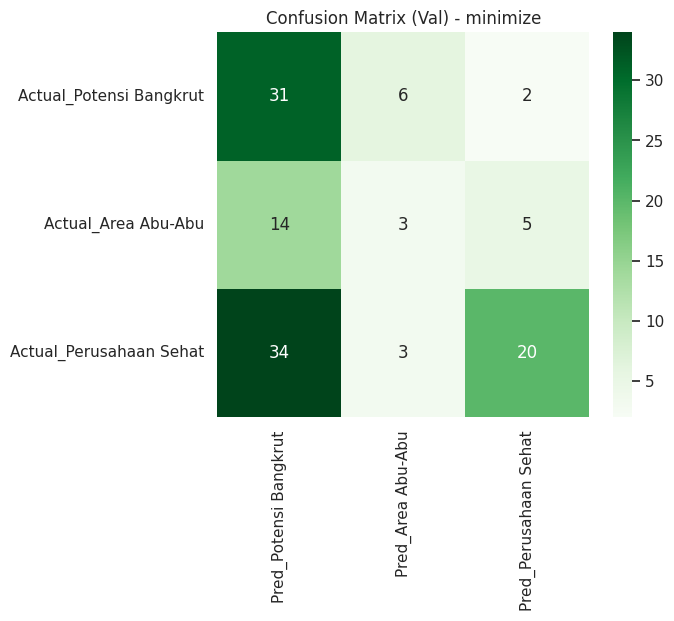



📋 Ringkasan Hasil Evaluasi Semua Metode:


,Method,Converged,Iterations,Pseudo_R2,AIC,BIC,LogLik,Acc_Test,Prec_Test,Recall_Test,F1_Test,Acc_Val,Prec_Val,Recall_Val,F1_Val
0,newton,True,11,0.340075,1313.175780,1419.691321,-634.587890,0.709402,0.477923,0.574449,0.521691,0.779661,0.848227,0.641782,0.594267
1,nm,True,4494,0.133529,1710.405918,1816.921458,-833.202959,0.658120,0.542281,0.535891,0.511515,0.677966,0.562241,0.570114,0.546751
2,bfgs,False,N/A,NaN,NaN,NaN,NaN,0.504274,0.510317,0.466101,0.447361,0.457627,0.461049,0.427371,0.392695
3,lbfgs,False,0,-0.069358,2100.602204,2207.117745,-1028.301102,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605
4,powell,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cg,False,N/A,NaN,NaN,NaN,NaN,0.504274,0.510317,0.466101,0.447361,0.457627,0.461049,0.427371,0.392695
6,ncg,True,N/A,0.340075,1313.175780,1419.691321,-634.587890,0.709402,0.477923,0.574449,0.521691,0.779661,0.848227,0.641782,0.594267
7,minimize,False,1,NaN,NaN,NaN,NaN,0.504274,0.510317,0.466101,0.447361,0.457627,0.461049,0.427371,0.392695


In [39]:
# menggunakan data hasil robust scaler dengan 10 atribut
evaluate_mnlogit(
    X_train=X_train_scaled_robust, y_train=y_train_prep,
    X_test=X_test_scaled_robust, y_test=y_test_prep,
    X_val=X_val_scaled_robust, y_val=y_val_prep,
)

🚀 Melatih model MNLogit dengan metode: newton
❌ Gagal dengan metode: newton
Error: Input y_pred contains NaN.

🚀 Melatih model MNLogit dengan metode: nm


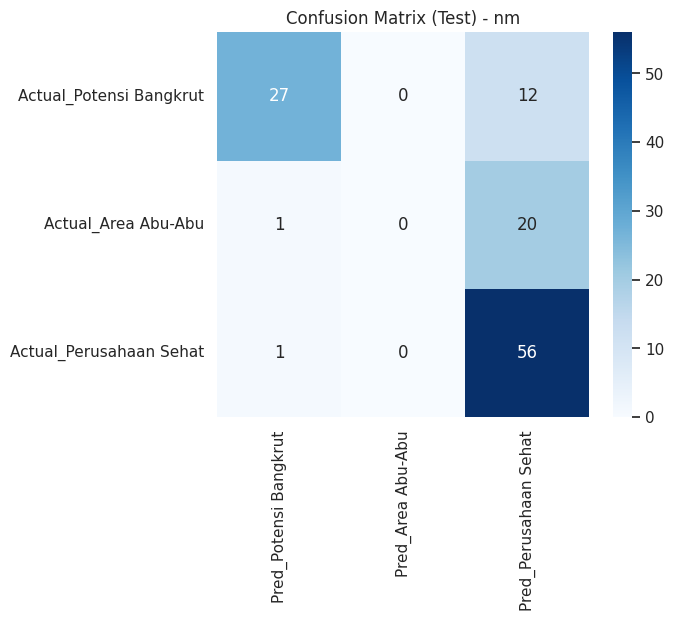

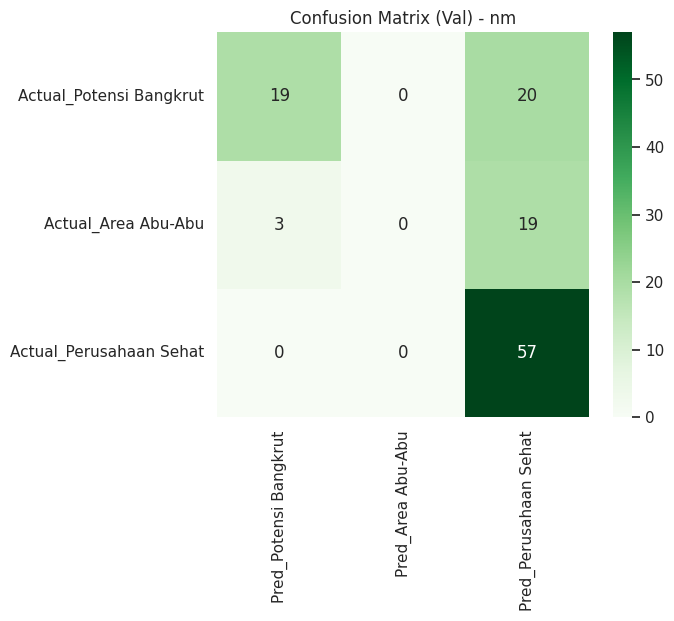


🚀 Melatih model MNLogit dengan metode: bfgs


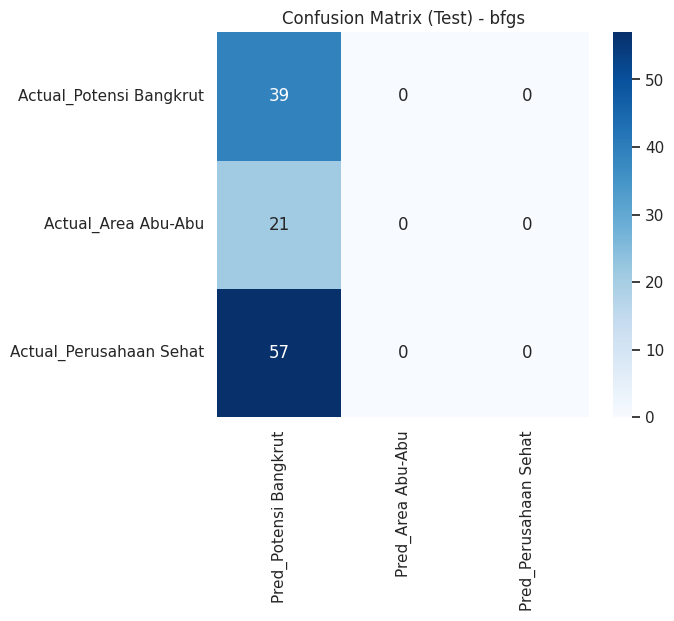

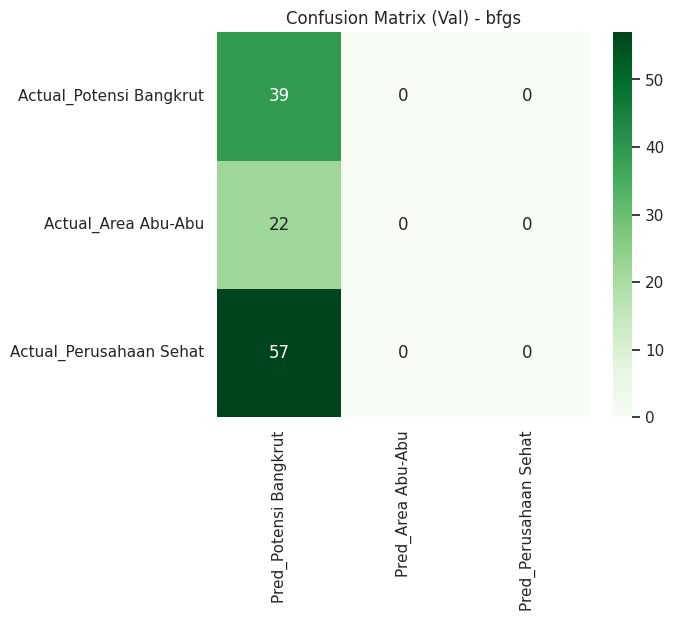


🚀 Melatih model MNLogit dengan metode: lbfgs


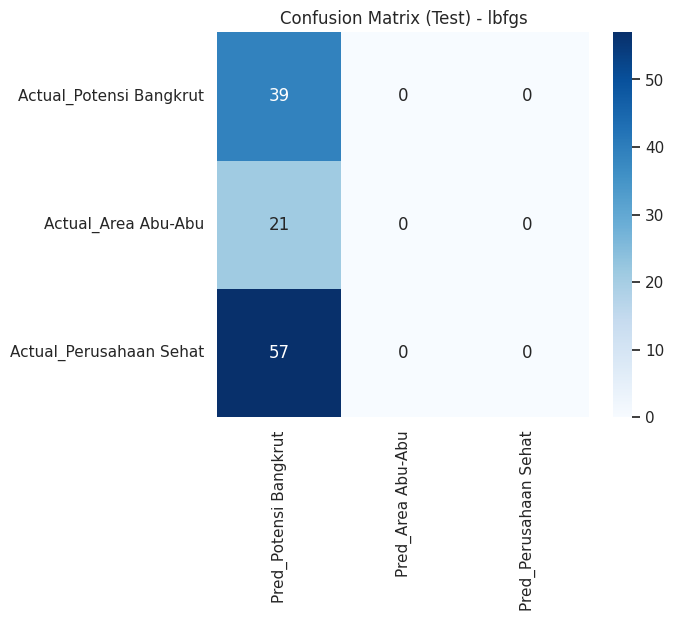

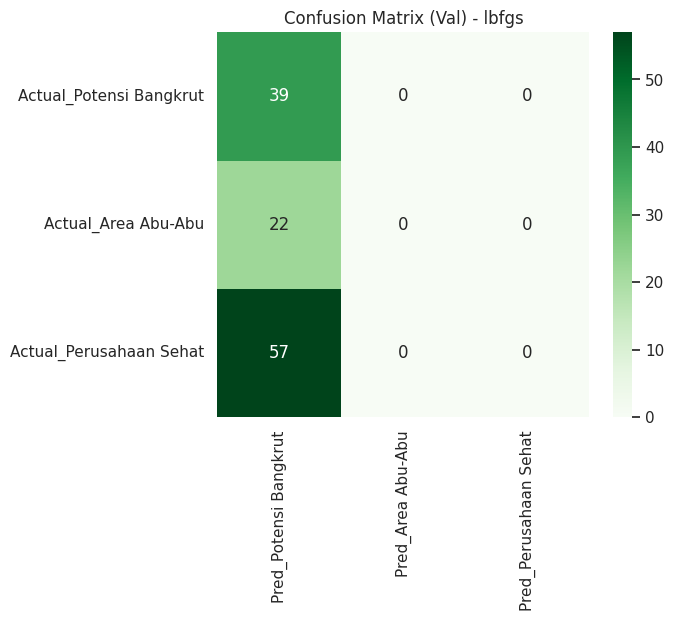


🚀 Melatih model MNLogit dengan metode: powell
❌ Gagal dengan metode: powell
Error: Input y_pred contains NaN.

🚀 Melatih model MNLogit dengan metode: cg


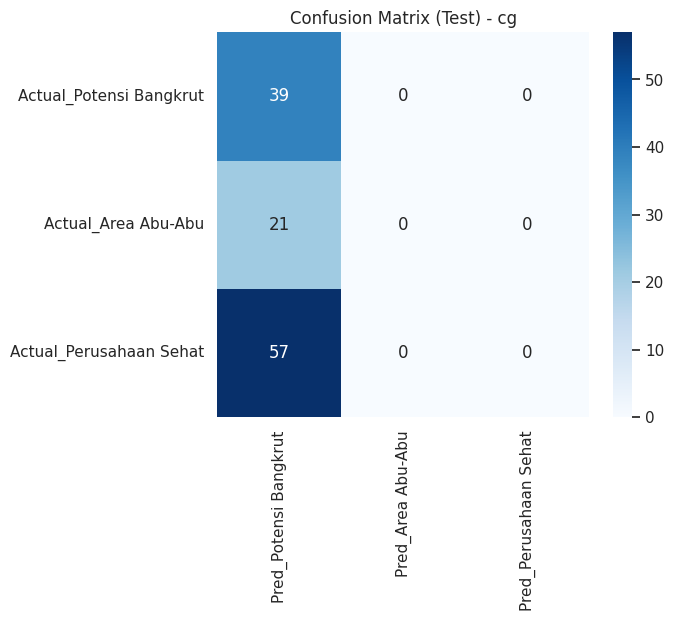

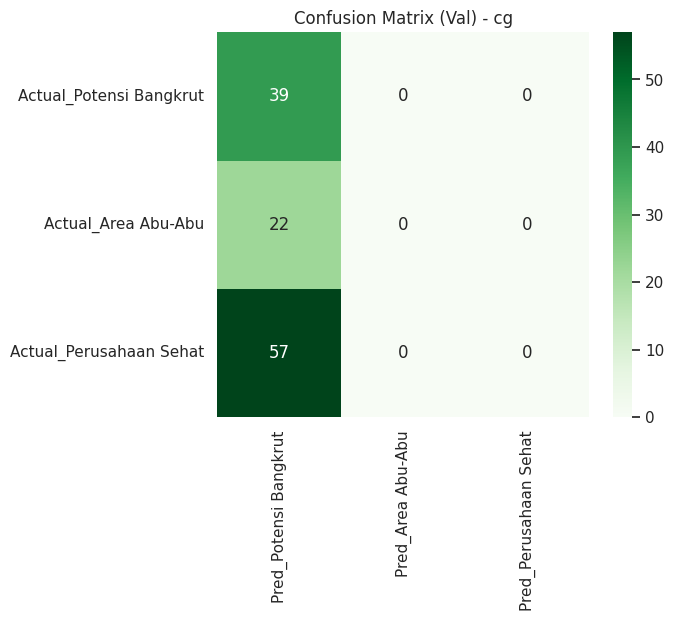


🚀 Melatih model MNLogit dengan metode: ncg


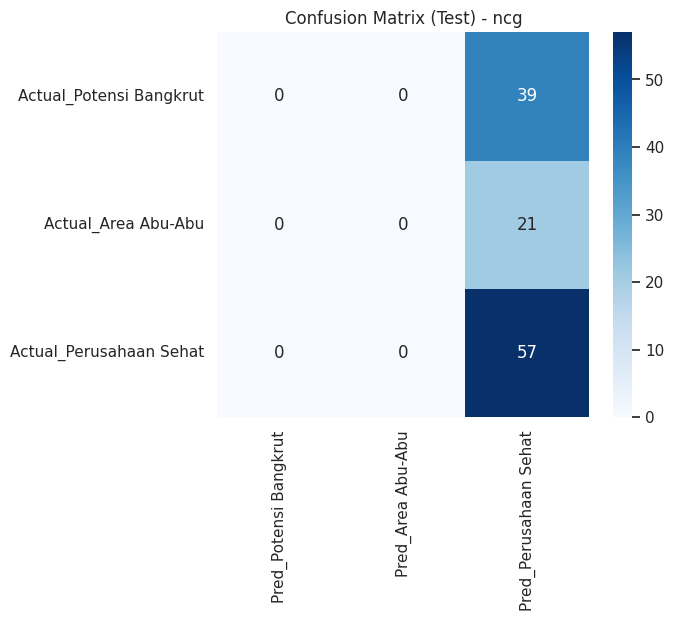

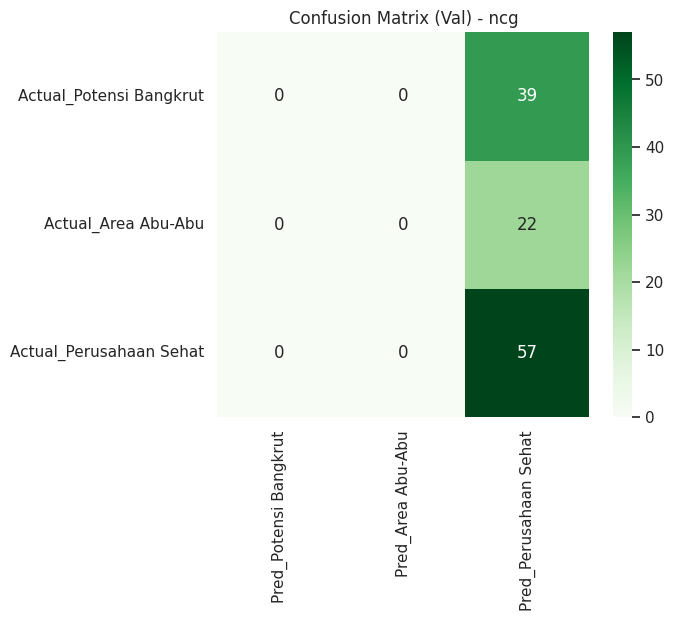


🚀 Melatih model MNLogit dengan metode: minimize


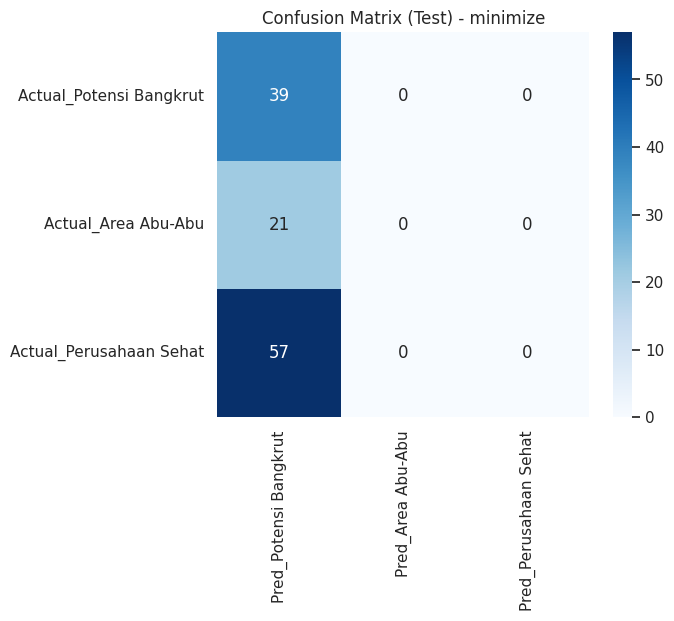

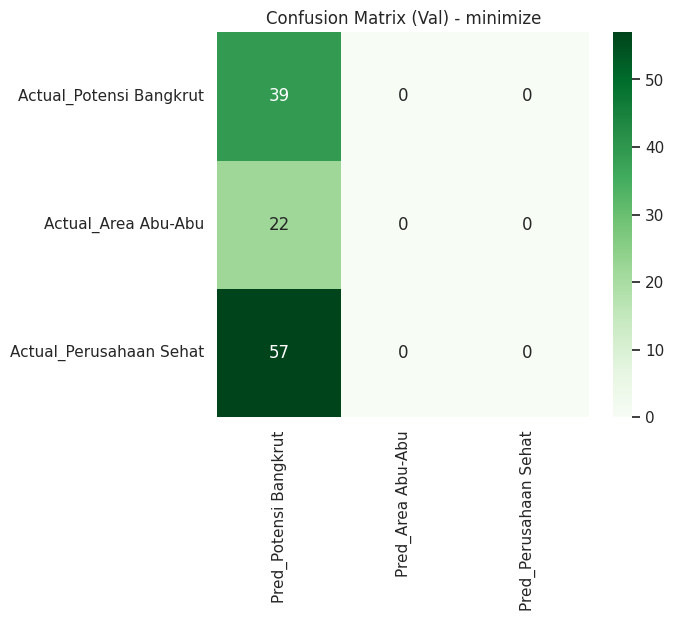



📋 Ringkasan Hasil Evaluasi Semua Metode:


,Method,Converged,Iterations,Pseudo_R2,AIC,BIC,LogLik,Acc_Test,Prec_Test,Recall_Test,F1_Test,Acc_Val,Prec_Val,Recall_Val,F1_Val
0,newton,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,nm,True,7306,0.343198,1307.169644,1413.685184,-631.584822,0.709402,0.522466,0.558255,0.522177,0.644068,0.485795,0.495726,0.456016
2,bfgs,False,N/A,NaN,NaN,NaN,NaN,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605
3,lbfgs,False,0,-0.069358,2100.602204,2207.117745,-1028.301102,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605
4,powell,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cg,False,N/A,NaN,NaN,NaN,NaN,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605
6,ncg,True,N/A,-0.026478,2018.134564,2124.650105,-987.067282,0.487179,0.162393,0.333333,0.218391,0.483051,0.161017,0.333333,0.217143
7,minimize,False,1,NaN,NaN,NaN,NaN,0.333333,0.111111,0.333333,0.166667,0.330508,0.110169,0.333333,0.165605


In [40]:
# menggunakan data hasil transformasi klasik
evaluate_mnlogit(
    X_train=X_train_trans, y_train=y_train_prep,
    X_test=X_test_trans, y_test=y_test_prep,
    X_val=X_val_trans, y_val=y_val_prep,
)

🚀 Melatih model MNLogit dengan metode: newton


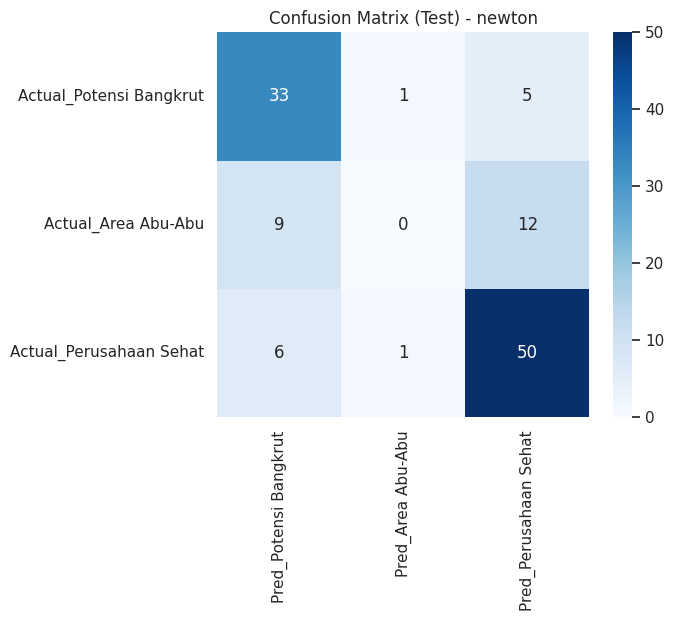

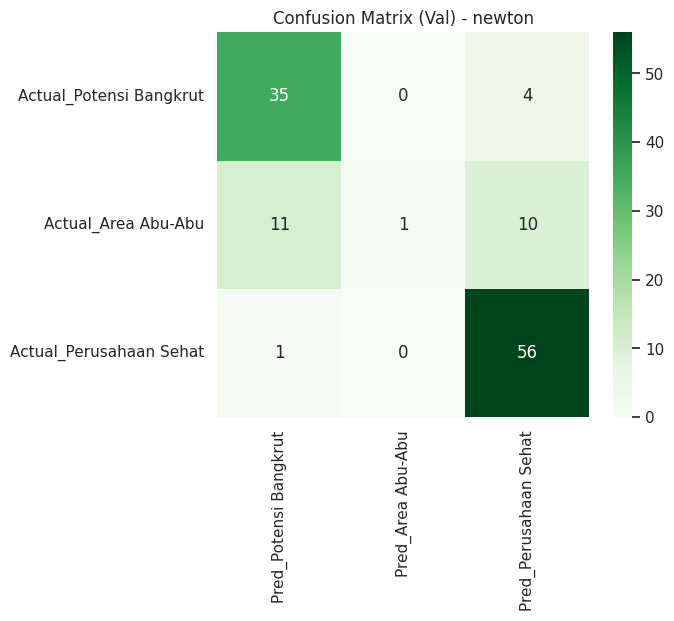


🚀 Melatih model MNLogit dengan metode: nm


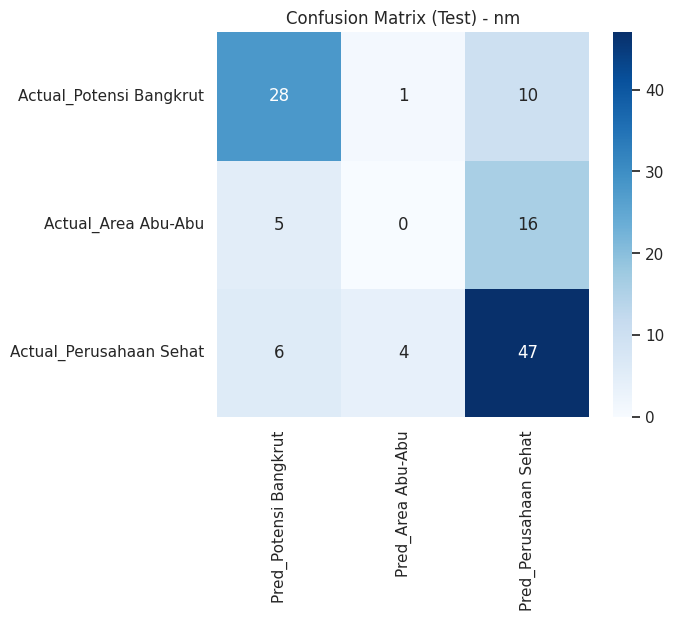

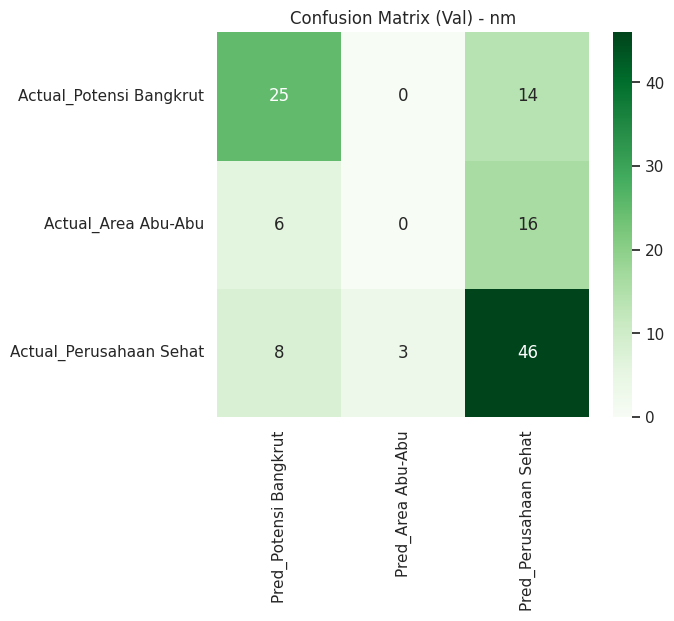


🚀 Melatih model MNLogit dengan metode: bfgs


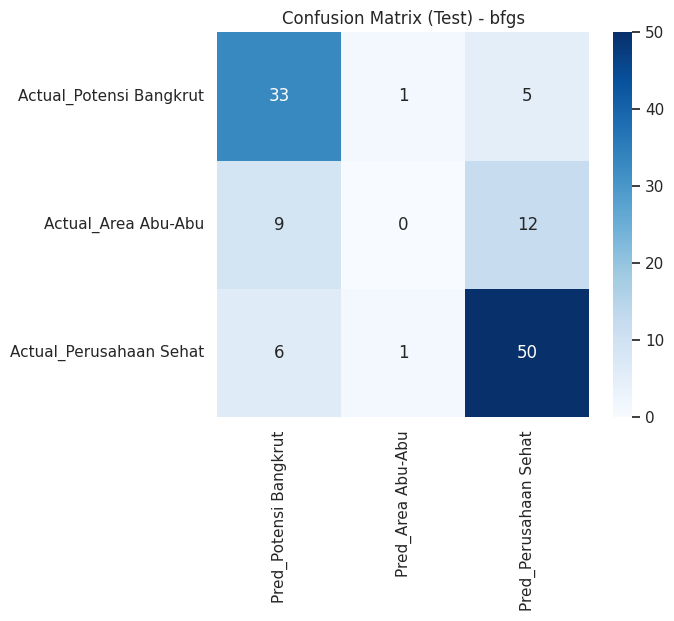

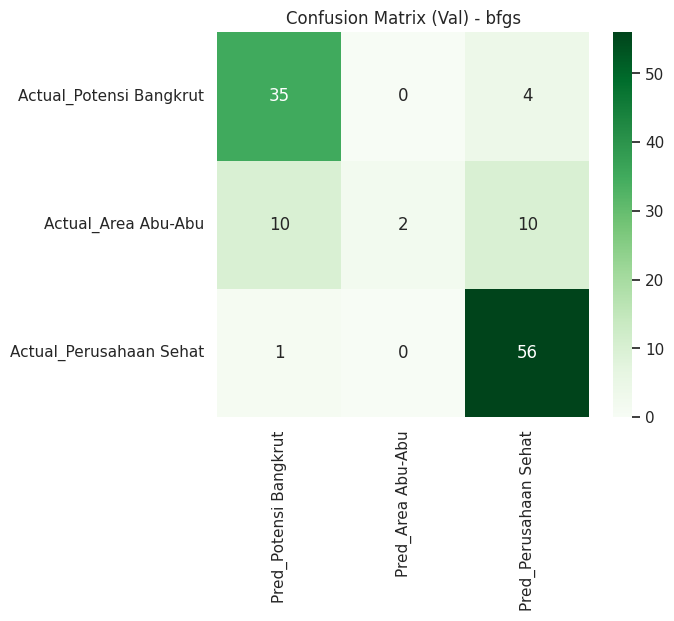


🚀 Melatih model MNLogit dengan metode: lbfgs


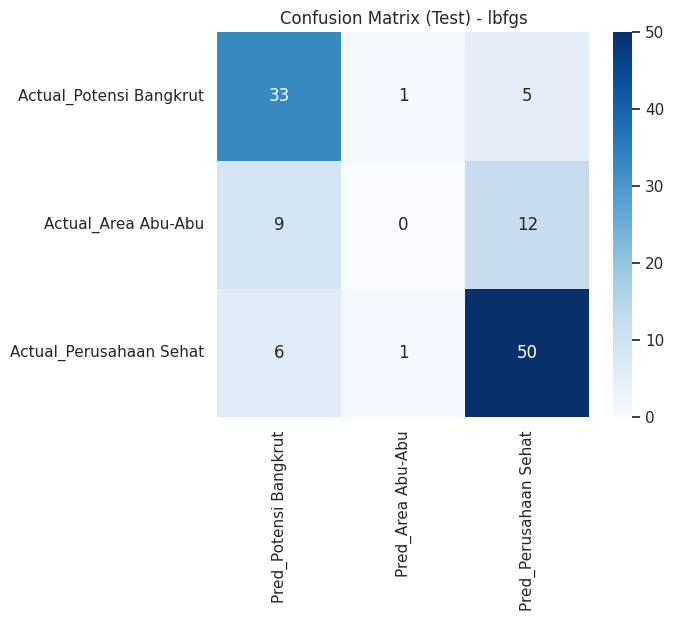

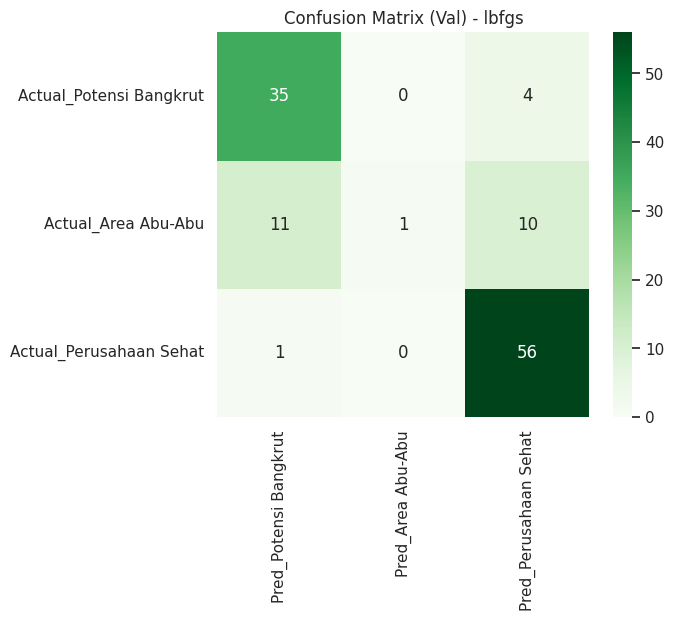


🚀 Melatih model MNLogit dengan metode: powell


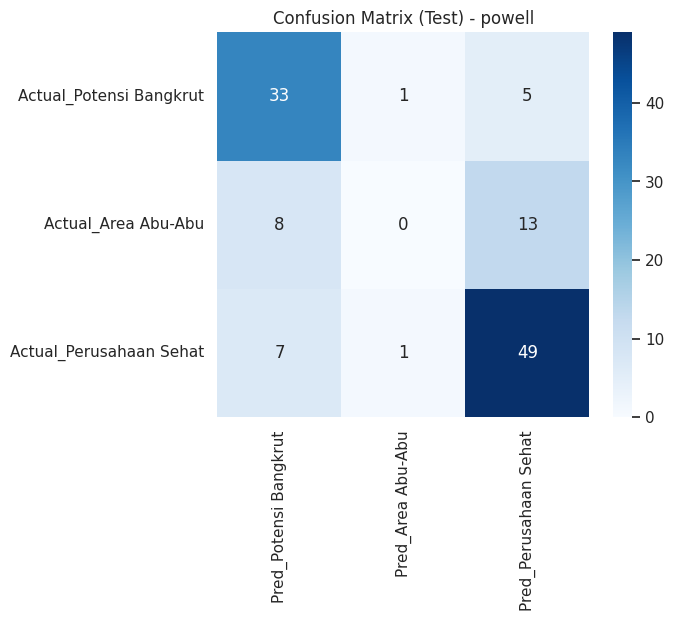

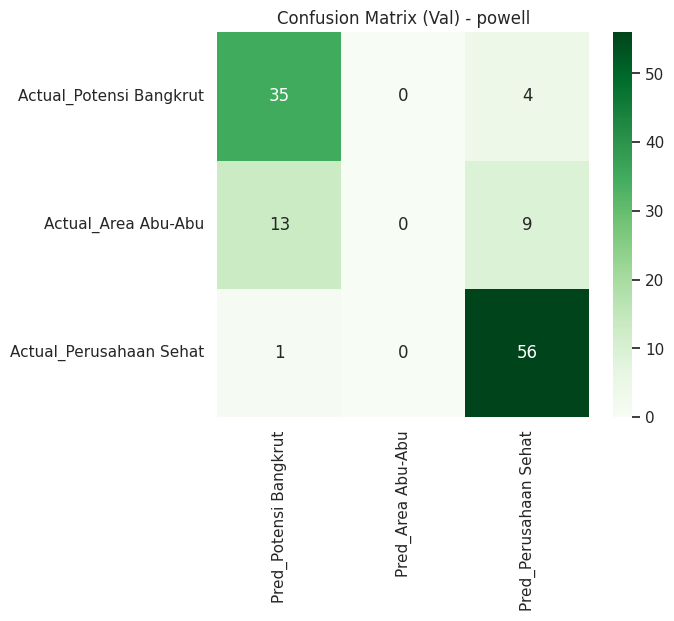


🚀 Melatih model MNLogit dengan metode: cg


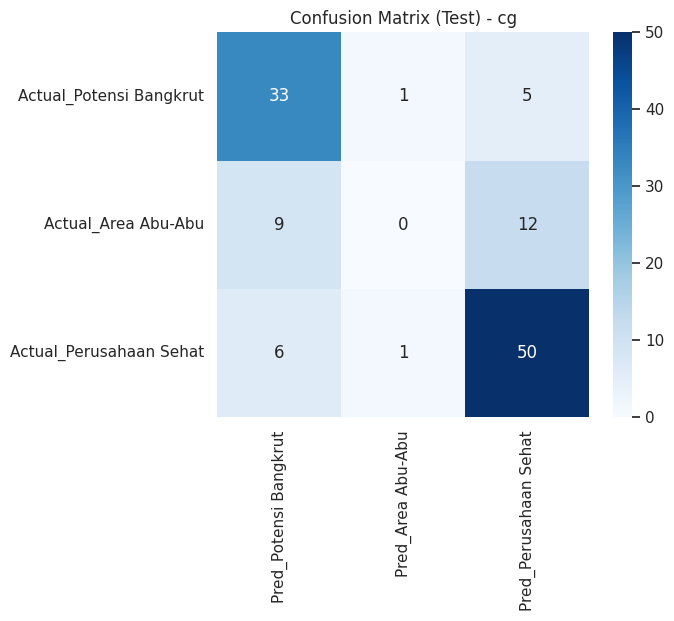

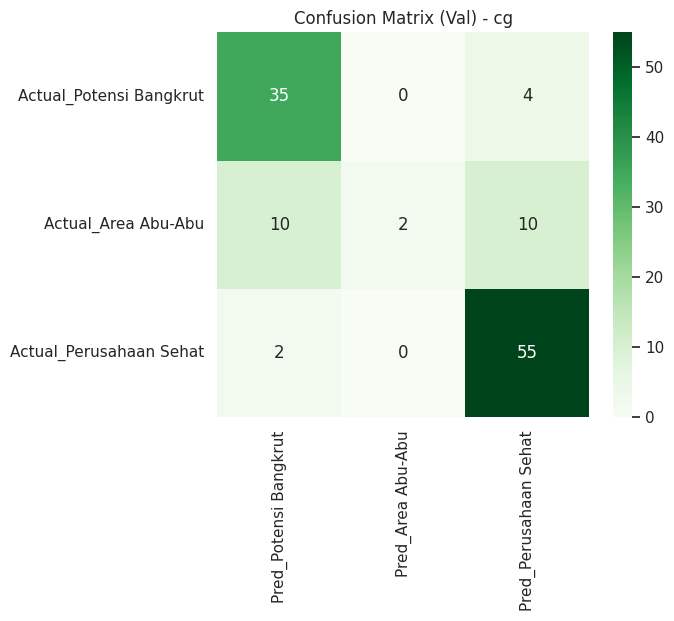


🚀 Melatih model MNLogit dengan metode: ncg


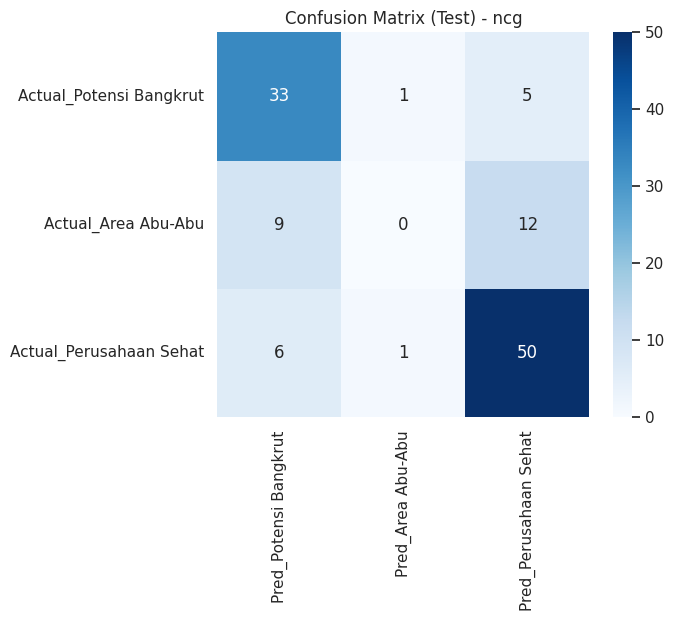

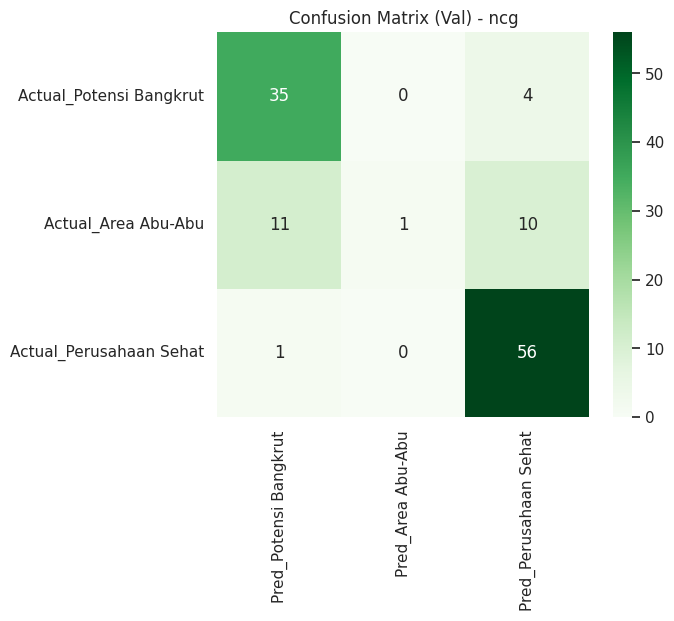


🚀 Melatih model MNLogit dengan metode: minimize


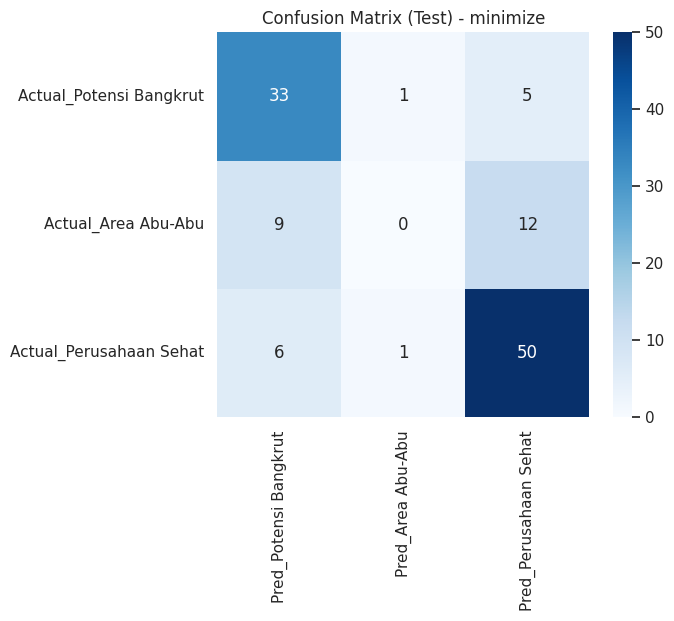

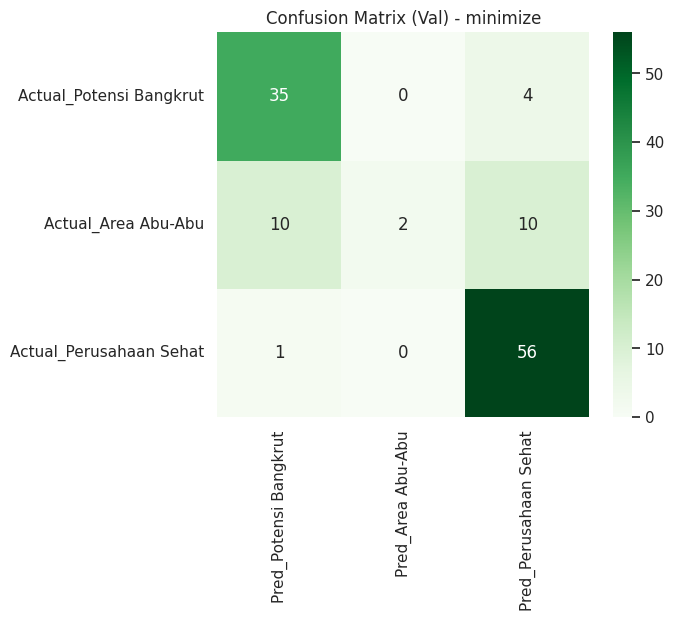



📋 Ringkasan Hasil Evaluasi Semua Metode:


,Method,Converged,Iterations,Pseudo_R2,AIC,BIC,LogLik,Acc_Test,Prec_Test,Recall_Test,F1_Test,Acc_Val,Prec_Val,Recall_Val,F1_Val
0,newton,True,13,0.340075,1313.175780,1419.691321,-634.587890,0.709402,0.477923,0.574449,0.521691,0.779661,0.848227,0.641782,0.594267
1,nm,True,9282,0.111263,1753.228849,1859.744390,-854.614425,0.641026,0.453928,0.514170,0.480342,0.601695,0.415430,0.482681,0.444252
2,bfgs,True,N/A,0.337745,1317.655529,1424.171069,-636.827764,0.709402,0.477923,0.574449,0.521691,0.788136,0.853623,0.656934,0.624029
3,lbfgs,True,2355,0.339981,1313.355390,1419.870930,-634.677695,0.709402,0.477923,0.574449,0.521691,0.779661,0.848227,0.641782,0.594267
4,powell,True,14,0.331337,1329.979329,1436.494869,-642.989664,0.700855,0.472948,0.568601,0.516314,0.771186,0.508627,0.626631,0.561448
5,cg,True,N/A,0.337784,1317.580994,1424.096534,-636.790497,0.709402,0.477923,0.574449,0.521691,0.779661,0.847261,0.651086,0.617879
6,ncg,True,N/A,0.340067,1313.191273,1419.706814,-634.595637,0.709402,0.477923,0.574449,0.521691,0.779661,0.848227,0.641782,0.594267
7,minimize,True,282,0.337745,1317.655529,1424.171069,-636.827764,0.709402,0.477923,0.574449,0.521691,0.788136,0.853623,0.656934,0.624029


In [41]:
evaluate_mnlogit(
    X_train=X_train_scaled_minmax, y_train=y_train_prep,
    X_test=X_test_scaled_minmax, y_test=y_test_prep,
    X_val=X_val_scaled_minmax, y_val=y_val_prep,
)

🚀 Melatih model MNLogit dengan metode: newton


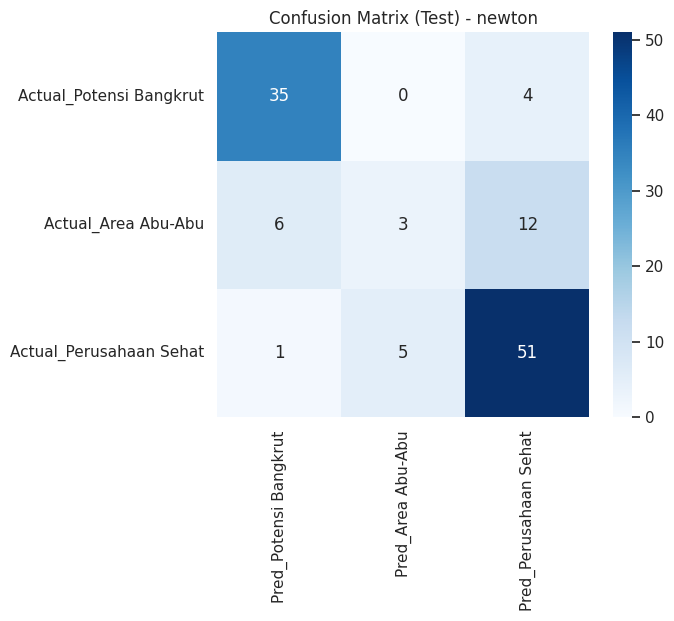

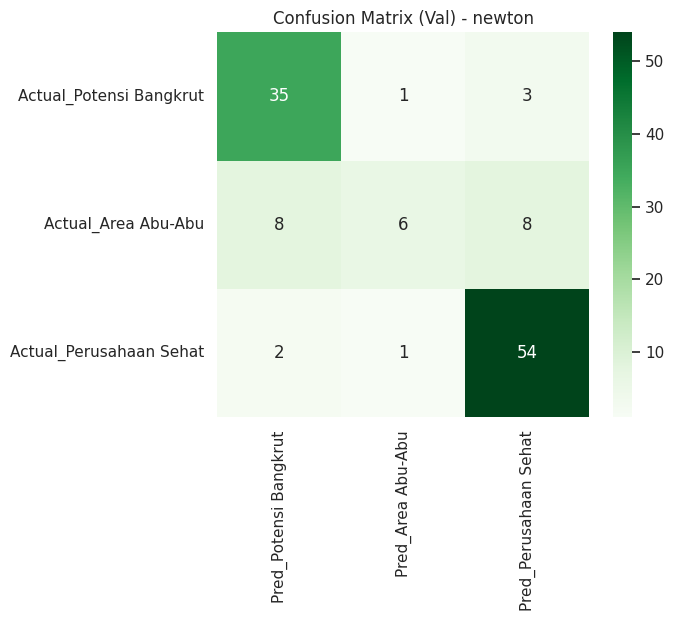


🚀 Melatih model MNLogit dengan metode: nm


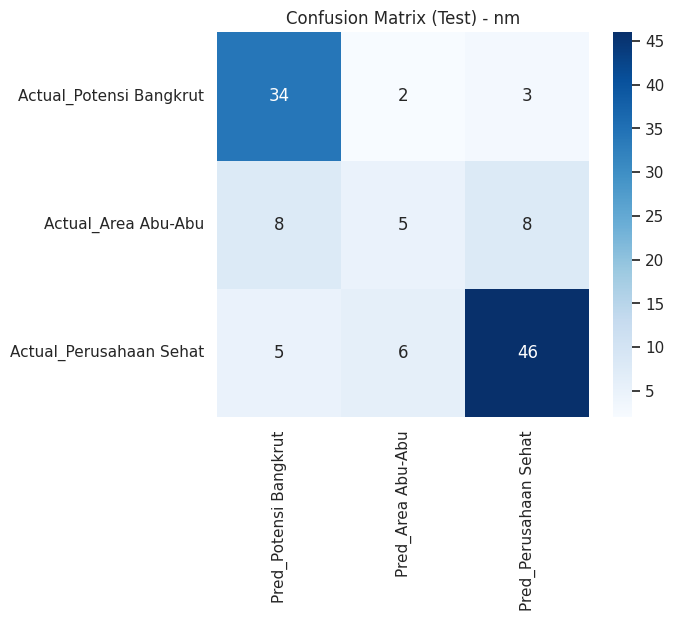

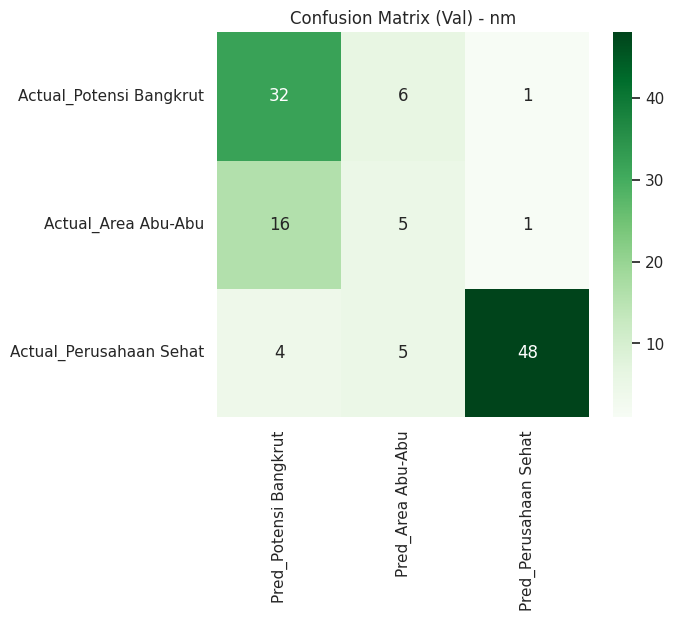


🚀 Melatih model MNLogit dengan metode: bfgs


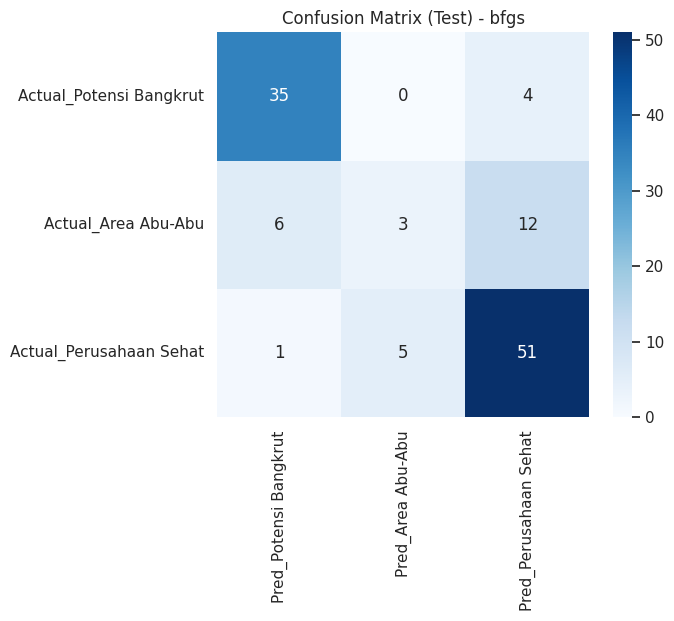

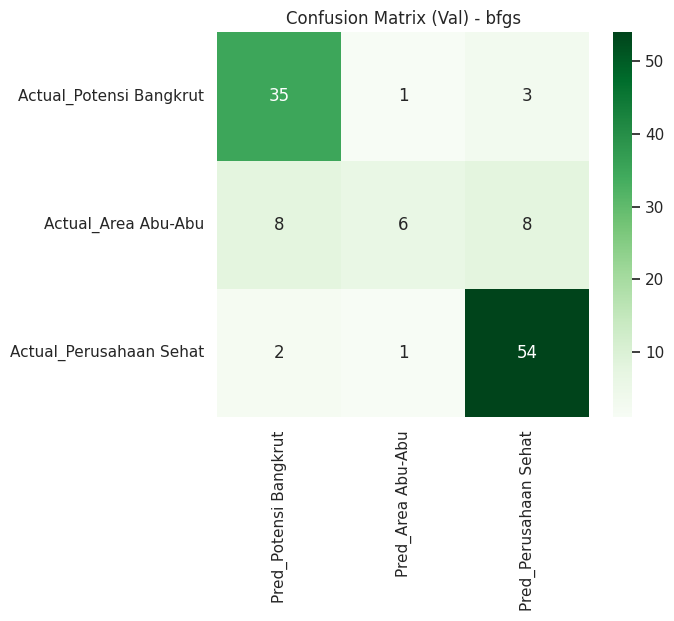


🚀 Melatih model MNLogit dengan metode: lbfgs


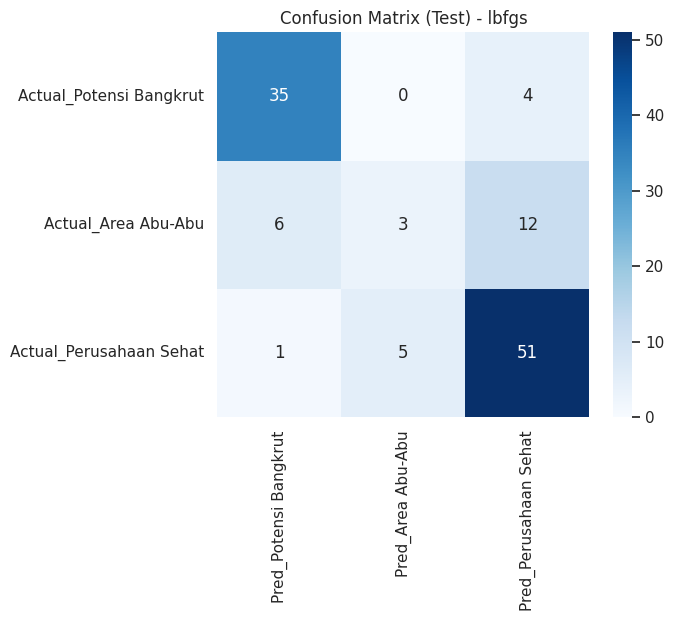

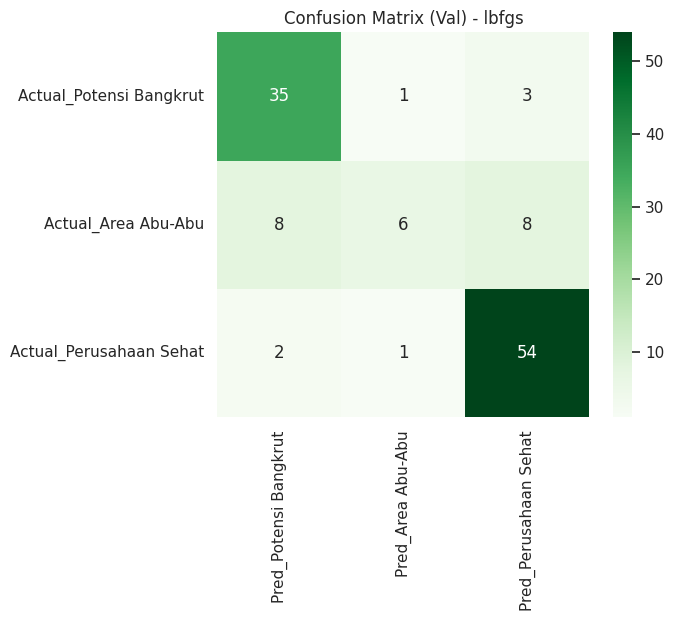


🚀 Melatih model MNLogit dengan metode: powell


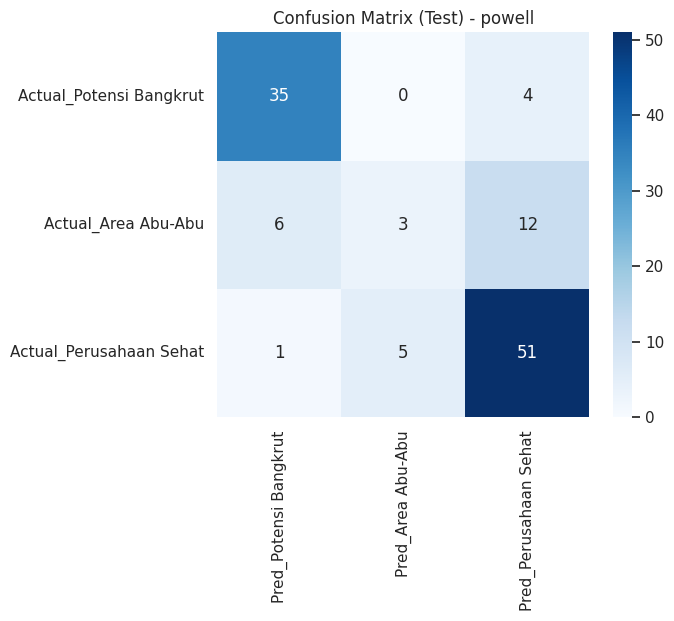

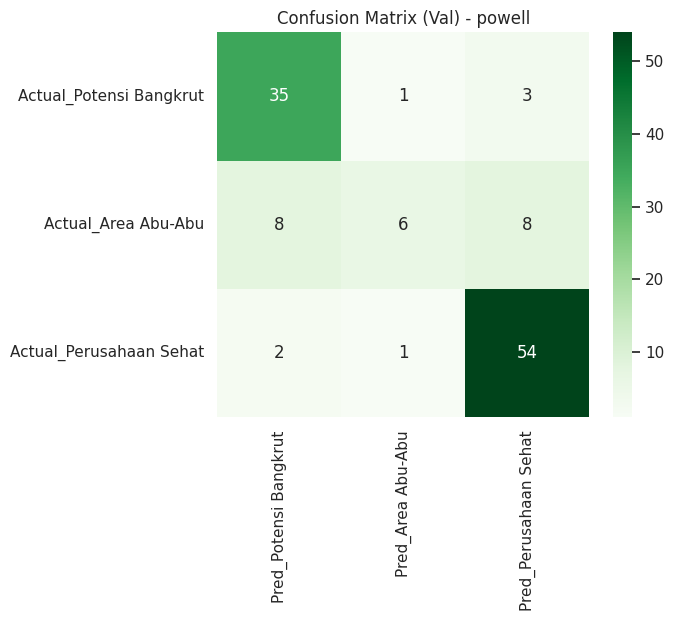


🚀 Melatih model MNLogit dengan metode: cg


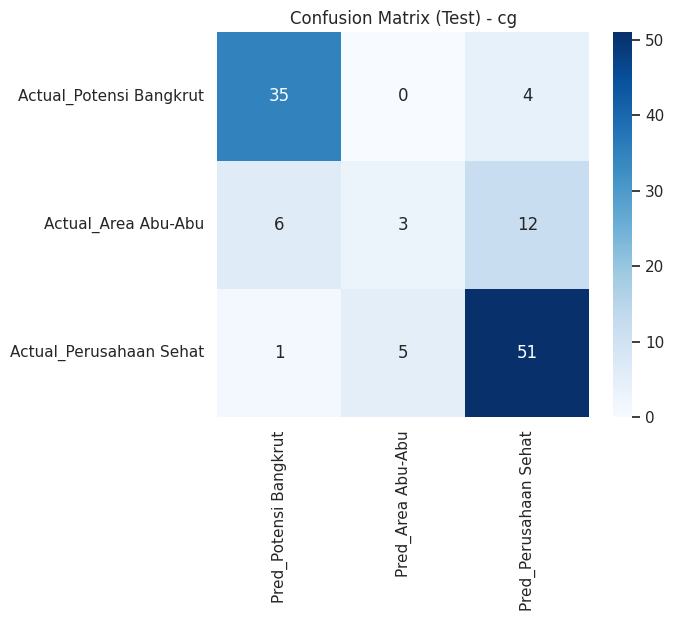

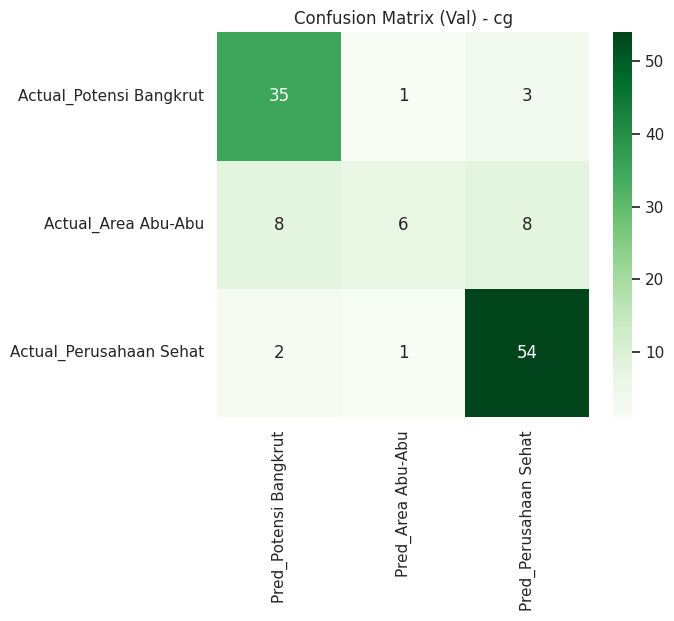


🚀 Melatih model MNLogit dengan metode: ncg


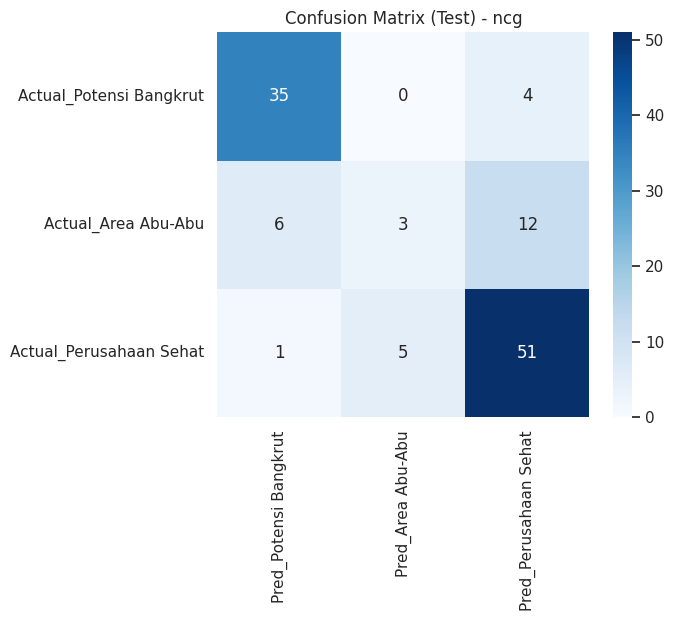

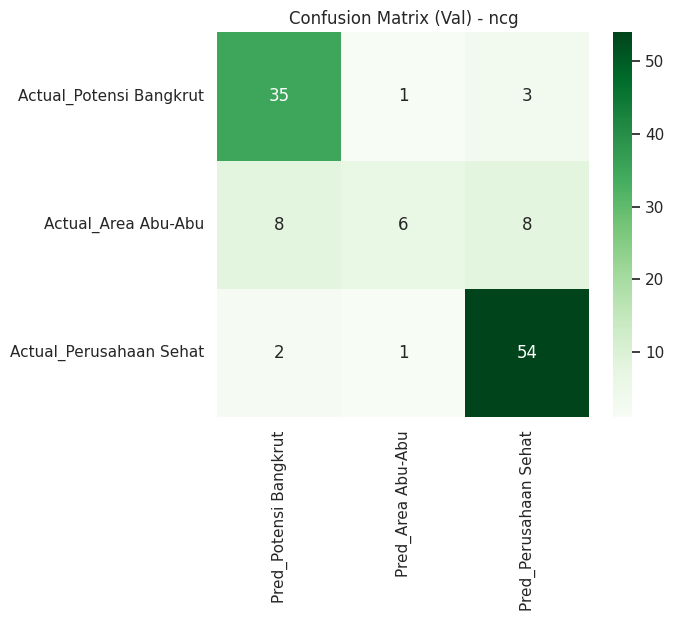


🚀 Melatih model MNLogit dengan metode: minimize


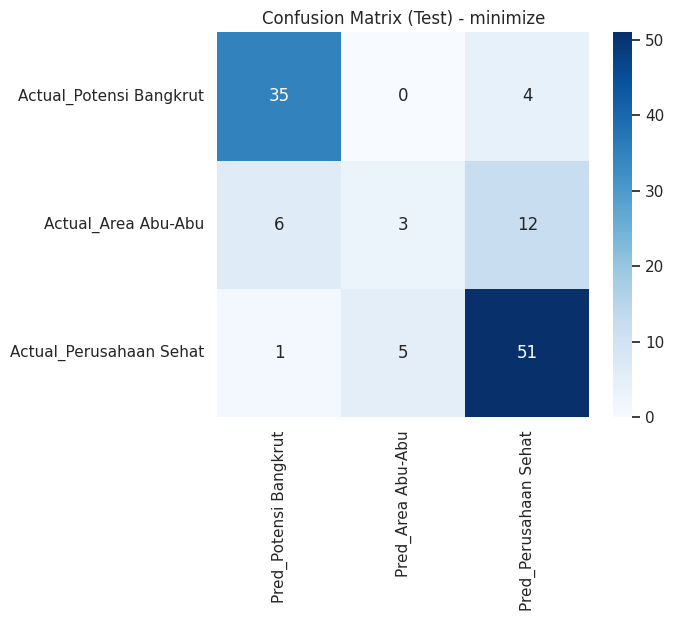

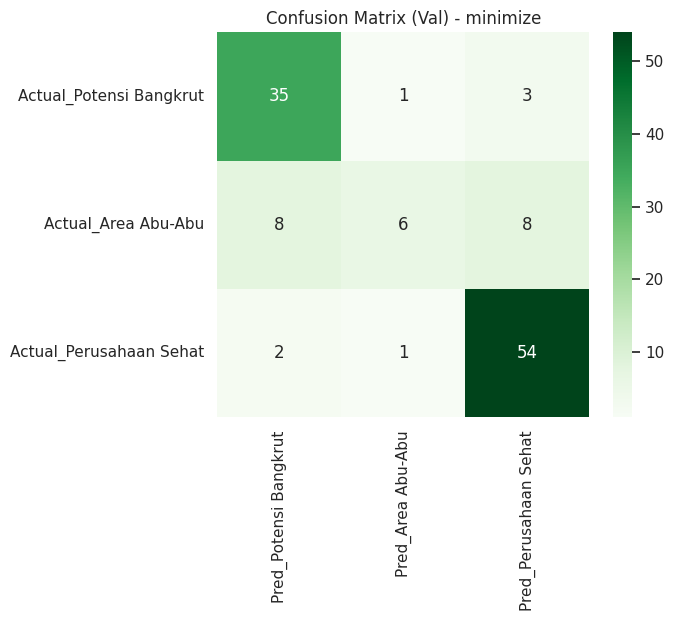



📋 Ringkasan Hasil Evaluasi Semua Metode:


,Method,Converged,Iterations,Pseudo_R2,AIC,BIC,LogLik,Acc_Test,Prec_Test,Recall_Test,F1_Test,Acc_Val,Prec_Val,Recall_Val,F1_Val
0,newton,True,8,0.444723,1111.914382,1218.429923,-533.957191,0.760684,0.656509,0.645010,0.631225,0.805085,0.786182,0.705844,0.706193
1,nm,True,7305,0.253490,1479.697050,1586.212591,-717.848525,0.726496,0.638346,0.638969,0.630611,0.720339,0.629295,0.629964,0.621217
2,bfgs,True,N/A,0.444723,1111.914395,1218.429935,-533.957197,0.760684,0.656509,0.645010,0.631225,0.805085,0.786182,0.705844,0.706193
3,lbfgs,True,26,0.444723,1111.914397,1218.429938,-533.957199,0.760684,0.656509,0.645010,0.631225,0.805085,0.786182,0.705844,0.706193
4,powell,True,8,0.444713,1111.934178,1218.449719,-533.967089,0.760684,0.656509,0.645010,0.631225,0.805085,0.786182,0.705844,0.706193
5,cg,True,N/A,0.444723,1111.914403,1218.429944,-533.957202,0.760684,0.656509,0.645010,0.631225,0.805085,0.786182,0.705844,0.706193
6,ncg,True,N/A,0.444723,1111.914382,1218.429923,-533.957191,0.760684,0.656509,0.645010,0.631225,0.805085,0.786182,0.705844,0.706193
7,minimize,True,74,0.444723,1111.914395,1218.429935,-533.957197,0.760684,0.656509,0.645010,0.631225,0.805085,0.786182,0.705844,0.706193


In [42]:
evaluate_mnlogit(
    X_train=X_train_scaled_yeo, y_train=y_train_prep,
    X_test=X_test_scaled_yeo, y_test=y_test_prep,
    X_val=X_val_scaled_yeo, y_val=y_val_prep,
)

1.   29/10/2025
     * Catatan
        - Menggunakan hasil prep untuk robust scaler dan min max scaler: Berdasarkan hasil yang didapatkan diatas menggunakan variabel X_train_prep hingga X_val_prep ternyata tidak ada metode yang bisa menghasilkan angka evaluasi (dengan catatan semua atribut dilakukan prerpo ya)
        - Menggunakan hasil preprocessing tradisional seperti Log, ln, exp, cube, sqrt namun untuk variabel yang digunakan ada beberapa saja: DER_ref_sqrt ROE_ref_log, Cash_Ratio_log, DAR_ref_cbrt, Kepemilikan_Mayoritas_ref_cbrt, NPM_ref_log, Pertumbuhan_Revenue_cbrt, ROA_cbrt, Total_Asset_cbrt, Current_Ratio_log
        - Hasil dari model yang menggunakan data 10 atribut tersebut sudah ada beberapa yang sudah muncul dan sebagian besar hasilnya masih kurang memuaskan untuk hanya menggunkan 10 atribut tersebut,  **jadi next stepnya dilakukan penggabungan dengan data sebelumnya agar genap menjadi 18 atribut sesuai format aslinya.**

      * Hasil Evaluasi Sementara
        - Hasil Evaluasi sementara untuk prep 10 atribut dengan akurasi terbaik prep **klasik** adalah sebagai berikut: **metode = nm, apakah_konvergen =	True,	iterasi =7306, Pseudo R2 =	0.343198, AIC = 1307.169644, BIC =	1413.685184, LogLikelihood =	-631.584822, acc_test =	0.709402, 	Prec_Test = 0.522466, Recall_Test=	0.558255, F1_Test =	0.522177, Acc_Val = 0.644068, Prec_Val = 0.485795,	Recall_Val = 0.495726, F1_Val =	0.456016.** Namun masih banyak metode yang tidak menampilkan hasil evaluasinya.

2.   30/10/2025
      * Catatan
        - Dilakukan percobaan dengan konsep yang sama namun dengan metode yang berbeda metode untuk preprocessing terhadap 10 atribut yang sama ada beberapa seperti:
          - Metode Robust Scaler
          - MinMax Scaler
          - PowerTransformer(Yeo-Jhonson)
        - Jika dari hasil Evaluasi metode-metode tersebut, mungkin bisa dilanjutkan untuk penggabungan hasil preprocessing tersebut dengan format data aslinya.

      * Hasil Evaluasi
        - Metode Robust Scaler: Pada metode tersebut terdapat 2 method dengan evaluasi yang sama yaitu metode Newton dan ncg dengan hasil sebagai berikut: **Method = newton ,	Converged	Iterations = 11 ,	Pseudo_R2 = 0.340075 ,	AIC = 1313.175780 ,	BIC = 1419.691321 , LogLik = -634.587890, Acc_Test = 0.709402	, Prec_Test = 0.477923 , Recall_Test = 0.574449 ,	F1_Test = 0.521691 ,	Acc_Val = 0.779661 ,	Prec_Val = 0.848227 ,	Recall_Val = 0.641782,	F1_Val = 0.594267** dan untuk ncg juga outputnya sama persis dengan si newton
        - Metode MinMax Scaler: jika dibandingkan dengan hasil robust scaler, memang pada metode ini beberapa method menghasilkan evaluasi yang cukup terdapat peningkatan dari metode sebelumnya, namun peningkatan tersebut tidak terlalu signifikan.
        - Metode PowerTransformer(Yeo-Jhonson): secara seklas saja untuk hasil evaluasi dari model yang menggunakan inputan hasil preprocessing menggunakan metode Yeo-Jhonson, terjadi peningkatan yang cukup signifikan berdasarkan hampir dari keseluruhan aspek mulai dari R2 hingga F1-score validationnya. namun untuk bagian precision_val itu terjadi sedikit penurunan tapi untuk bagian recallnya yeo-jhonson terjadi kenaikan yang menandakan model mulai belajar dengan cukup baik terhadap data inputan.

***Berdasarkan hasil hasil diatas, untuk melakukan pemodelan dengan data secara utuh maka akan dilakukan proses pre-processing terlebih dahulu terhadap 10 variabel tersebut, yang diharapkan hasilnya model bisa belajar dan bisa dievaluasi secara modelnya dan hasil klasifiksinya.***

## Pemodelan Menggunakan data secara utuh

menggunakan keseluruhan data namun hanya dilakukan preprocessing pada 10 atribut saja namun menggunakan 18 variabel data tersebut

### Menggunakan Metode Robust Scaler

In [43]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# === 1. Tentukan kolom yang ingin di-scale ===
robust_cols = [
    'Current_Ratio', 'Cash_Ratio', 'ROA', 'Pertumbuhan_Revenue',
    'Total_Asset', 'DAR', 'DER', 'NPM', 'ROE', 'Kepemilikan_Mayoritas'
]

# === 2. Inisialisasi scaler ===
robust_scaler = RobustScaler()

# === 3. Fit dan transform pada data TRAIN ===
X_train_robust_only = robust_scaler.fit_transform(X_train_prep[robust_cols])
X_test_robust_only = robust_scaler.transform(X_test_prep[robust_cols])
X_val_robust_only = robust_scaler.transform(X_val_prep[robust_cols])

# === 4. Konversi hasil scaling ke DataFrame ===
X_train_robust_only = pd.DataFrame(X_train_robust_only, columns=robust_cols, index=X_train_prep.index)
X_test_robust_only = pd.DataFrame(X_test_robust_only, columns=robust_cols, index=X_test_prep.index)
X_val_robust_only = pd.DataFrame(X_val_robust_only, columns=robust_cols, index=X_val_prep.index)

# === 5. Gabungkan hasil scaling dengan kolom lain (replace kolom lama) ===
X_train_scaled_robust = X_train_prep.copy()
X_test_scaled_robust = X_test_prep.copy()
X_val_scaled_robust = X_val_prep.copy()

X_train_scaled_robust[robust_cols] = X_train_robust_only
X_test_scaled_robust[robust_cols] = X_test_robust_only
X_val_scaled_robust[robust_cols] = X_val_robust_only

# === 6. Info hasil ===
print("✅ Scaling RobustScaler selesai dan data sudah digabung kembali!")
print(f"- {len(robust_cols)} kolom di-scale")
print(f"- Total kolom akhir: {X_train_scaled_robust.shape[1]}")


✅ Scaling RobustScaler selesai dan data sudah digabung kembali!
- 10 kolom di-scale
- Total kolom akhir: 18


🚀 Melatih model MNLogit dengan metode: newton
❌ Gagal dengan metode: newton
Error: Input y_pred contains NaN.

🚀 Melatih model MNLogit dengan metode: nm


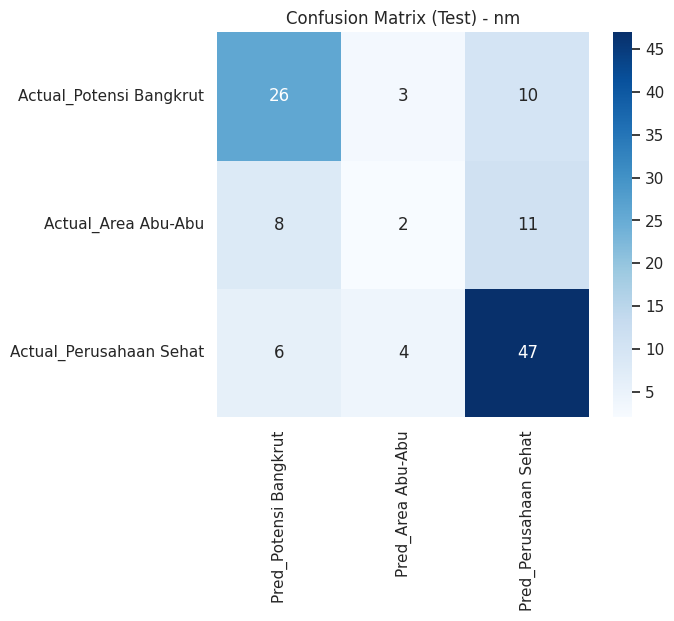

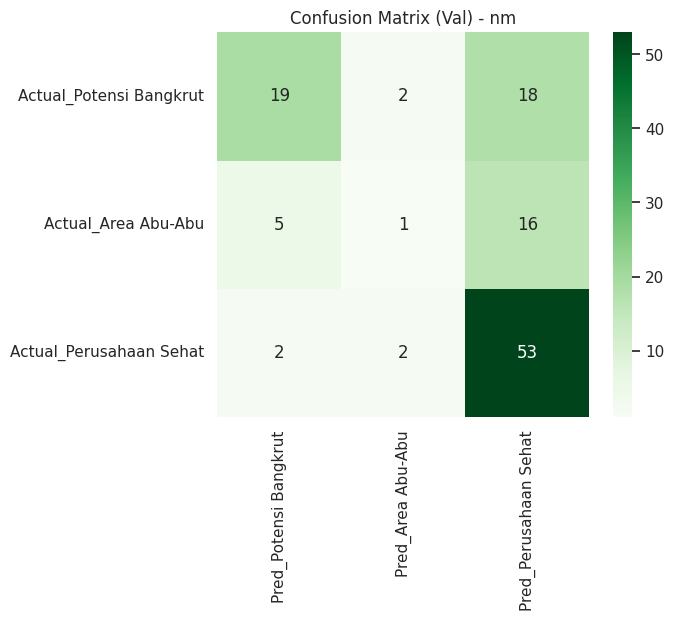


🚀 Melatih model MNLogit dengan metode: bfgs


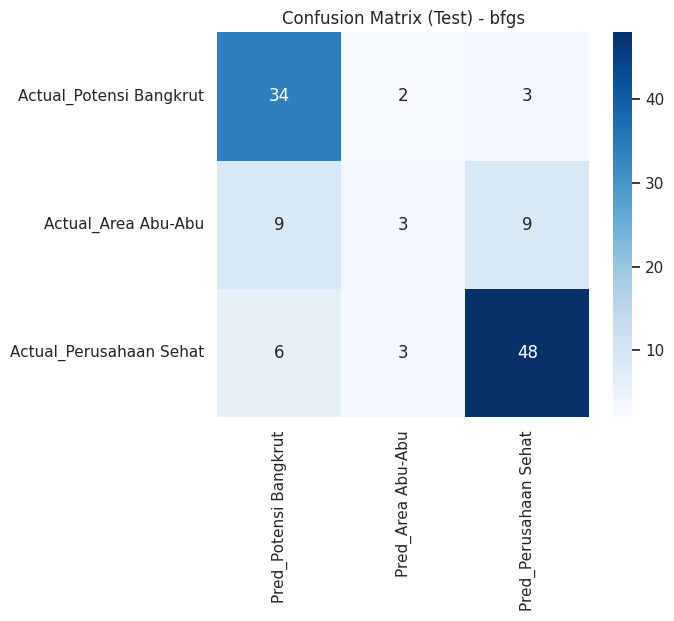

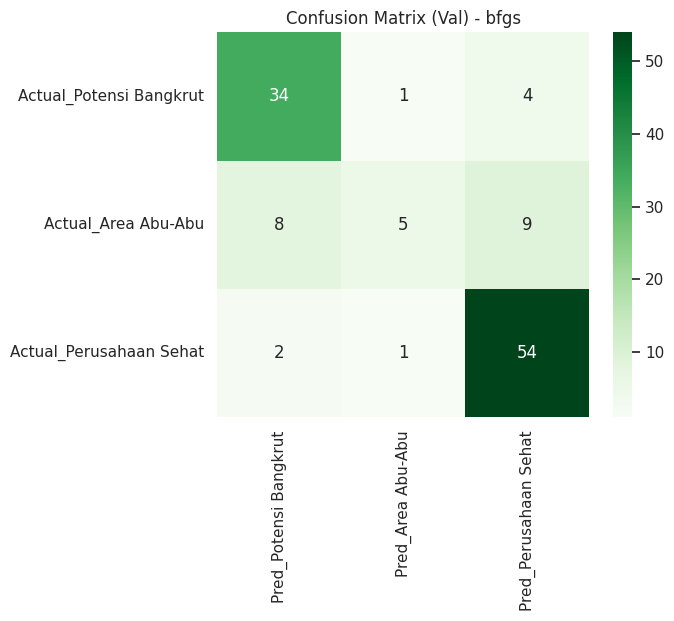


🚀 Melatih model MNLogit dengan metode: lbfgs


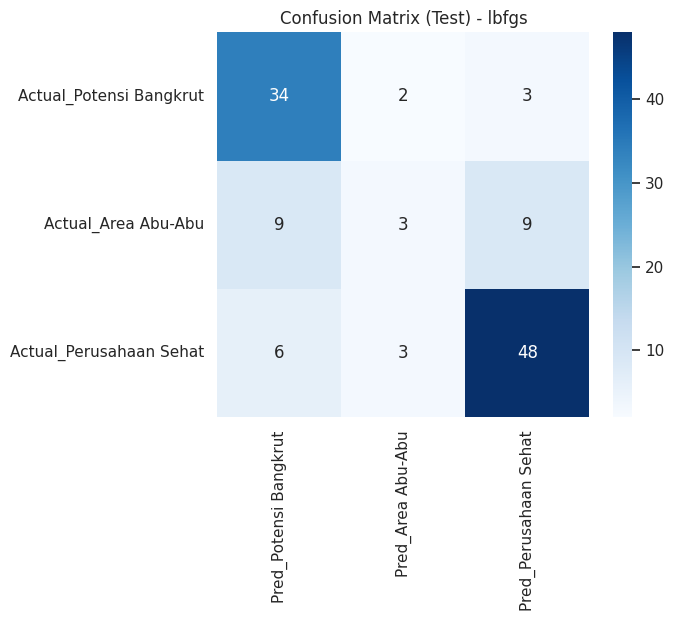

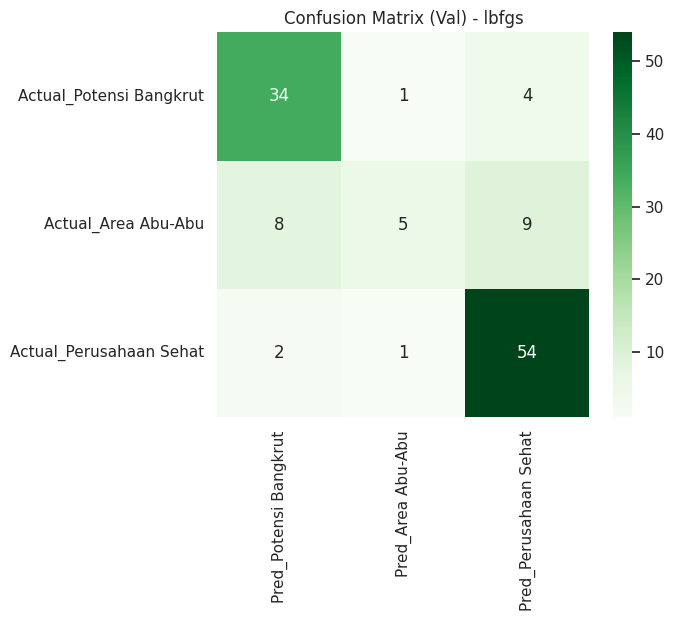


🚀 Melatih model MNLogit dengan metode: powell
❌ Gagal dengan metode: powell
Error: Input y_pred contains NaN.

🚀 Melatih model MNLogit dengan metode: cg


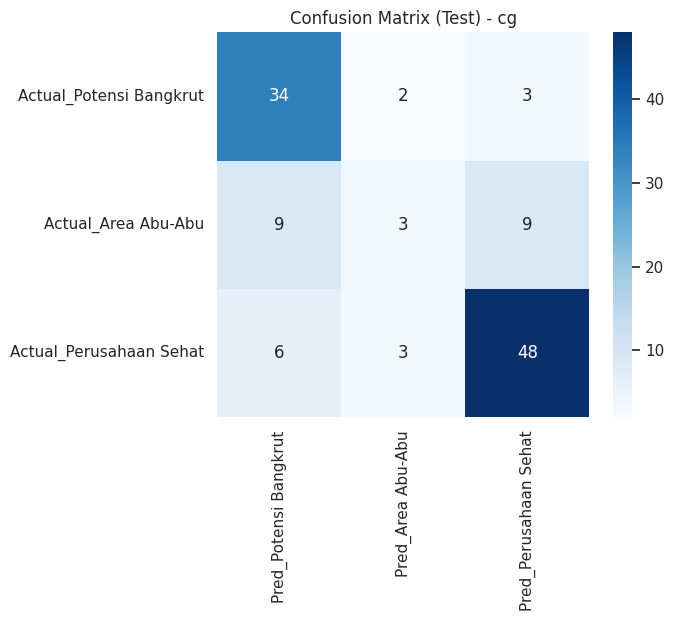

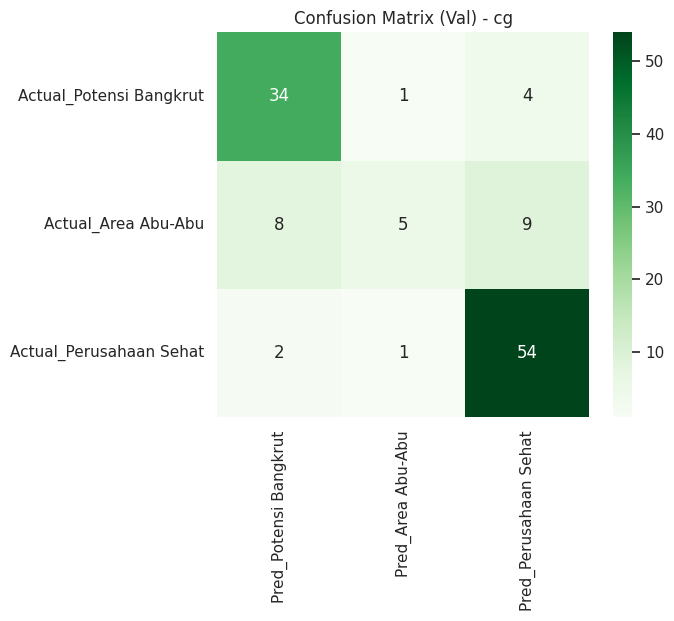


🚀 Melatih model MNLogit dengan metode: ncg


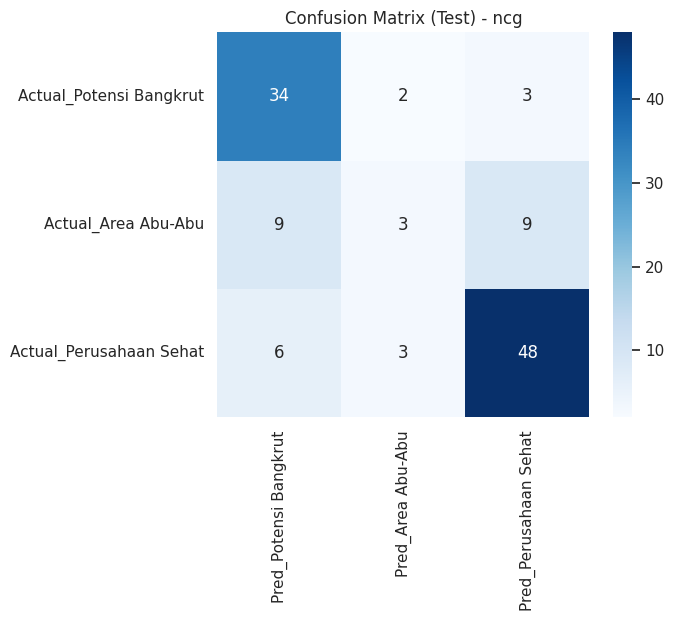

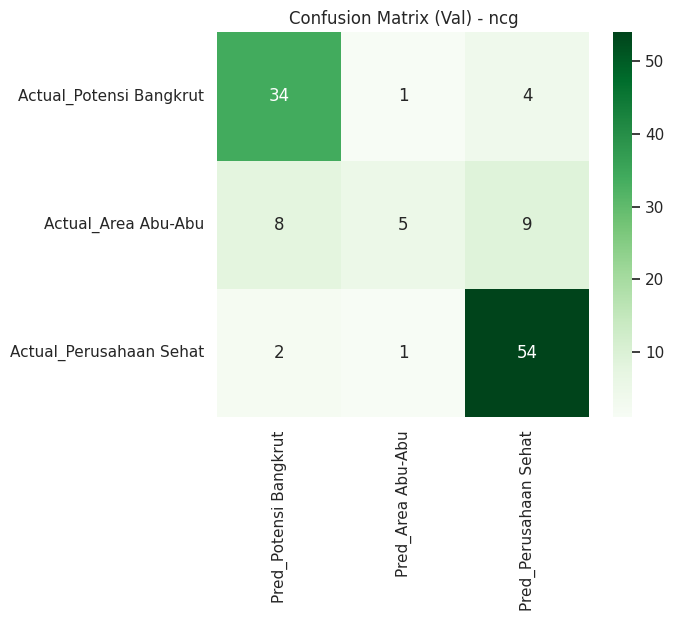


🚀 Melatih model MNLogit dengan metode: minimize


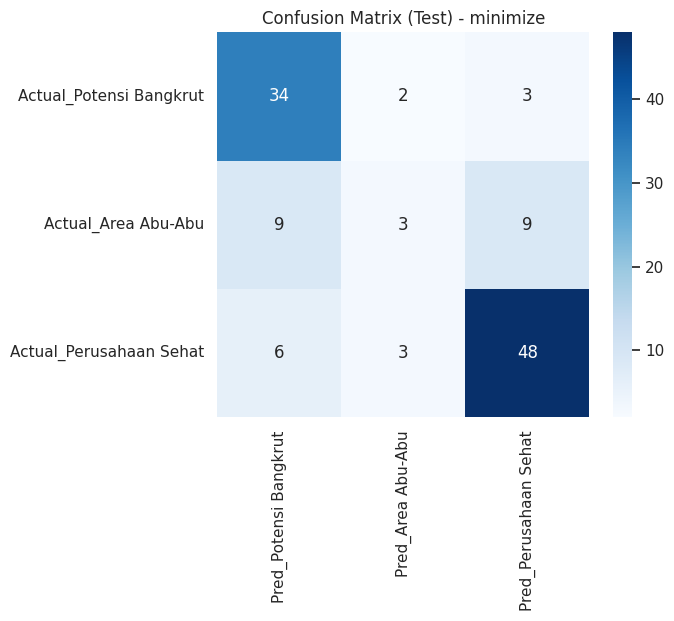

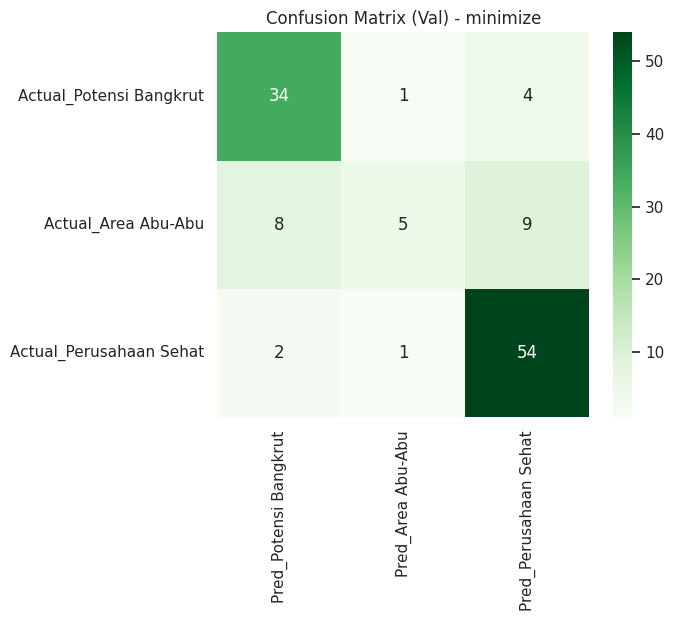



📋 Ringkasan Hasil Evaluasi Semua Metode:


,Method,Converged,Iterations,Pseudo_R2,AIC,BIC,LogLik,Acc_Test,Prec_Test,Recall_Test,F1_Test,Acc_Val,Prec_Val,Recall_Val,F1_Val
0,newton,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,nm,True,15092,0.150882,1701.034182,1865.649108,-816.517091,0.641026,0.521133,0.528822,0.514520,0.618644,0.513322,0.487486,0.464934
2,bfgs,True,N/A,0.364750,1289.719163,1454.334090,-610.859582,0.726496,0.622959,0.618919,0.600046,0.788136,0.764328,0.682145,0.678357
3,lbfgs,True,1191,0.364743,1289.732645,1454.347571,-610.866323,0.726496,0.622959,0.618919,0.600046,0.788136,0.764328,0.682145,0.678357
4,powell,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cg,True,N/A,0.364750,1289.720005,1454.334931,-610.860003,0.726496,0.622959,0.618919,0.600046,0.788136,0.764328,0.682145,0.678357
6,ncg,True,N/A,0.364750,1289.719163,1454.334089,-610.859582,0.726496,0.622959,0.618919,0.600046,0.788136,0.764328,0.682145,0.678357
7,minimize,True,140,0.364750,1289.719163,1454.334090,-610.859582,0.726496,0.622959,0.618919,0.600046,0.788136,0.764328,0.682145,0.678357


In [44]:
evaluate_mnlogit(
    X_train=X_train_scaled_robust, y_train=y_train_prep,
    X_test=X_test_scaled_robust, y_test=y_test_prep,
    X_val=X_val_scaled_robust, y_val=y_val_prep,
)

### Menggunakan Metode MinMax Scaler

In [45]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# === 1. Tentukan kolom yang ingin di-scale ===
minmax_cols = [
    'Current_Ratio', 'Cash_Ratio', 'ROA', 'Pertumbuhan_Revenue',
    'Total_Asset', 'DAR', 'DER', 'NPM', 'ROE', 'Kepemilikan_Mayoritas'
]

# === 2. Inisialisasi scaler ===
minmax = MinMaxScaler()

# === 3. Fit dan transform pada data TRAIN ===
X_train_minmax_only = minmax.fit_transform(X_train_prep[minmax_cols])
X_test_minmax_only = minmax.transform(X_test_prep[minmax_cols])
X_val_minmax_only = minmax.transform(X_val_prep[minmax_cols])

# === 4. Konversi hasil scaling menjadi DataFrame ===
X_train_minmax_only = pd.DataFrame(X_train_minmax_only, columns=minmax_cols, index=X_train_prep.index)
X_test_minmax_only = pd.DataFrame(X_test_minmax_only, columns=minmax_cols, index=X_test_prep.index)
X_val_minmax_only = pd.DataFrame(X_val_minmax_only, columns=minmax_cols, index=X_val_prep.index)

# === 5. Gabungkan kembali dengan kolom lain di dataset asli ===
X_train_scaled_minmax = X_train_prep.copy()
X_test_scaled_minmax = X_test_prep.copy()
X_val_scaled_minmax = X_val_prep.copy()

X_train_scaled_minmax[minmax_cols] = X_train_minmax_only
X_test_scaled_minmax[minmax_cols] = X_test_minmax_only
X_val_scaled_minmax[minmax_cols] = X_val_minmax_only

# === 6. Info hasil ===
print("✅ Scaling MinMax selesai dan data sudah digabung kembali!")
print(f"- {len(minmax_cols)} kolom di-scale")
print(f"- Total kolom akhir: {X_train_scaled_minmax.shape[1]}")


✅ Scaling MinMax selesai dan data sudah digabung kembali!
- 10 kolom di-scale
- Total kolom akhir: 18


array([[<Axes: title={'center': 'Current_Ratio'}>,
        <Axes: title={'center': 'Cash_Ratio'}>,
        <Axes: title={'center': 'DAR'}>, <Axes: title={'center': 'DER'}>],
       [<Axes: title={'center': 'NPM'}>, <Axes: title={'center': 'ROA'}>,
        <Axes: title={'center': 'ROE'}>,
        <Axes: title={'center': 'Kepemilikan_Mayoritas'}>],
       [<Axes: title={'center': 'Komisaris_Independen'}>,
        <Axes: title={'center': 'Insider_Ownership'}>,
        <Axes: title={'center': 'BoC_Size'}>,
        <Axes: title={'center': 'BoC_Education'}>],
       [<Axes: title={'center': 'TMT_Size_DK'}>,
        <Axes: title={'center': 'TMT_Size_DD'}>,
        <Axes: title={'center': 'TMT_Education_DK'}>,
        <Axes: title={'center': 'TMT_Education_DD'}>],
       [<Axes: title={'center': 'Total_Asset'}>,
        <Axes: title={'center': 'Pertumbuhan_Revenue'}>, <Axes: >,
        <Axes: >]], dtype=object)

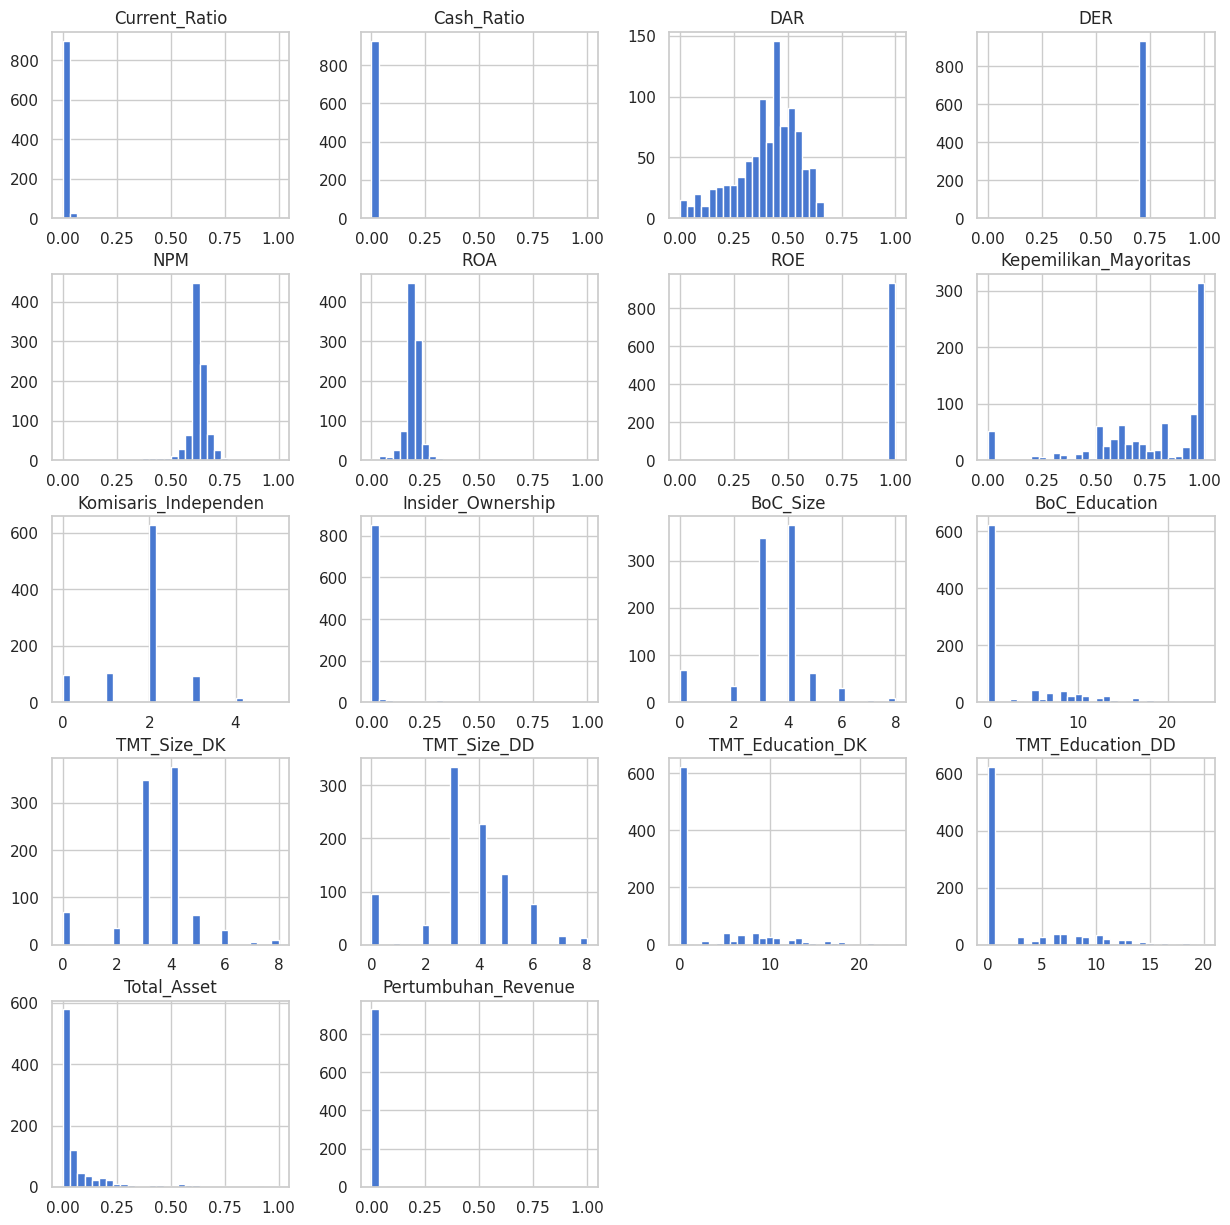

In [46]:
X_train_scaled_minmax.hist(figsize=(15, 15), bins=30)

🚀 Melatih model MNLogit dengan metode: newton
❌ Gagal dengan metode: newton
Error: Input y_pred contains NaN.

🚀 Melatih model MNLogit dengan metode: nm


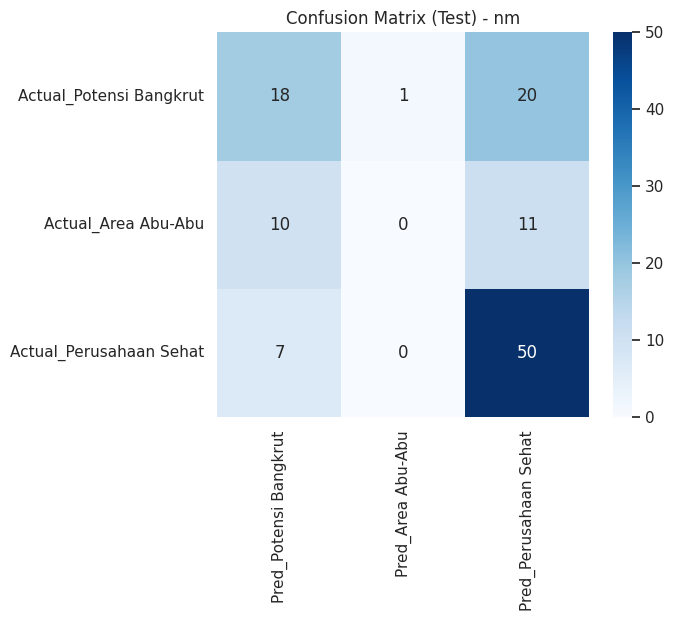

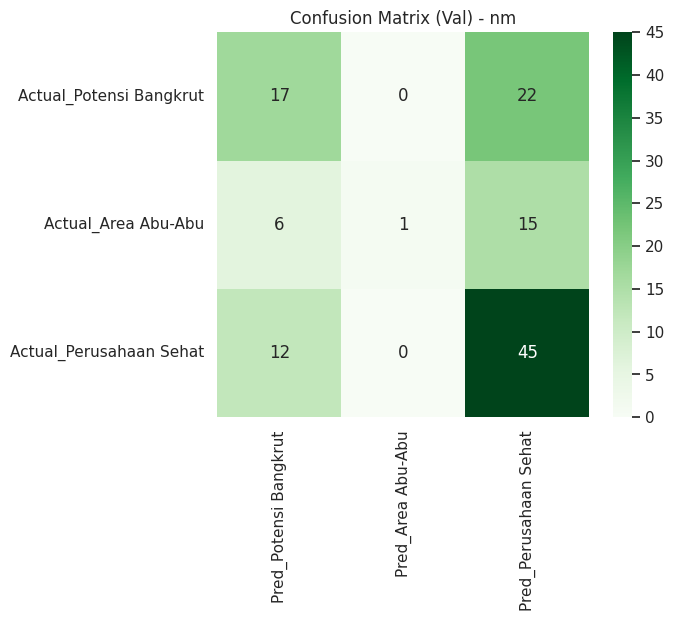


🚀 Melatih model MNLogit dengan metode: bfgs


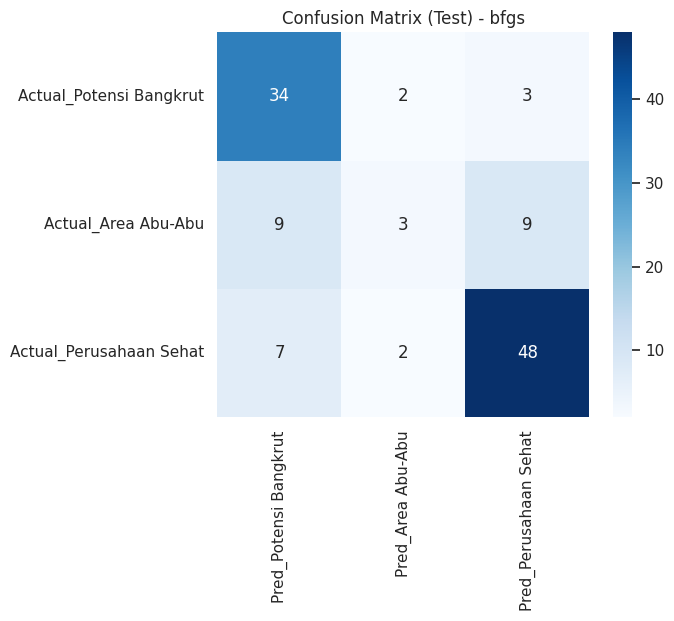

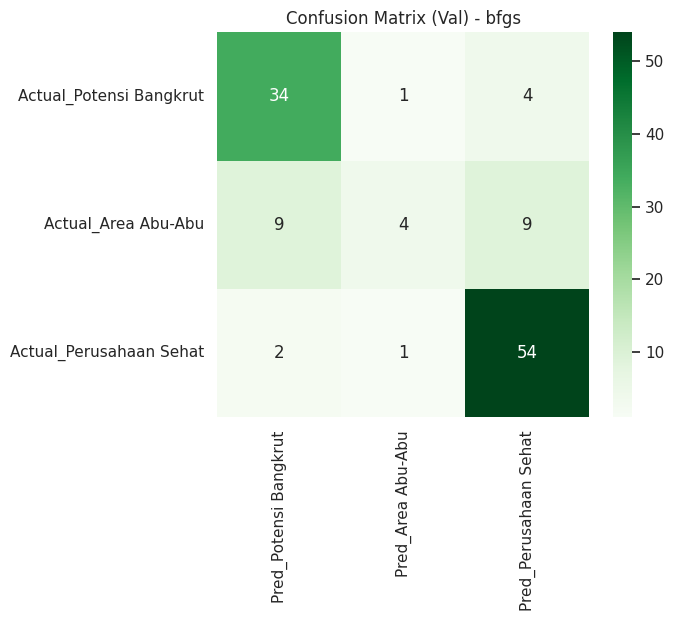


🚀 Melatih model MNLogit dengan metode: lbfgs


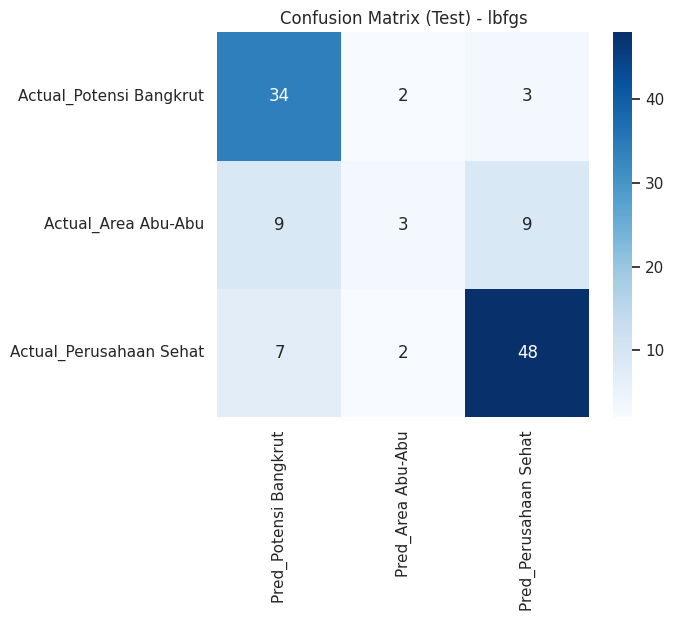

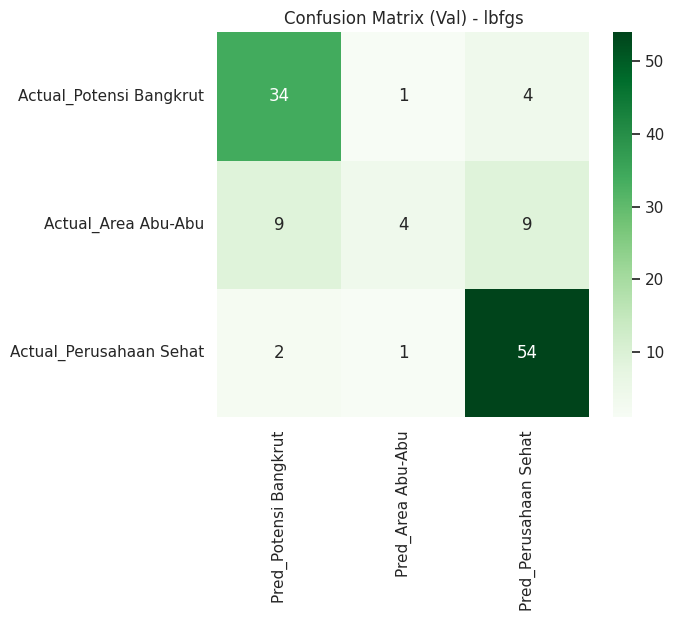


🚀 Melatih model MNLogit dengan metode: powell


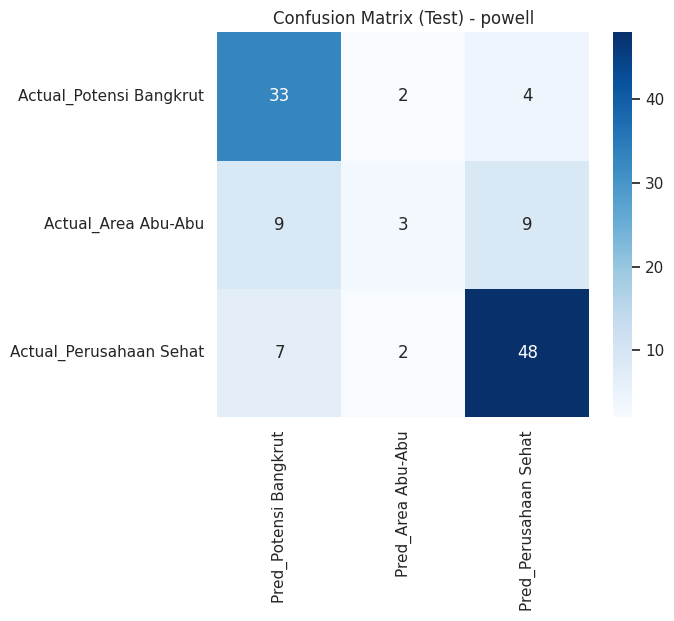

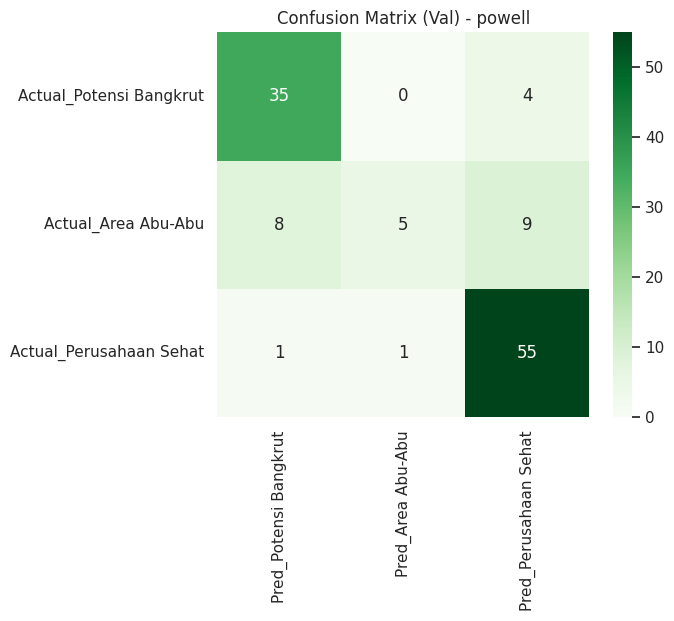


🚀 Melatih model MNLogit dengan metode: cg


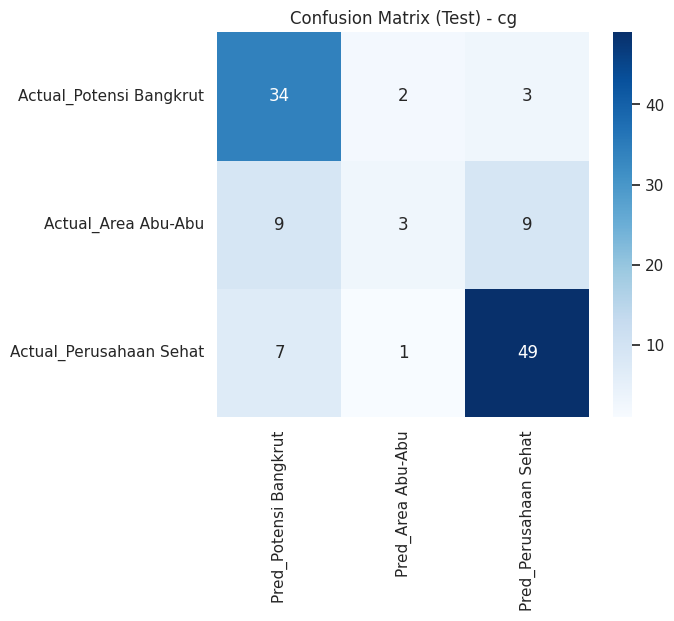

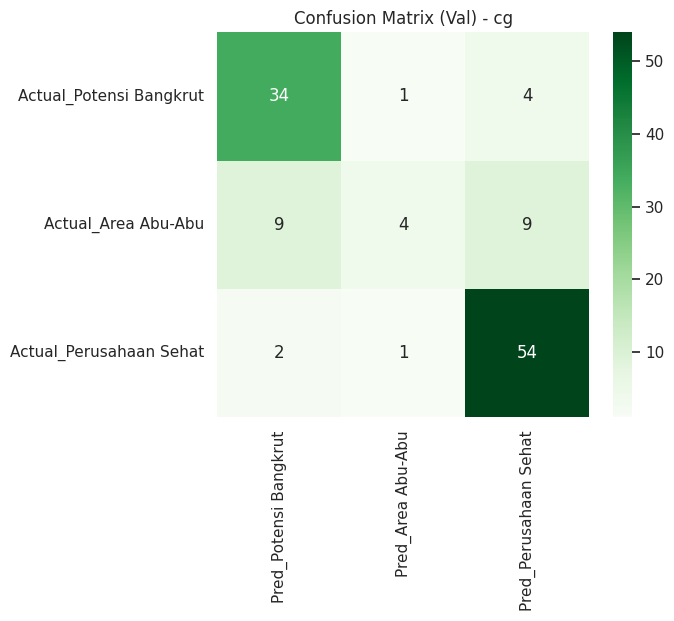


🚀 Melatih model MNLogit dengan metode: ncg


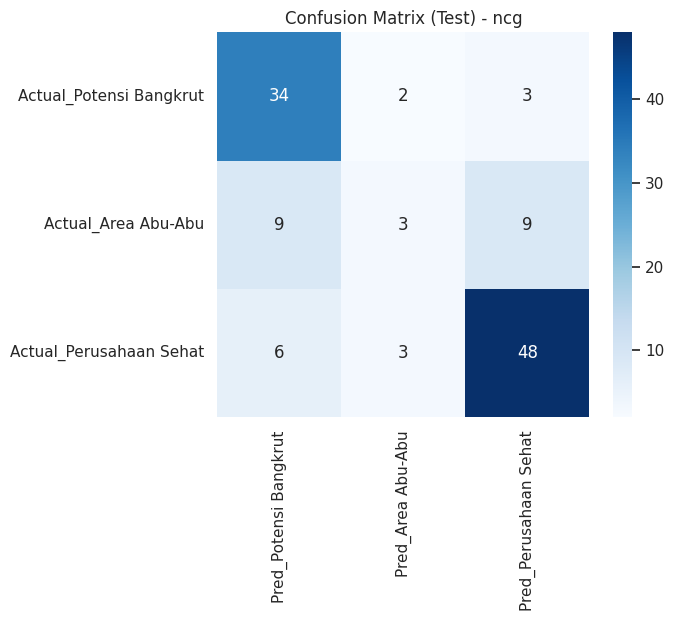

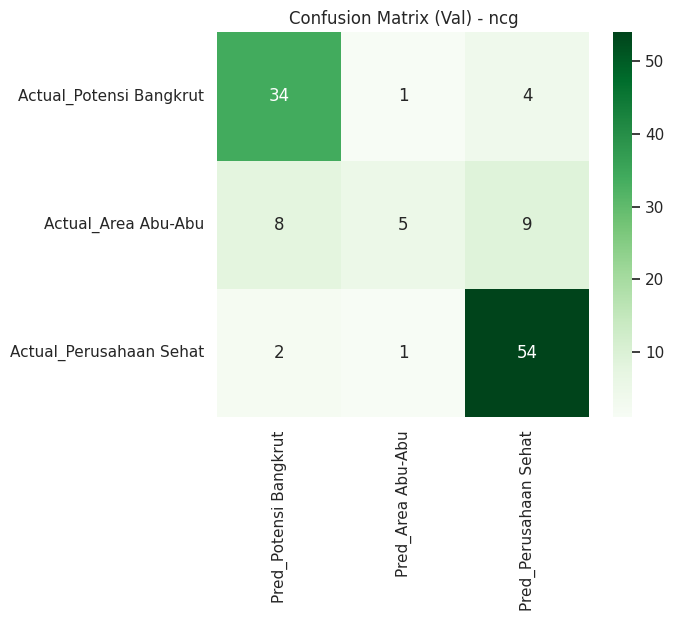


🚀 Melatih model MNLogit dengan metode: minimize


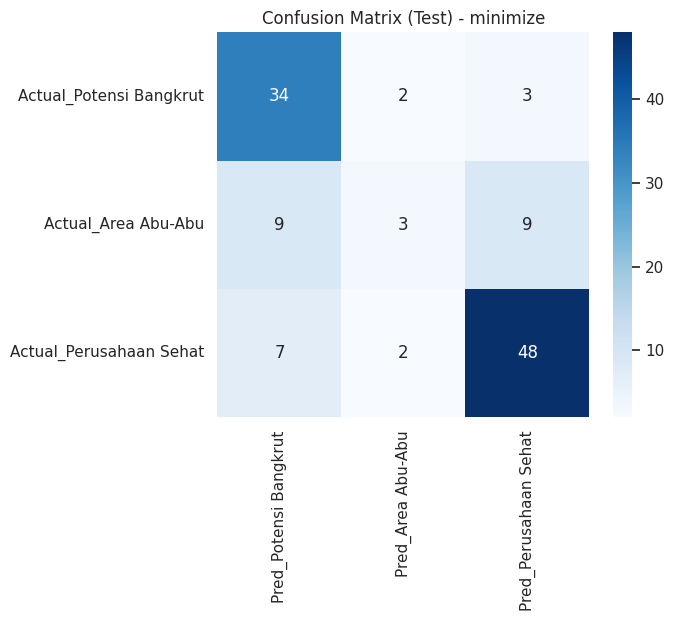

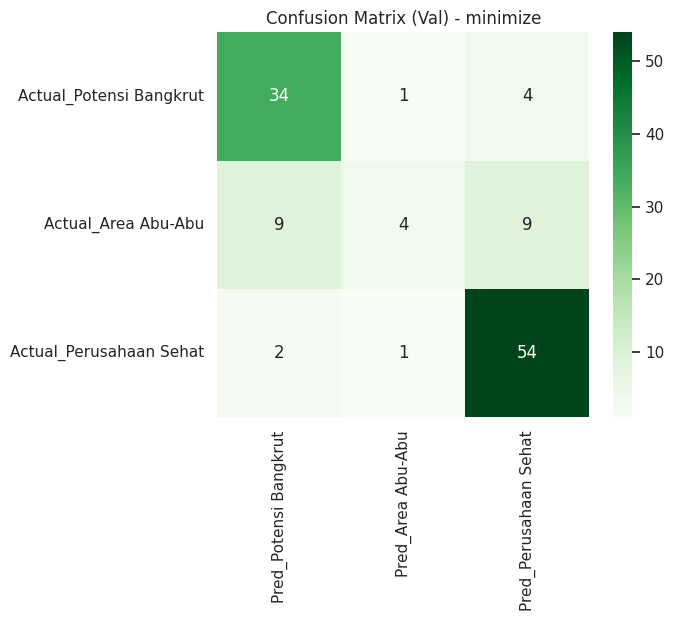



📋 Ringkasan Hasil Evaluasi Semua Metode:


,Method,Converged,Iterations,Pseudo_R2,AIC,BIC,LogLik,Acc_Test,Prec_Test,Recall_Test,F1_Test,Acc_Val,Prec_Val,Recall_Val,F1_Val
0,newton,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,nm,True,25205,0.058735,1878.250967,2042.865893,-905.125483,0.581197,0.377190,0.446244,0.403708,0.533898,0.678165,0.423609,0.397966
2,bfgs,True,N/A,0.362397,1294.245854,1458.860781,-613.122927,0.726496,0.636190,0.618919,0.599614,0.779661,0.742731,0.666994,0.655402
3,lbfgs,True,9675,0.362832,1293.409040,1458.023966,-612.704520,0.726496,0.636190,0.618919,0.599614,0.779661,0.742731,0.666994,0.655402
4,powell,True,28,0.356648,1305.302279,1469.917205,-618.651139,0.717949,0.629642,0.610372,0.592615,0.805085,0.812537,0.696540,0.693505
5,cg,True,N/A,0.362552,1293.946379,1458.561305,-612.973189,0.735043,0.661093,0.624767,0.605592,0.779661,0.742731,0.666994,0.655402
6,ncg,True,N/A,0.364749,1289.720976,1454.335902,-610.860488,0.726496,0.622959,0.618919,0.600046,0.788136,0.764328,0.682145,0.678357
7,minimize,True,345,0.362397,1294.245854,1458.860781,-613.122927,0.726496,0.636190,0.618919,0.599614,0.779661,0.742731,0.666994,0.655402


In [47]:
evaluate_mnlogit(
    X_train=X_train_scaled_minmax, y_train=y_train_prep,
    X_test=X_test_scaled_minmax, y_test=y_test_prep,
    X_val=X_val_scaled_minmax, y_val=y_val_prep,
)

### Metode PowerTransformer(Yeo-Jhonson)

In [48]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# === 1. Tentukan kolom yang ingin di-transform ===
yeo_cols = [
    'Current_Ratio', 'Cash_Ratio', 'ROA', 'Pertumbuhan_Revenue',
    'Total_Asset', 'DAR', 'DER', 'NPM', 'ROE', 'Kepemilikan_Mayoritas'
]

# === 2. Inisialisasi transformer (Yeo-Johnson) ===
yeo_transformer = PowerTransformer(method='yeo-johnson', standardize=True)

# === 3. Fit dan transform pada data TRAIN ===
X_train_yeo_only = yeo_transformer.fit_transform(X_train_prep[yeo_cols])
X_test_yeo_only = yeo_transformer.transform(X_test_prep[yeo_cols])
X_val_yeo_only = yeo_transformer.transform(X_val_prep[yeo_cols])

# === 4. Konversi hasil transform ke DataFrame ===
X_train_yeo_only = pd.DataFrame(X_train_yeo_only, columns=yeo_cols, index=X_train_prep.index)
X_test_yeo_only = pd.DataFrame(X_test_yeo_only, columns=yeo_cols, index=X_test_prep.index)
X_val_yeo_only = pd.DataFrame(X_val_yeo_only, columns=yeo_cols, index=X_val_prep.index)

# === 5. Gabungkan hasil transform dengan kolom lain (replace kolom lama) ===
X_train_scaled_yeo = X_train_prep.copy()
X_test_scaled_yeo = X_test_prep.copy()
X_val_scaled_yeo = X_val_prep.copy()

X_train_scaled_yeo[yeo_cols] = X_train_yeo_only
X_test_scaled_yeo[yeo_cols] = X_test_yeo_only
X_val_scaled_yeo[yeo_cols] = X_val_yeo_only

# === 6. Info hasil ===
print("✅ Transformasi Yeo-Johnson selesai dan data sudah digabung kembali!")
print(f"- {len(yeo_cols)} kolom di-transform")
print(f"- Total kolom akhir: {X_train_scaled_yeo.shape[1]}")

✅ Transformasi Yeo-Johnson selesai dan data sudah digabung kembali!
- 10 kolom di-transform
- Total kolom akhir: 18


🚀 Melatih model MNLogit dengan metode: newton
❌ Gagal dengan metode: newton
Error: Singular matrix

🚀 Melatih model MNLogit dengan metode: nm


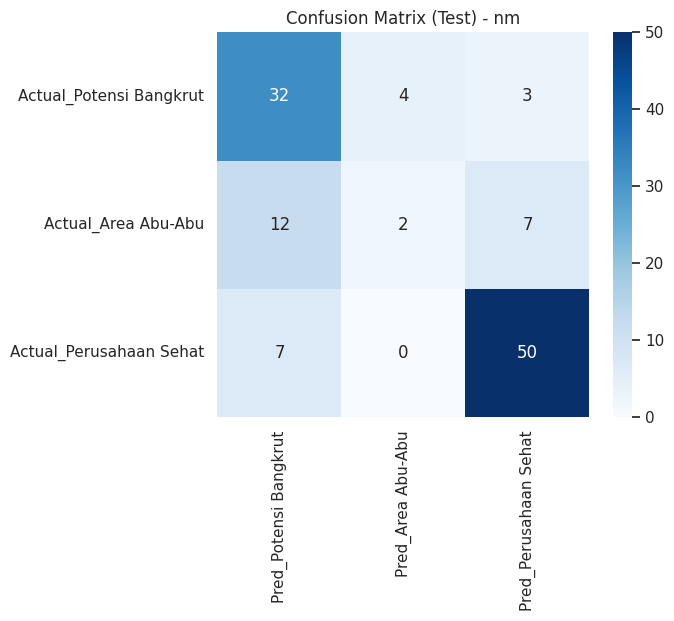

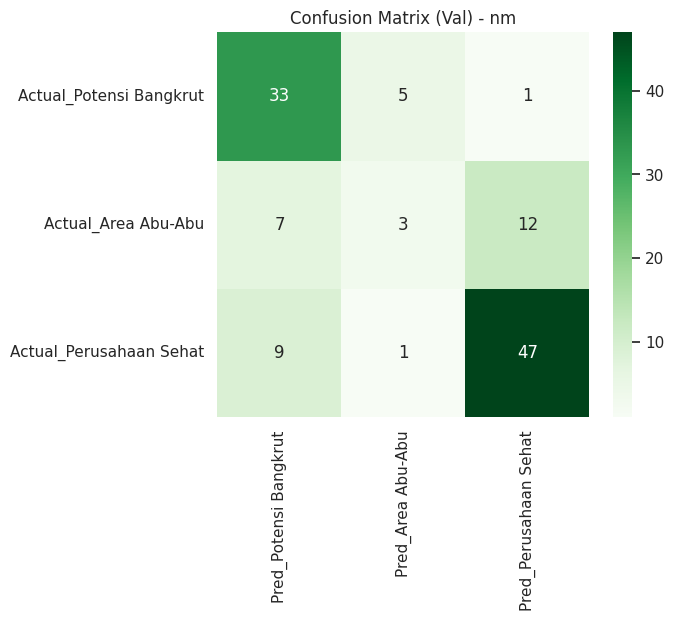


🚀 Melatih model MNLogit dengan metode: bfgs


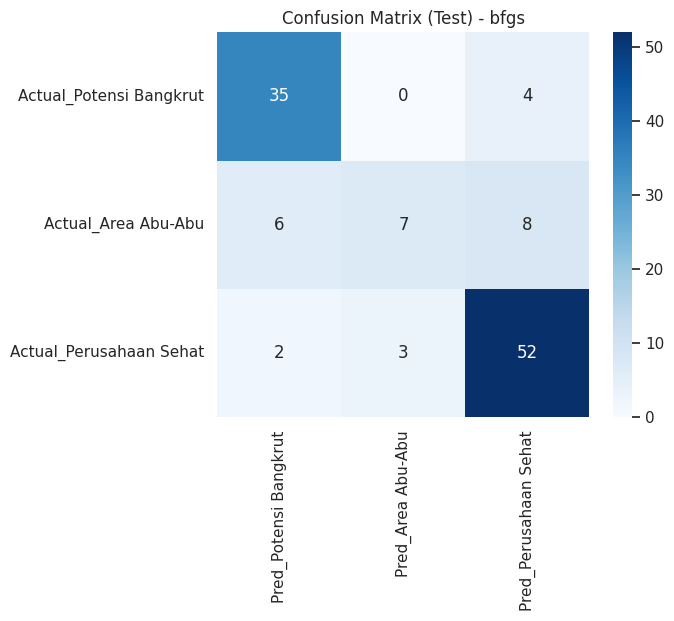

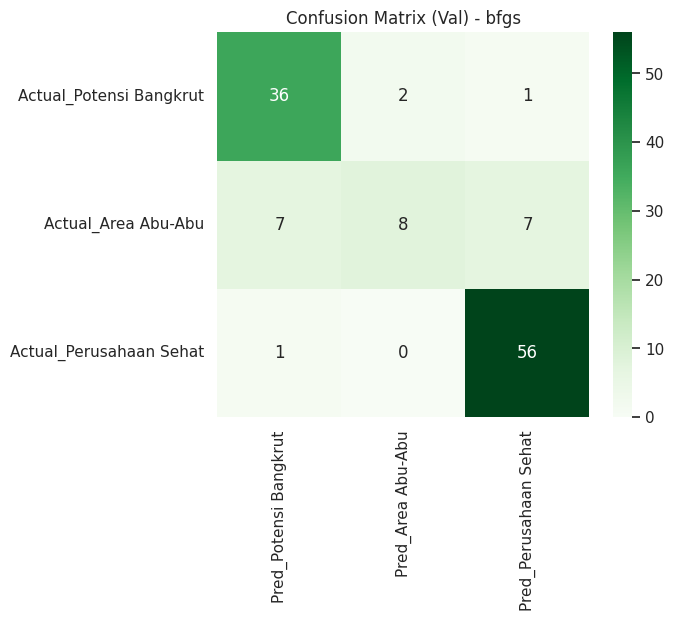


🚀 Melatih model MNLogit dengan metode: lbfgs


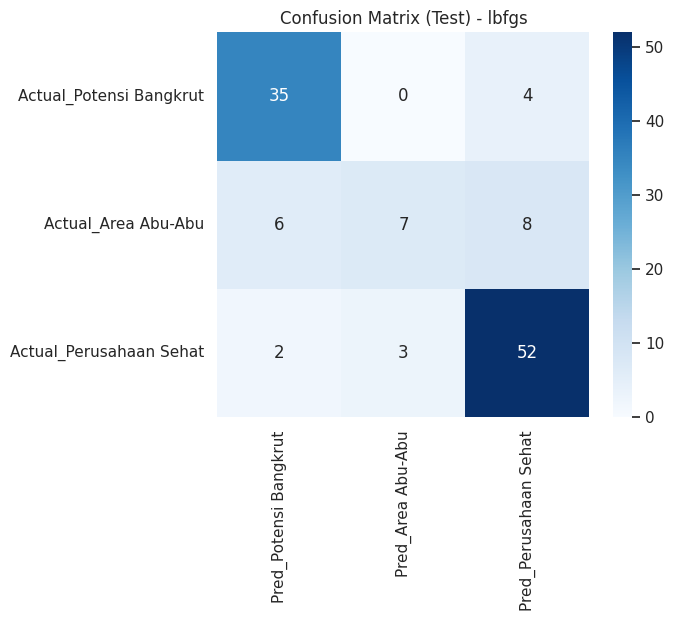

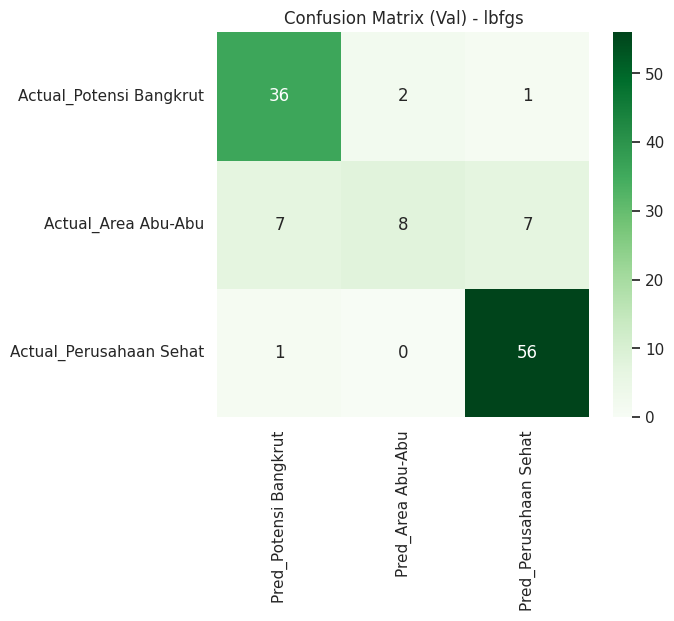


🚀 Melatih model MNLogit dengan metode: powell


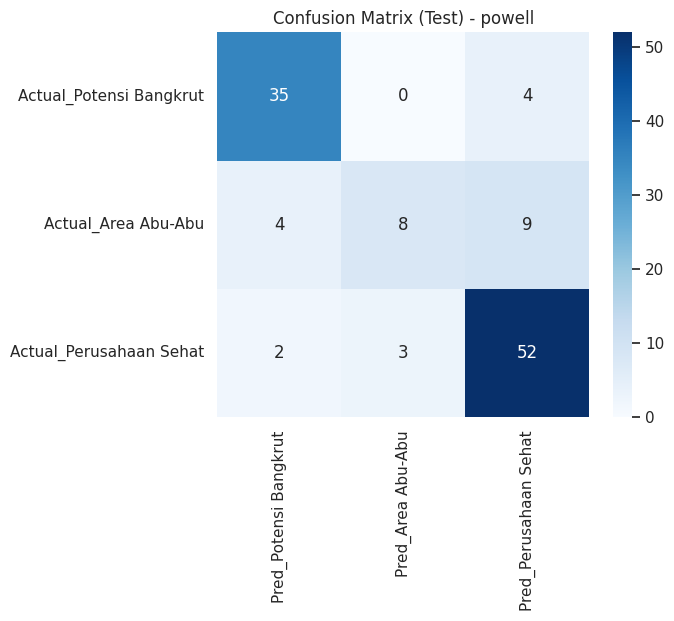

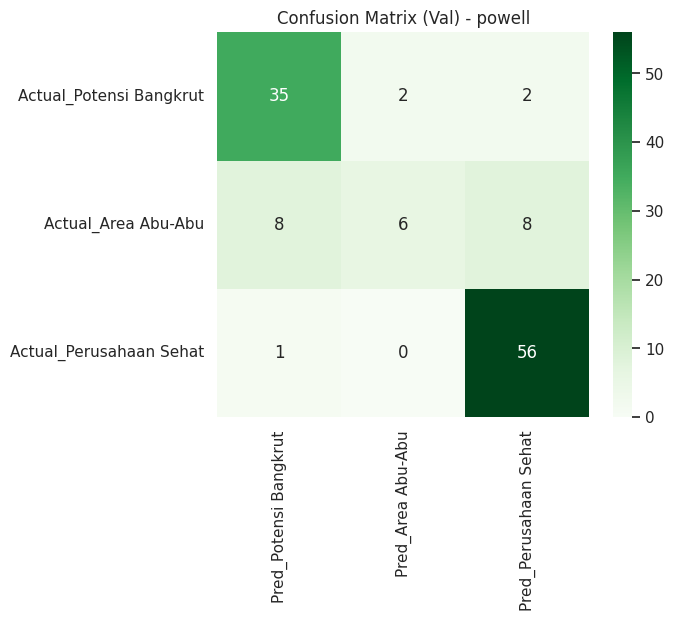


🚀 Melatih model MNLogit dengan metode: cg


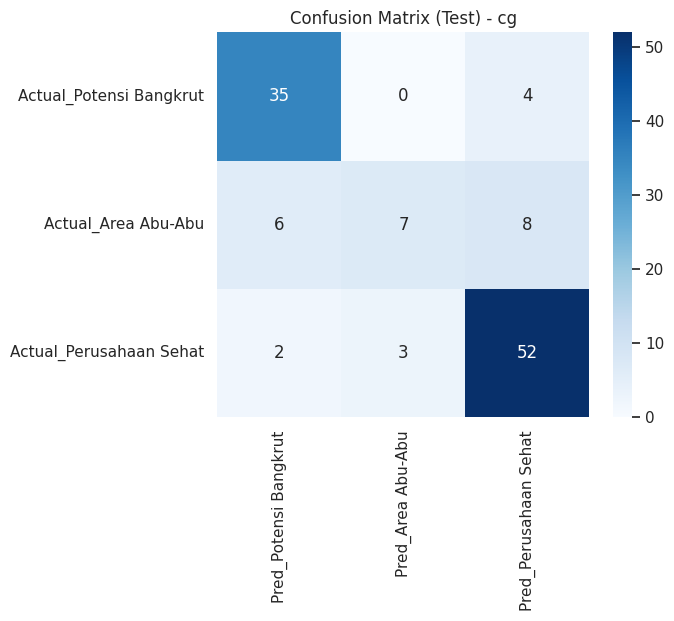

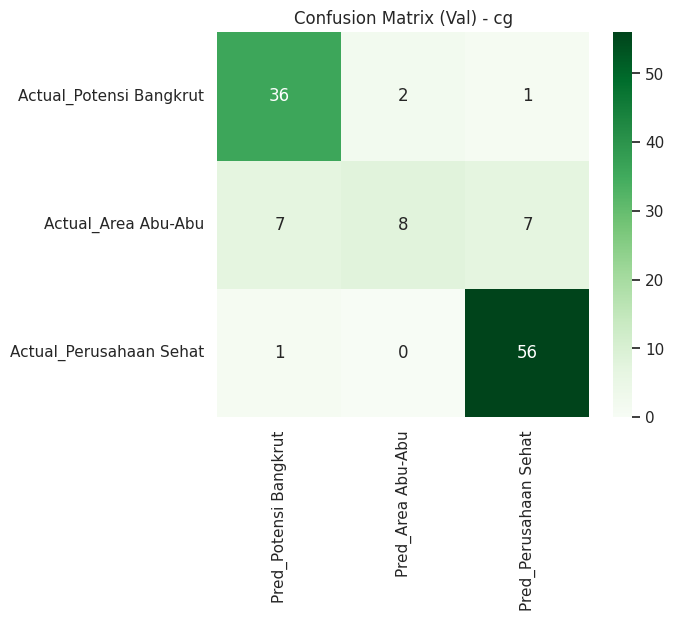


🚀 Melatih model MNLogit dengan metode: ncg


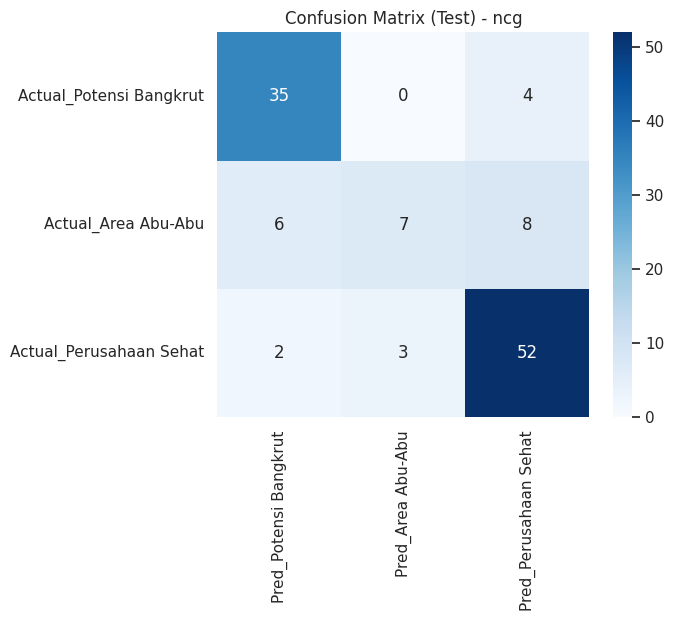

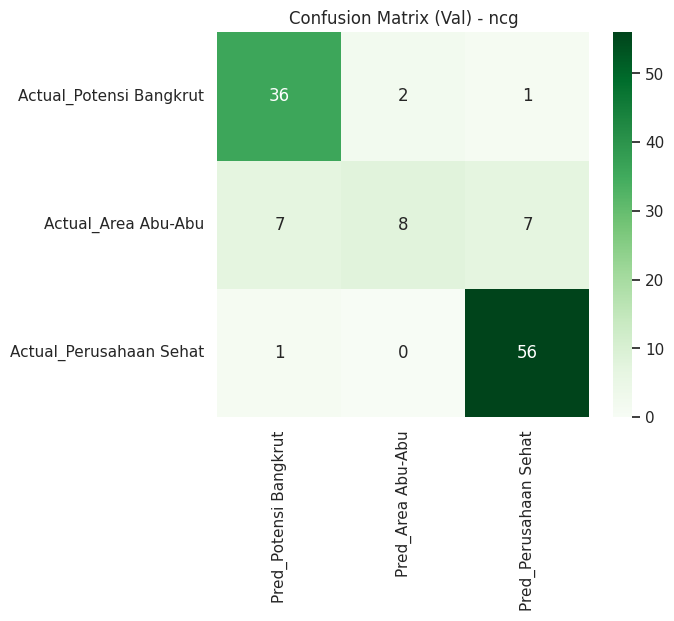


🚀 Melatih model MNLogit dengan metode: minimize


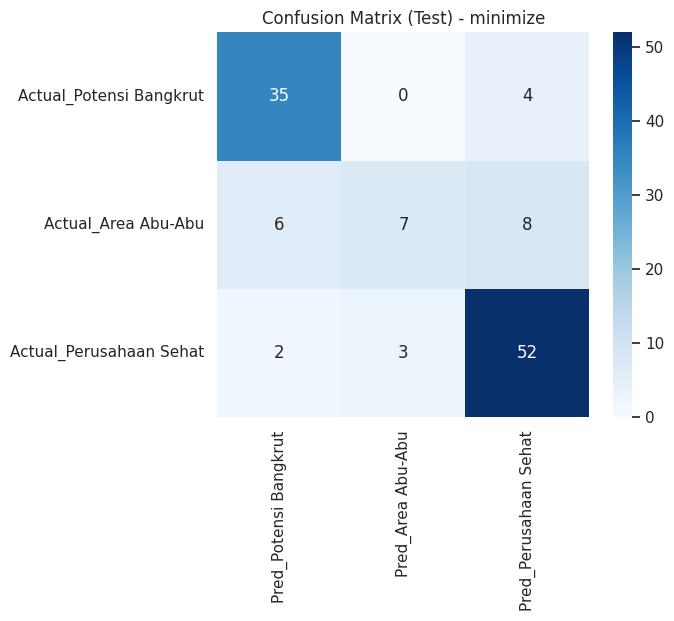

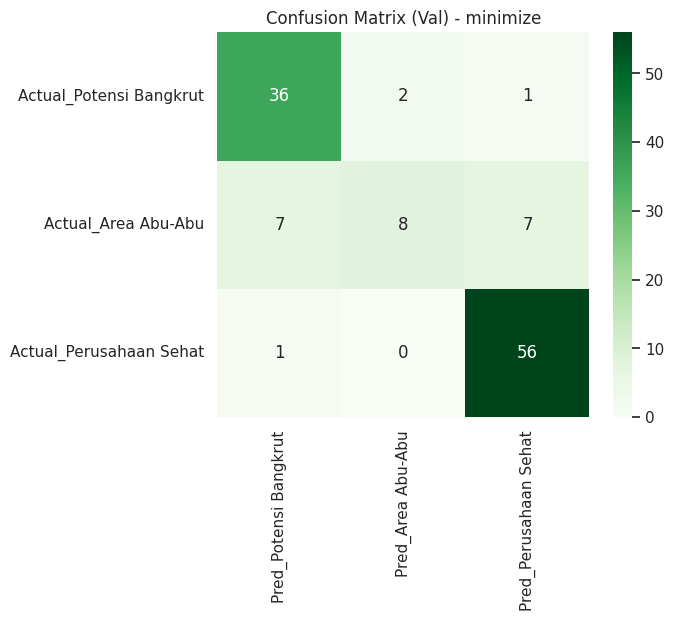



📋 Ringkasan Hasil Evaluasi Semua Metode:


,Method,Converged,Iterations,Pseudo_R2,AIC,BIC,LogLik,Acc_Test,Prec_Test,Recall_Test,F1_Test,Acc_Val,Prec_Val,Recall_Val,F1_Val
0,newton,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,nm,True,32584,0.269786,1472.355915,1636.970842,-702.177958,0.717949,0.598039,0.597648,0.571320,0.703390,0.596712,0.60236,0.582322
2,bfgs,True,N/A,0.464744,1097.411075,1262.026001,-514.705537,0.803419,0.775484,0.714350,0.721592,0.847458,0.831061,0.75639,0.764363
3,lbfgs,True,208,0.464744,1097.411101,1262.026027,-514.705550,0.803419,0.775484,0.714350,0.721592,0.847458,0.831061,0.75639,0.764363
4,powell,True,13,0.464177,1098.500563,1263.115489,-515.250281,0.811966,0.793644,0.730223,0.742486,0.822034,0.797980,0.71754,0.717981
5,cg,True,N/A,0.464744,1097.410653,1262.025579,-514.705326,0.803419,0.775484,0.714350,0.721592,0.847458,0.831061,0.75639,0.764363
6,ncg,True,N/A,0.464744,1097.410252,1262.025178,-514.705126,0.803419,0.775484,0.714350,0.721592,0.847458,0.831061,0.75639,0.764363
7,minimize,True,115,0.464744,1097.411075,1262.026001,-514.705537,0.803419,0.775484,0.714350,0.721592,0.847458,0.831061,0.75639,0.764363


In [49]:
evaluate_mnlogit(
    X_train=X_train_scaled_yeo, y_train=y_train_prep,
    X_test=X_test_scaled_yeo, y_test=y_test_prep,
    X_val=X_val_scaled_yeo, y_val=y_val_prep,
)

array([[<Axes: title={'center': 'Current_Ratio'}>,
        <Axes: title={'center': 'Cash_Ratio'}>,
        <Axes: title={'center': 'DAR'}>, <Axes: title={'center': 'DER'}>],
       [<Axes: title={'center': 'NPM'}>, <Axes: title={'center': 'ROA'}>,
        <Axes: title={'center': 'ROE'}>,
        <Axes: title={'center': 'Kepemilikan_Mayoritas'}>],
       [<Axes: title={'center': 'Komisaris_Independen'}>,
        <Axes: title={'center': 'Insider_Ownership'}>,
        <Axes: title={'center': 'BoC_Size'}>,
        <Axes: title={'center': 'BoC_Education'}>],
       [<Axes: title={'center': 'TMT_Size_DK'}>,
        <Axes: title={'center': 'TMT_Size_DD'}>,
        <Axes: title={'center': 'TMT_Education_DK'}>,
        <Axes: title={'center': 'TMT_Education_DD'}>],
       [<Axes: title={'center': 'Total_Asset'}>,
        <Axes: title={'center': 'Pertumbuhan_Revenue'}>, <Axes: >,
        <Axes: >]], dtype=object)

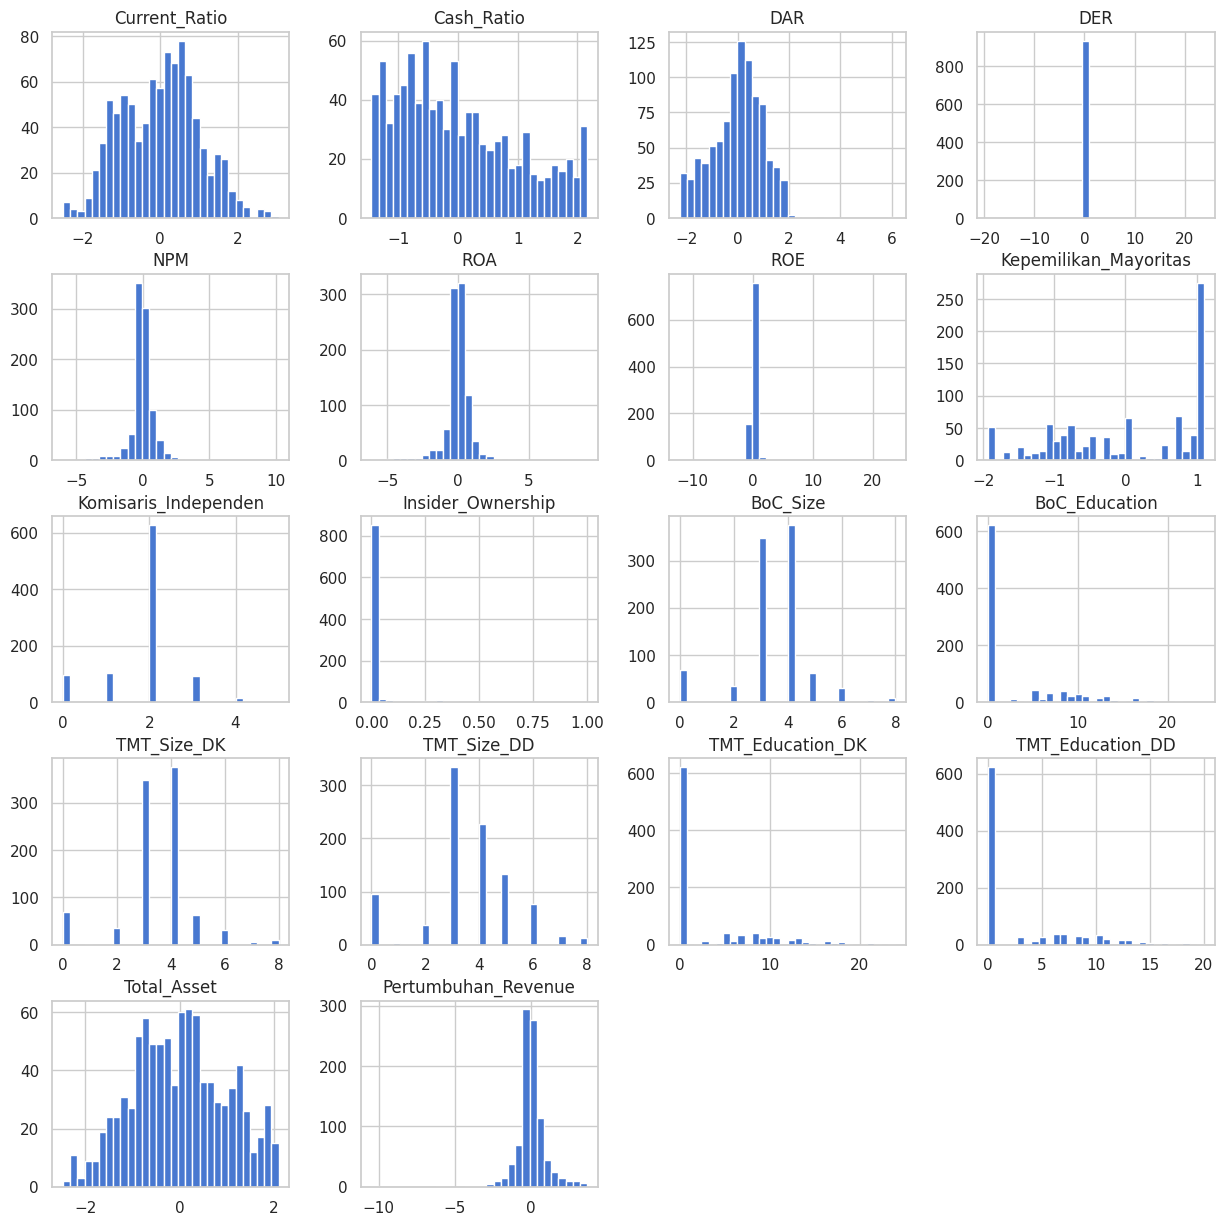

In [50]:
X_train_scaled_yeo.hist(figsize=(15, 15), bins=30)